In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib as mpl
import numpy as np
from scipy.interpolate import interp1d
import re
mpl.rcParams['svg.fonttype'] = 'none'
from scipy.optimize import root_scalar
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import glob
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import gaussian_kde
from math import sqrt, pi
import pickle
from collections import defaultdict
from itertools import product
import gurobipy as gp
from gurobipy import GRB
import itertools

## 데이터 불러오기

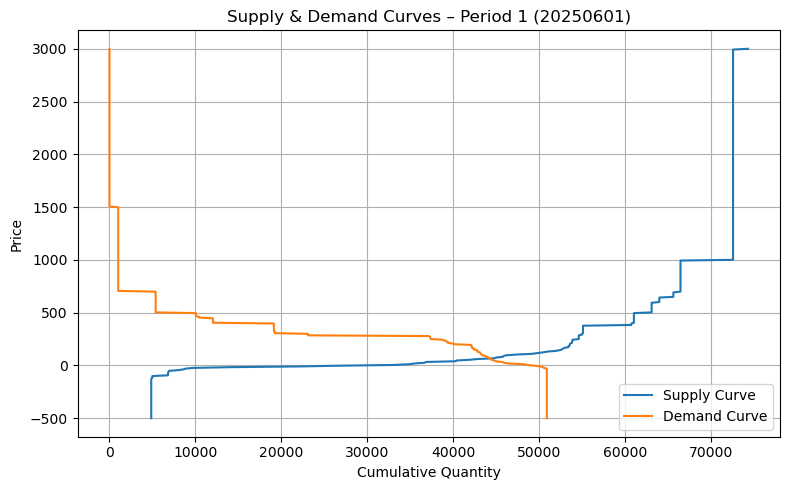

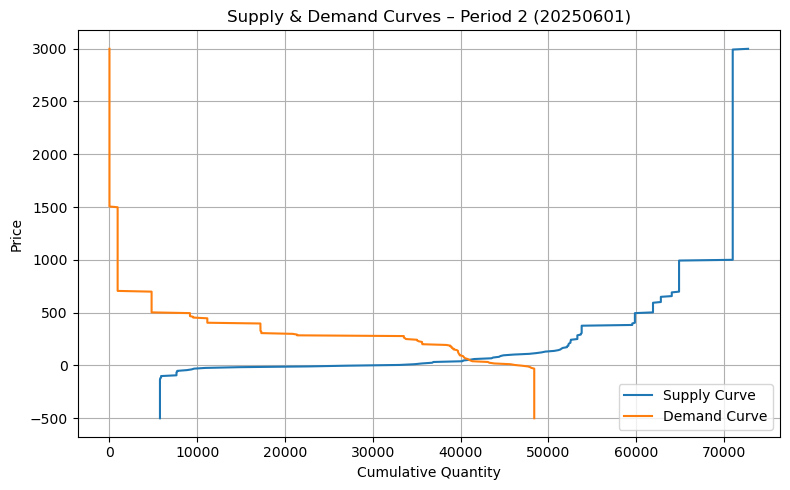

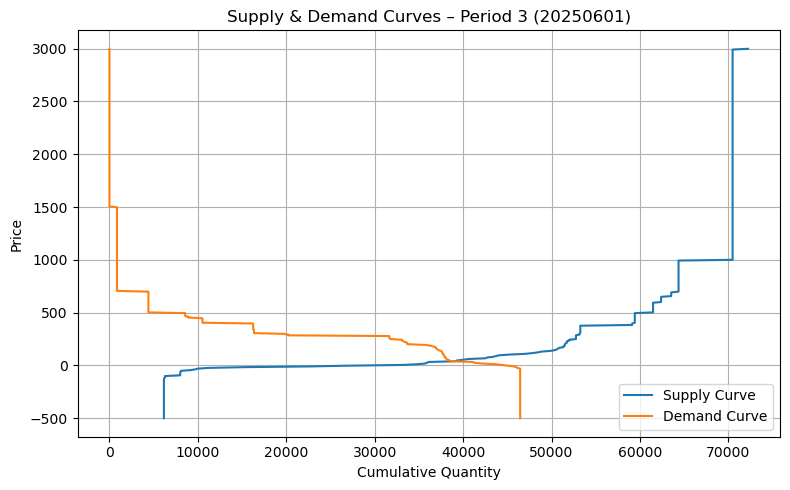

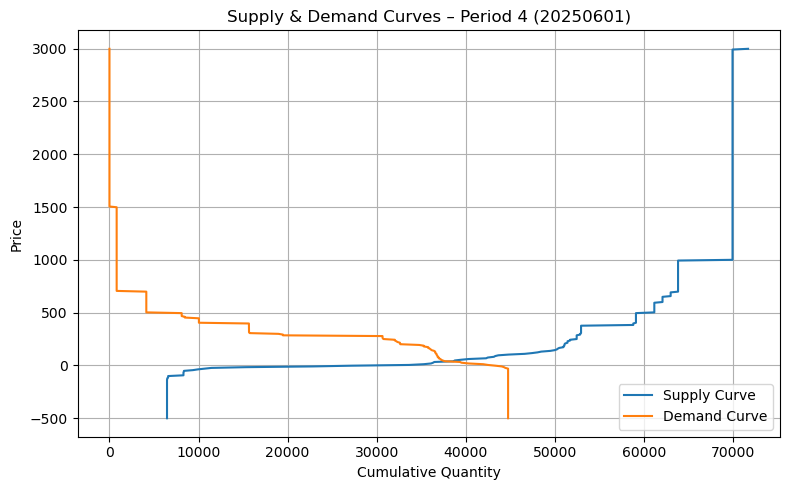

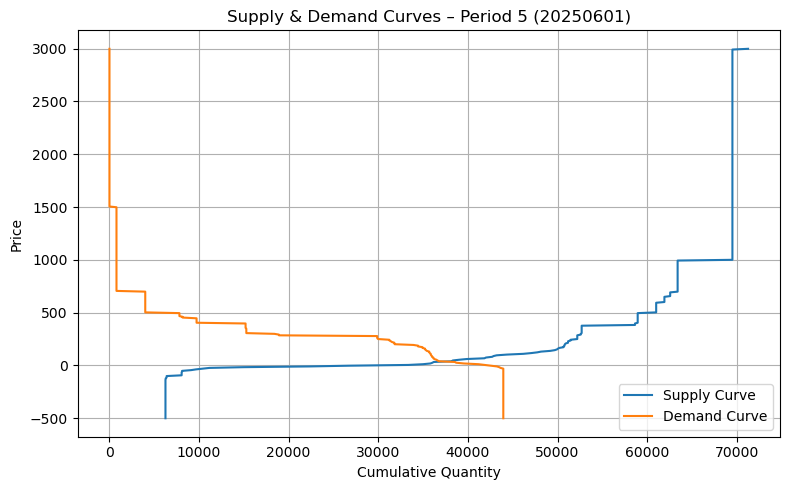

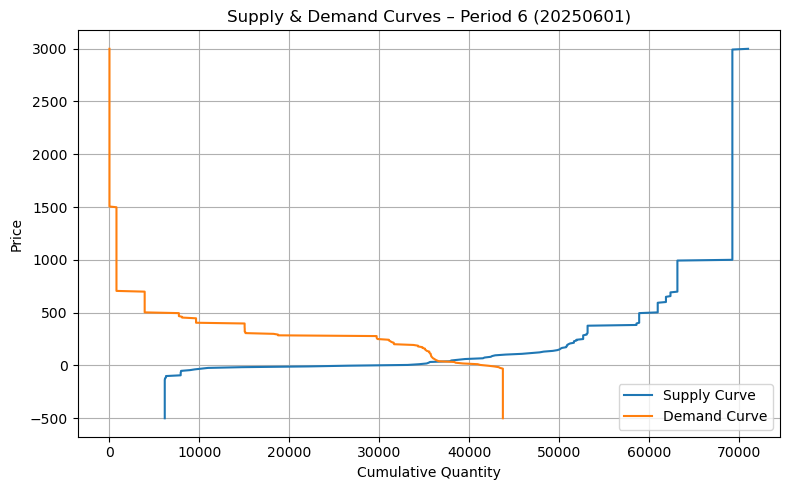

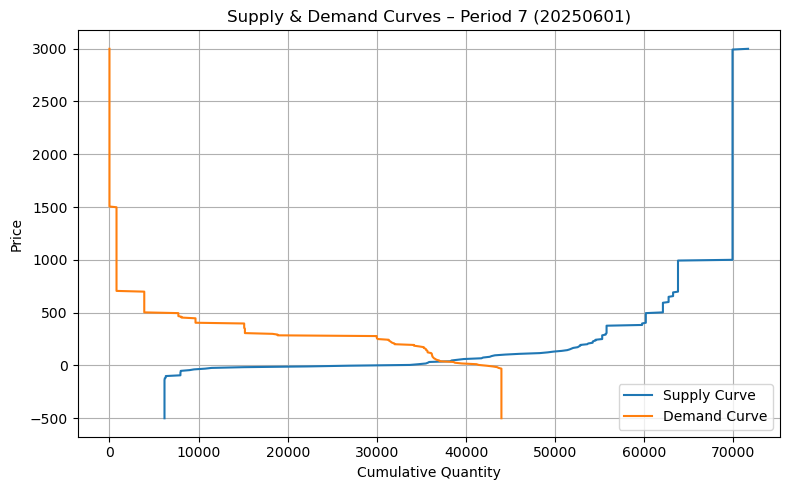

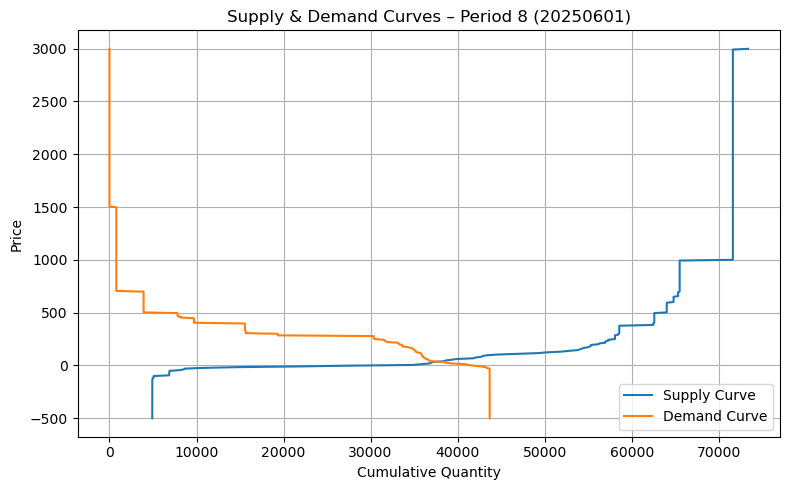

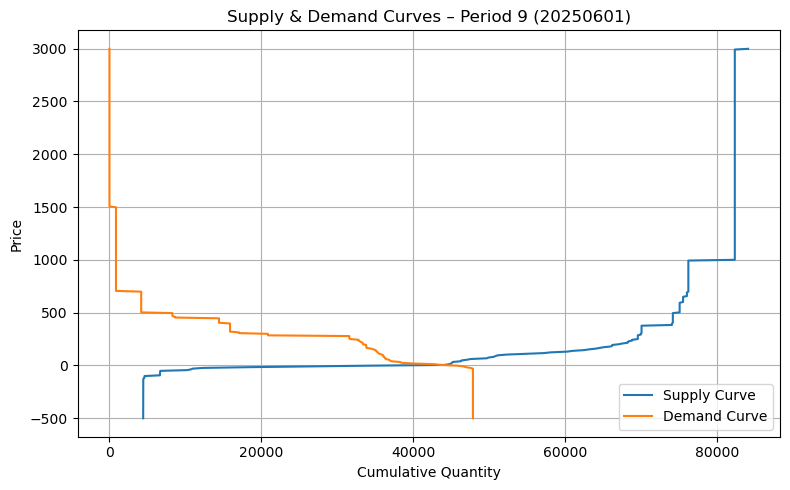

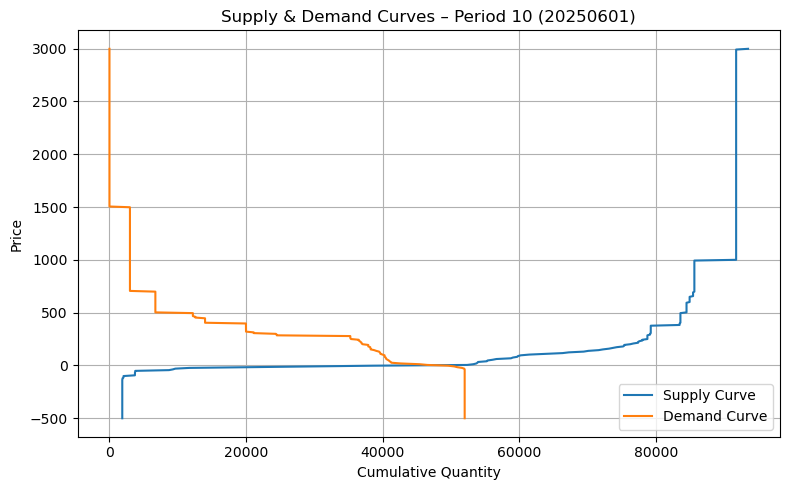

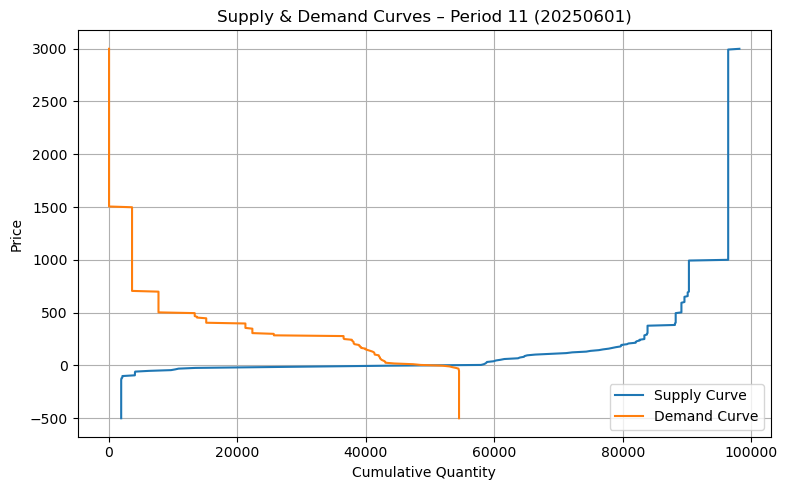

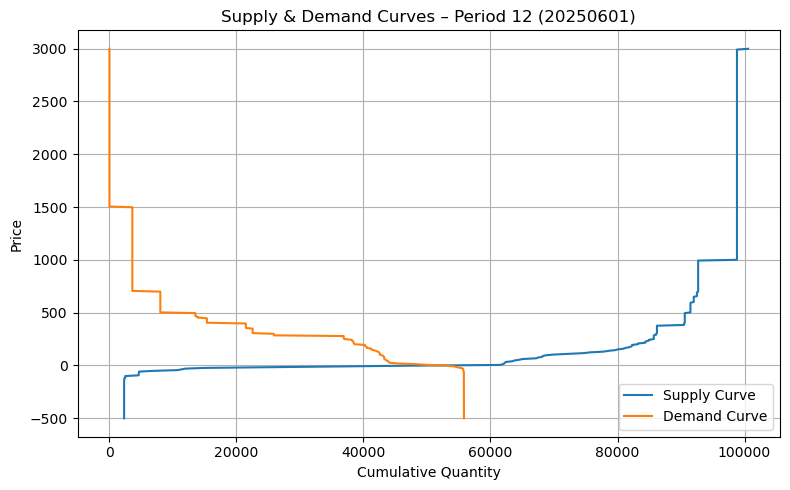

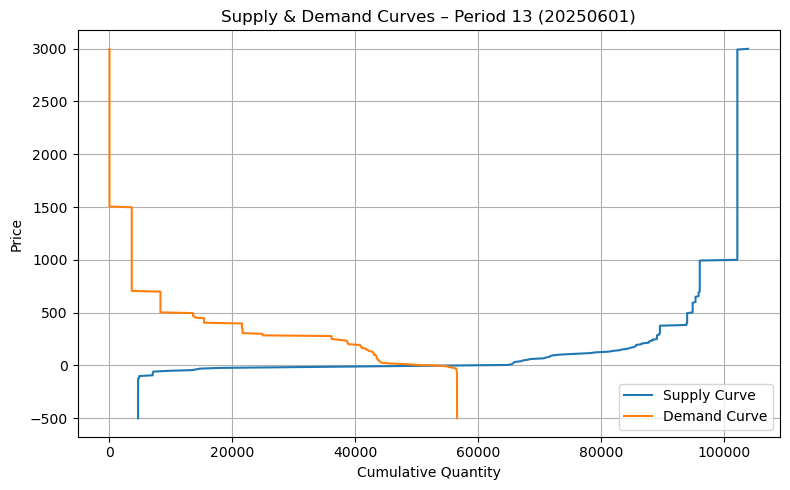

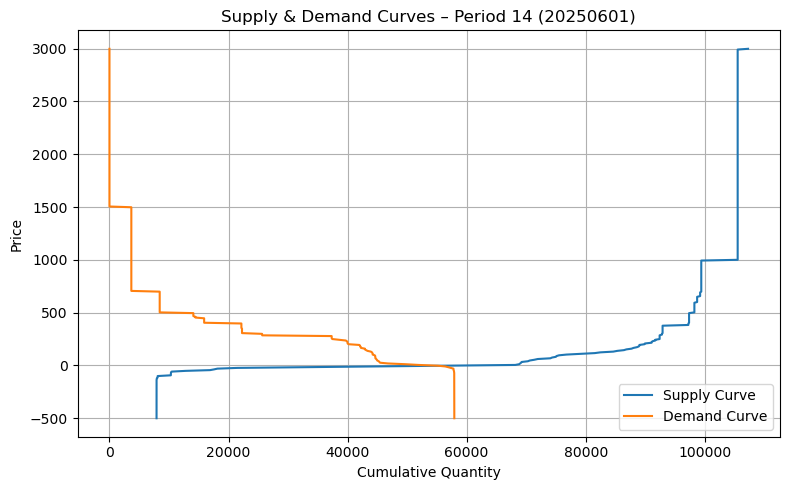

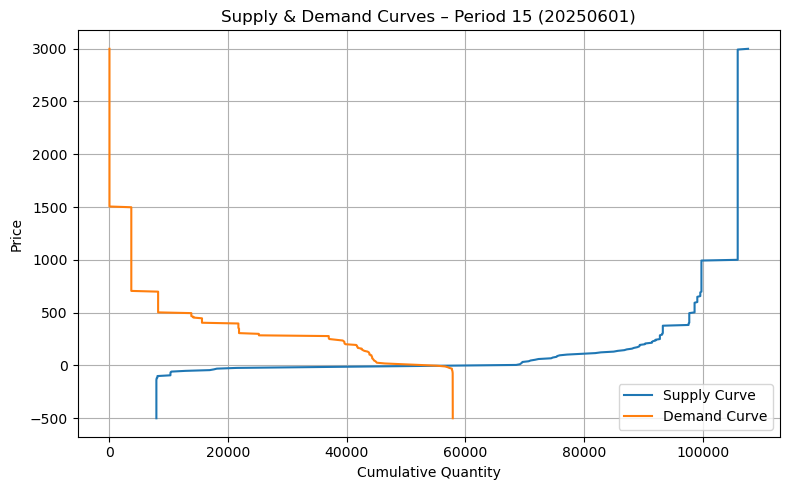

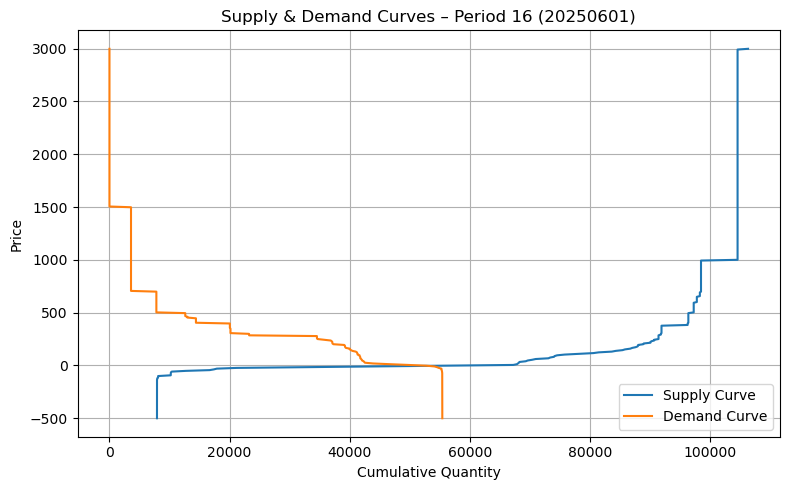

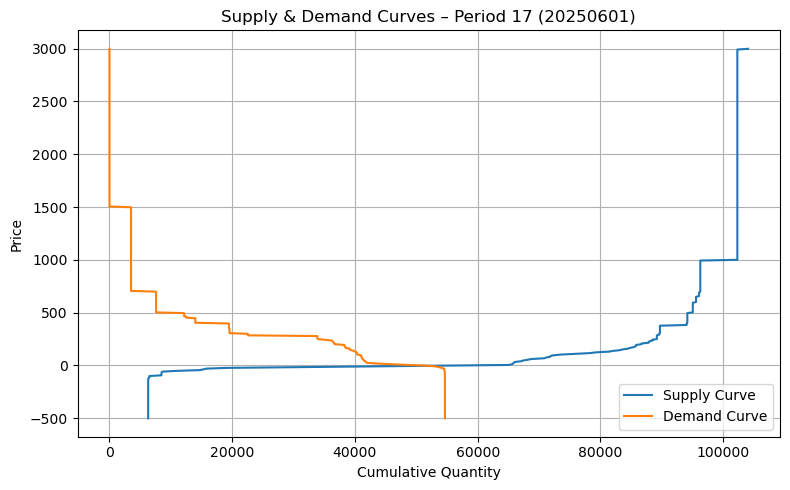

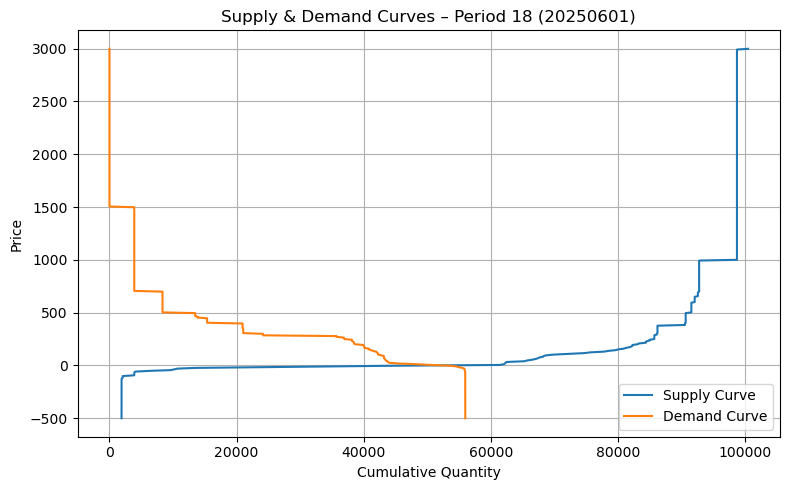

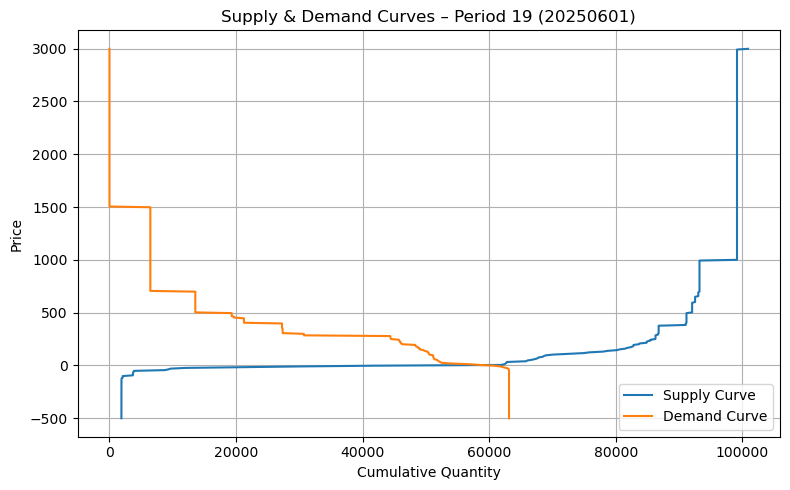

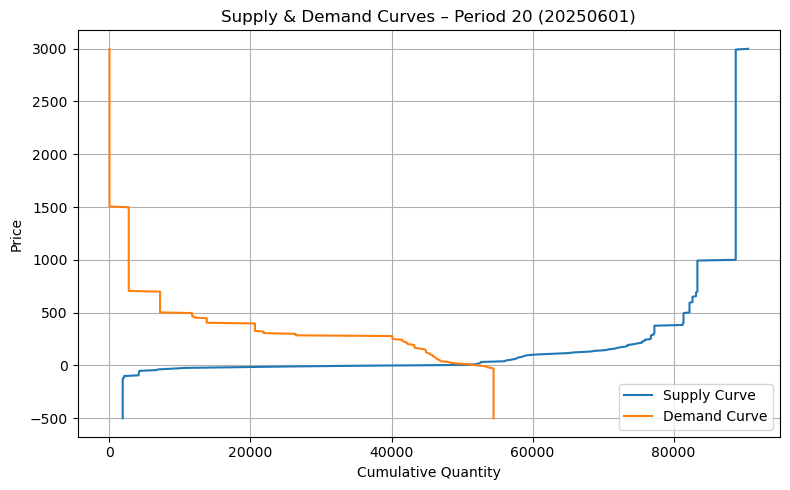

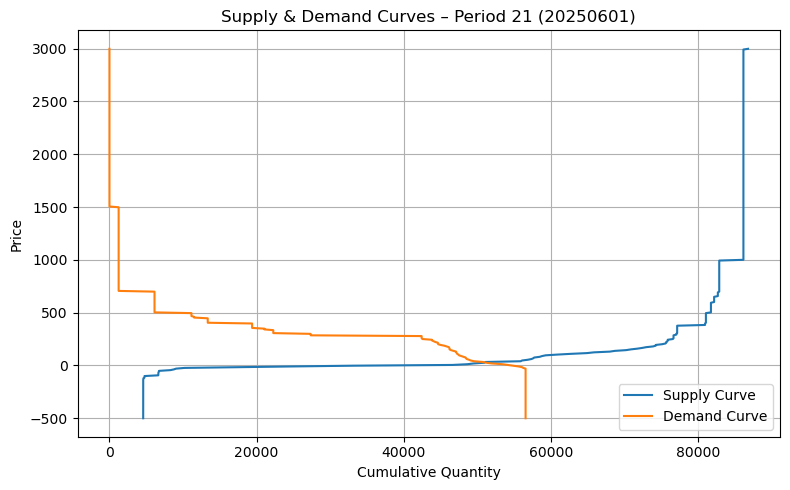

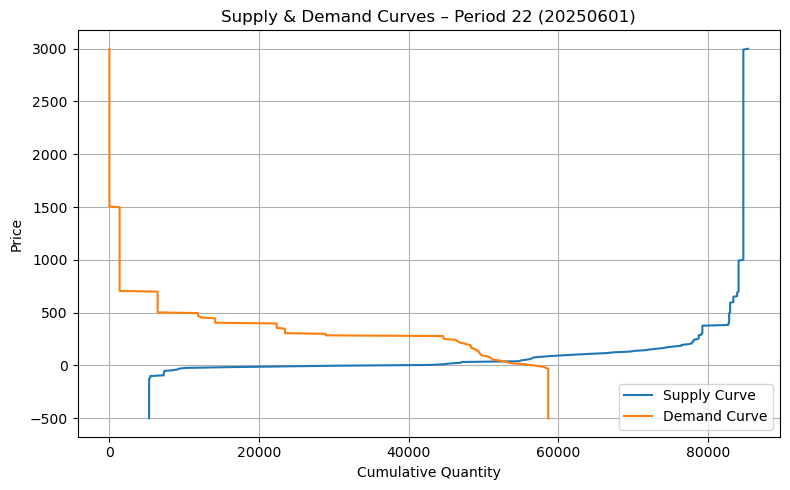

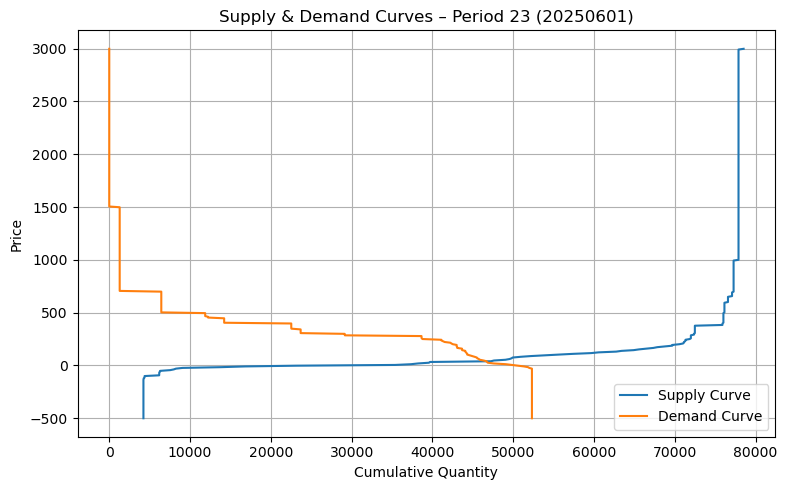

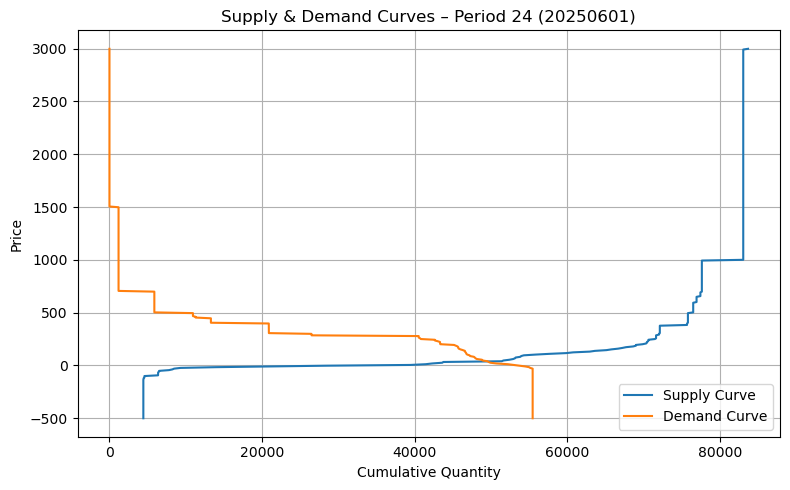

In [2]:
# --------------------------
# 대상 날짜 지정
# --------------------------
date_str = "20250601"
file_in = f"filteredcurve_{date_str}.csv"

# 파일 불러오기
try:
    df = pd.read_csv(file_in, sep=',', encoding='utf-8-sig')
except FileNotFoundError:
    print(f"파일 없음: {file_in}")
    raise

# --------------------------
# 24시간(Period 1~24) 반복
# --------------------------
for period in range(1, 25):  # 1~24
    mask = df['Time Period'] == period
    supply = df[mask & (df['GC'] == 'V')]
    demand = df[mask & (df['GC'] == 'C')]

    if supply.empty or demand.empty:
        print(f"{date_str} Period {period}: 데이터 없음, 건너뜀")
        continue

    # 공급 집계
    supply_agg = (
        supply.groupby('Price')['Amount']
              .sum()
              .reset_index()
              .sort_values('Price')
    )
    supply_agg['CumulQty'] = supply_agg['Amount'].cumsum()

    # 수요 집계
    demand_agg = (
        demand.groupby('Price')['Amount']
              .sum()
              .reset_index()
              .sort_values('Price')
    )
    demand_agg['CumulQty'] = demand_agg['Amount'][::-1].cumsum()[::-1]

    # 보간 함수
    supply_func = interp1d(
        supply_agg['Price'], supply_agg['CumulQty'],
        kind='previous', bounds_error=False,
        fill_value=(0, supply_agg['CumulQty'].iloc[-1])
    )
    demand_func = interp1d(
        demand_agg['Price'], demand_agg['CumulQty'],
        kind='previous', bounds_error=False,
        fill_value=(demand_agg['CumulQty'].iloc[0], 0)
    )

    # 가격 그리드
    pmin = min(supply_agg['Price'].min(), demand_agg['Price'].min())
    pmax = max(supply_agg['Price'].max(), demand_agg['Price'].max())
    price_grid = np.linspace(pmin, pmax, 500)
    supply_vals = supply_func(price_grid)
    demand_vals = demand_func(price_grid)

    # 플롯
    plt.figure(figsize=(8,5))
    plt.plot(supply_vals, price_grid, label='Supply Curve')
    plt.plot(demand_vals, price_grid, label='Demand Curve')
    plt.xlabel('Cumulative Quantity')
    plt.ylabel('Price')
    plt.title(f'Supply & Demand Curves – Period {period} ({date_str})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 시나리오 생성

### 수요공급선 생성

In [66]:
# --------------------------
# 원본 데이터 로드
# --------------------------
date_str = "20250601"
file_in = f"filteredcurve_{date_str}.csv"

df = pd.read_csv(file_in, sep=',', encoding='utf-8-sig')

# --------------------------
# 노이즈 추가 함수
# --------------------------
def add_noise(df, sigma=0.1, random_state=None):
    rng = np.random.default_rng(random_state)
    noisy_df = df.copy()
    # Amount에 노이즈 추가 (±σ 비율)
    noise = rng.normal(0, sigma, size=len(noisy_df))
    noisy_df['Amount'] = noisy_df['Amount'] * (1 + noise)
    noisy_df['Amount'] = noisy_df['Amount'].clip(lower=0)  # 음수 방지
    return noisy_df

# --------------------------
# 시나리오 10개 생성
# --------------------------
n_scenarios = 10
scenario_dfs = []

outdir = "scenarios_20250601_2"
os.makedirs(outdir, exist_ok=True)

for s in range(1, n_scenarios + 1):
    noisy_df = add_noise(df, sigma=0.05, random_state=s)
    scenario_dfs.append(noisy_df)
    
    # 파일로 저장 (원하면)
    outpath = os.path.join(outdir, f"{date_str}_scenario{s:02d}.csv")
    noisy_df.to_csv(outpath, sep=',', encoding='utf-8-sig', index=False)
    print(f"Saved: {outpath}")

print("scenarion generation complete!")

Saved: scenarios_20250601_2\20250601_scenario01.csv
Saved: scenarios_20250601_2\20250601_scenario02.csv
Saved: scenarios_20250601_2\20250601_scenario03.csv
Saved: scenarios_20250601_2\20250601_scenario04.csv
Saved: scenarios_20250601_2\20250601_scenario05.csv
Saved: scenarios_20250601_2\20250601_scenario06.csv
Saved: scenarios_20250601_2\20250601_scenario07.csv
Saved: scenarios_20250601_2\20250601_scenario08.csv
Saved: scenarios_20250601_2\20250601_scenario09.csv
Saved: scenarios_20250601_2\20250601_scenario10.csv
scenarion generation complete!


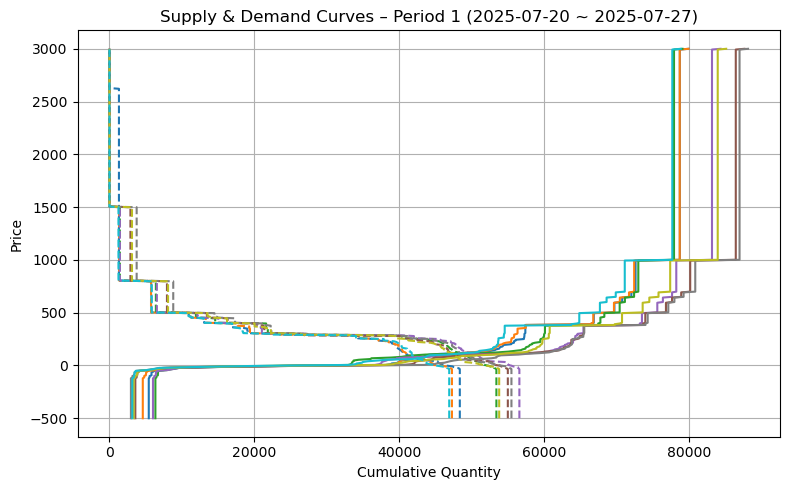

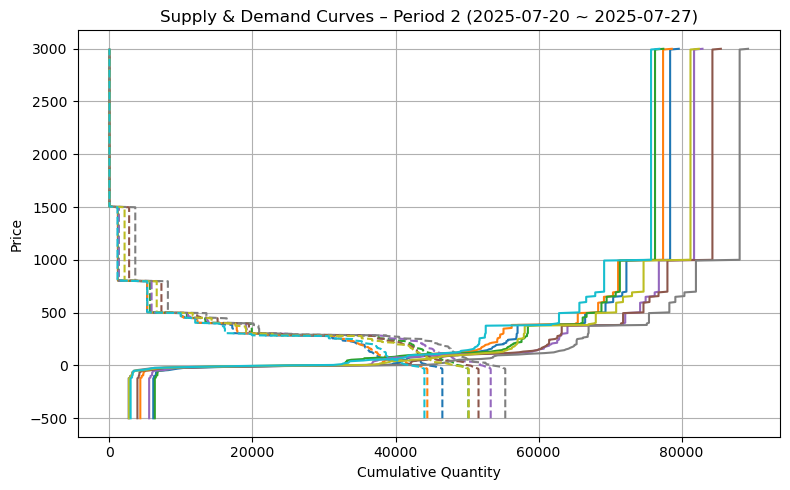

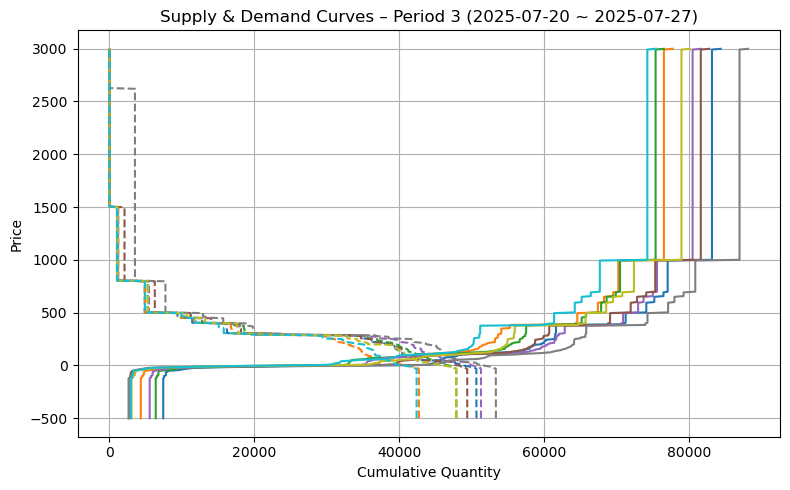

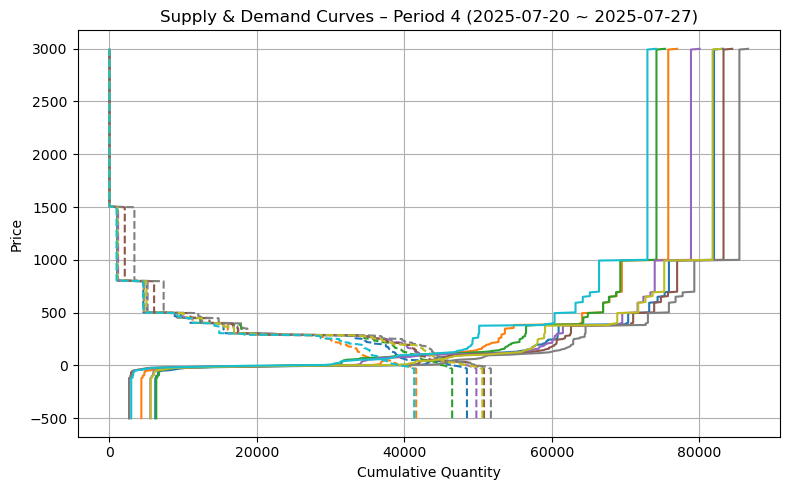

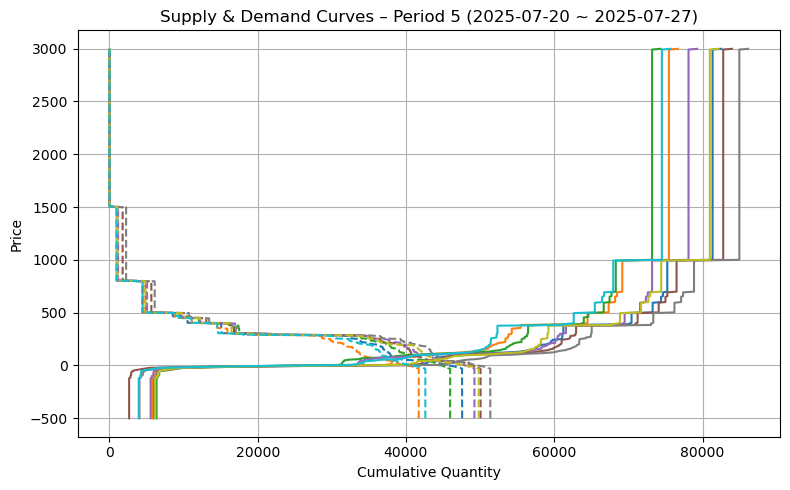

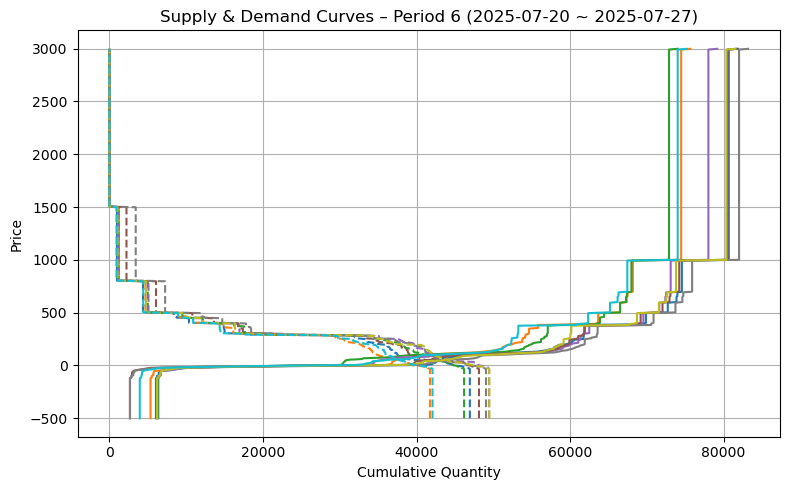

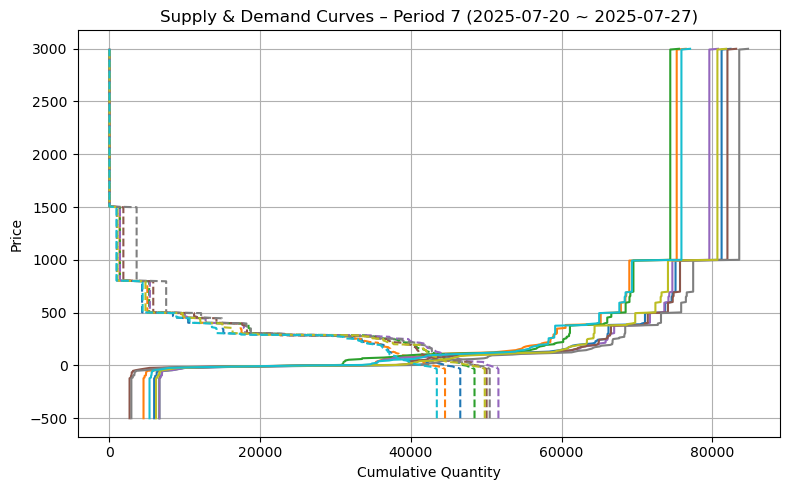

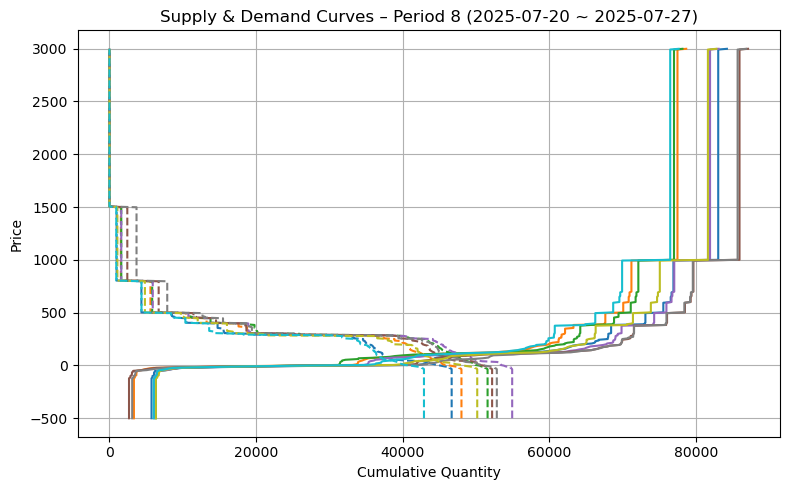

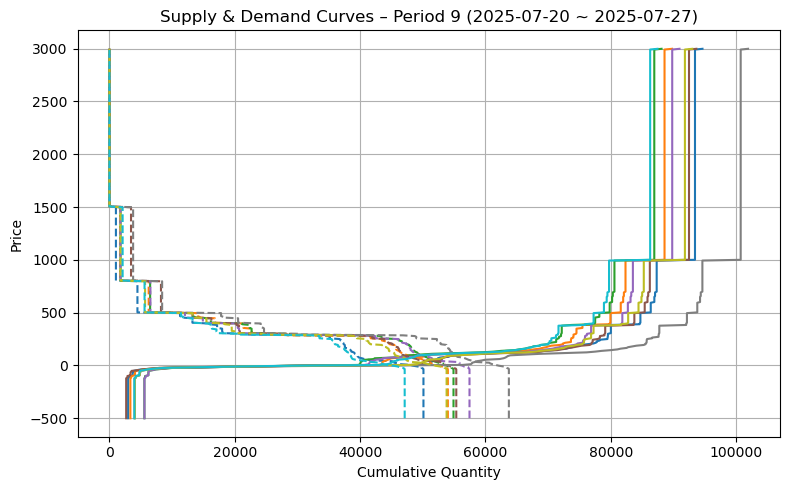

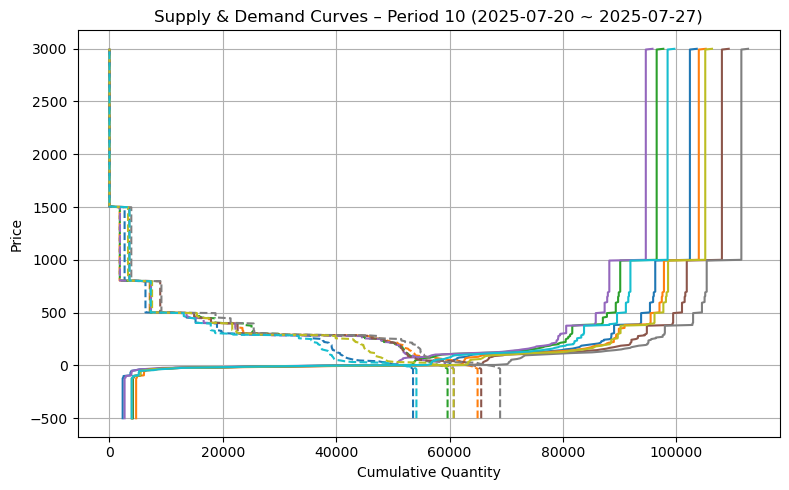

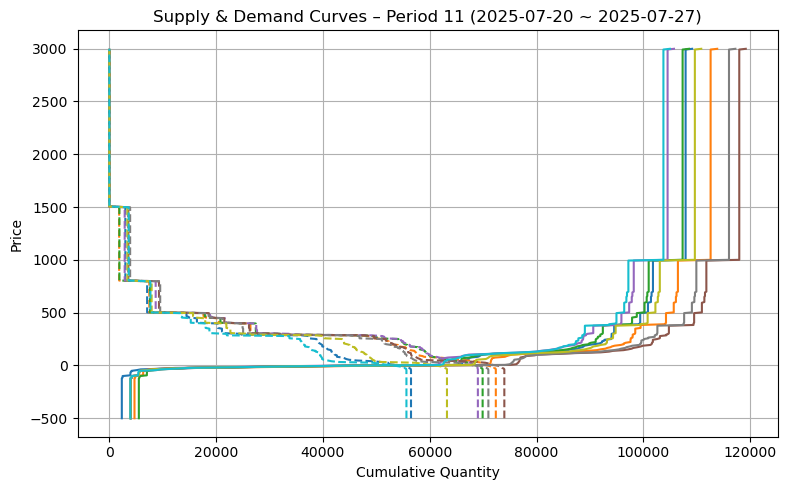

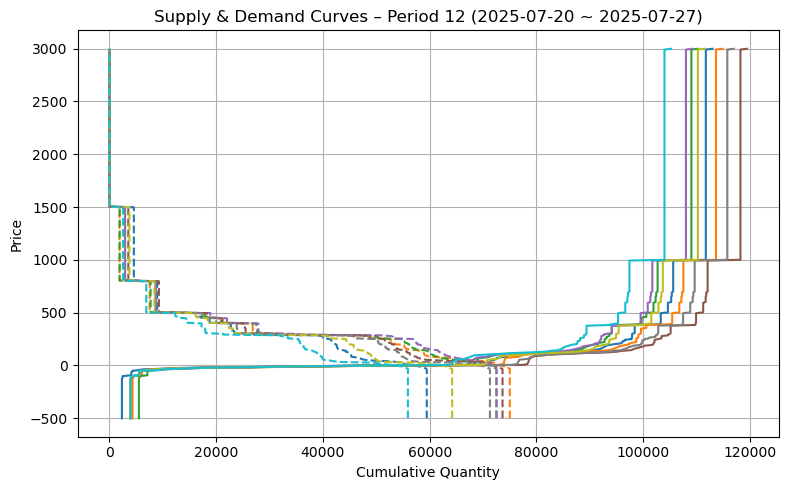

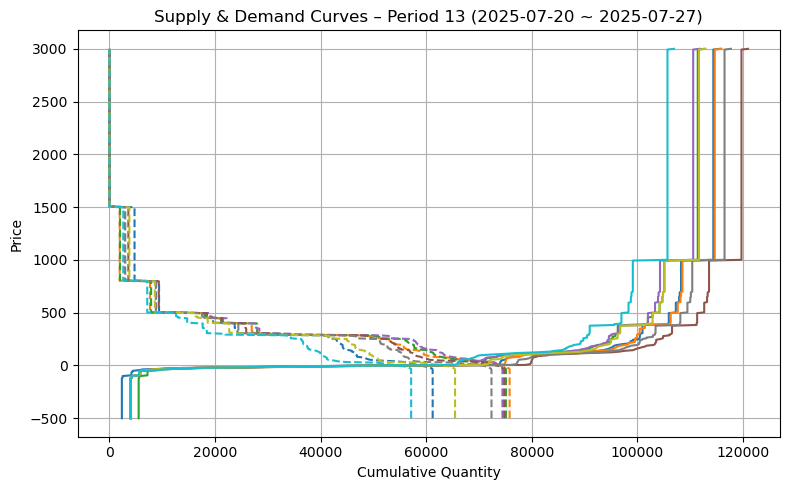

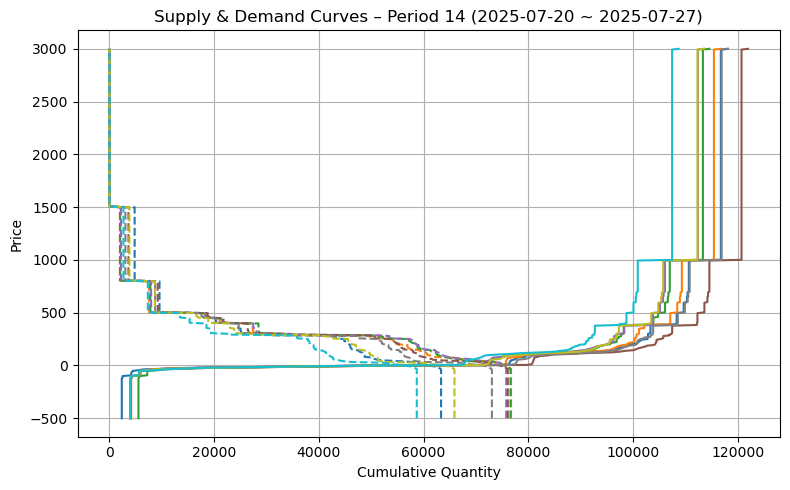

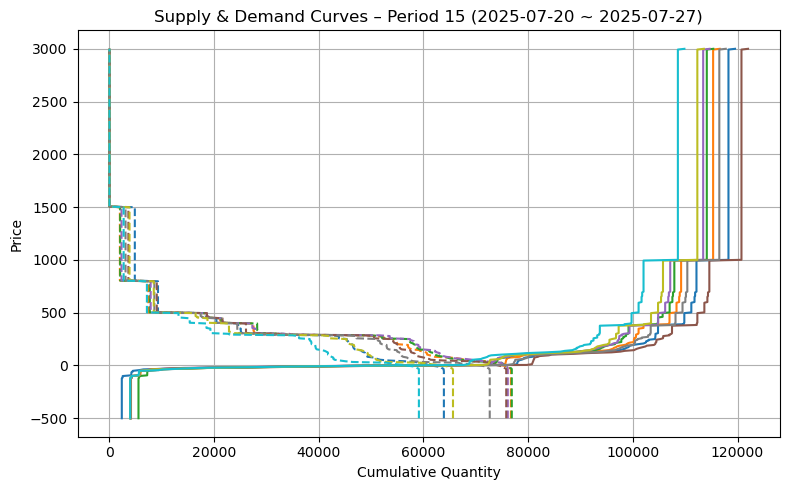

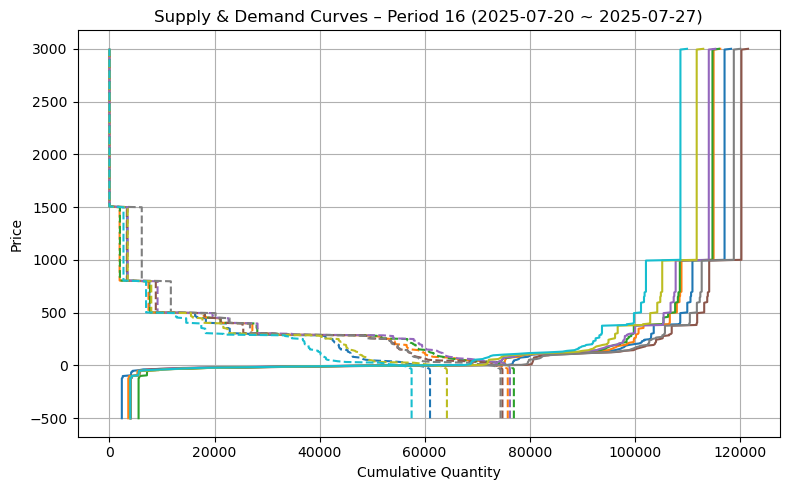

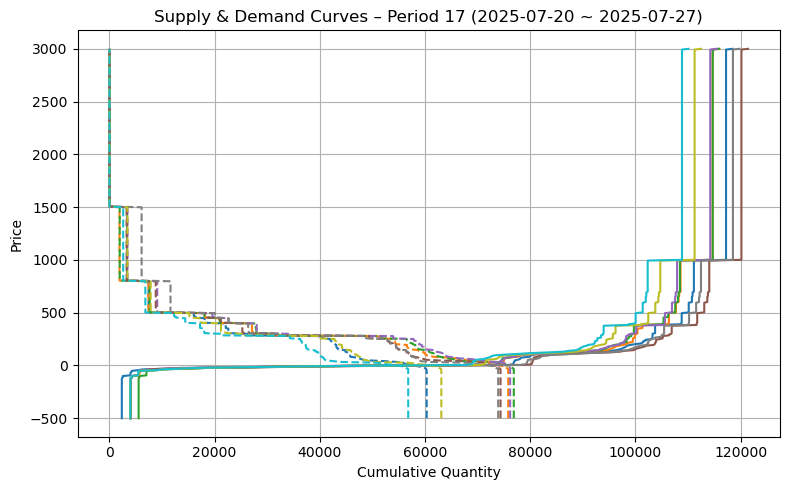

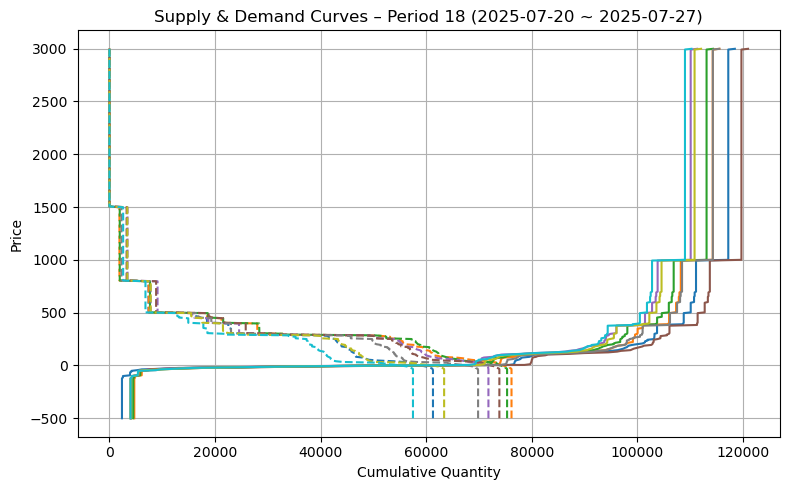

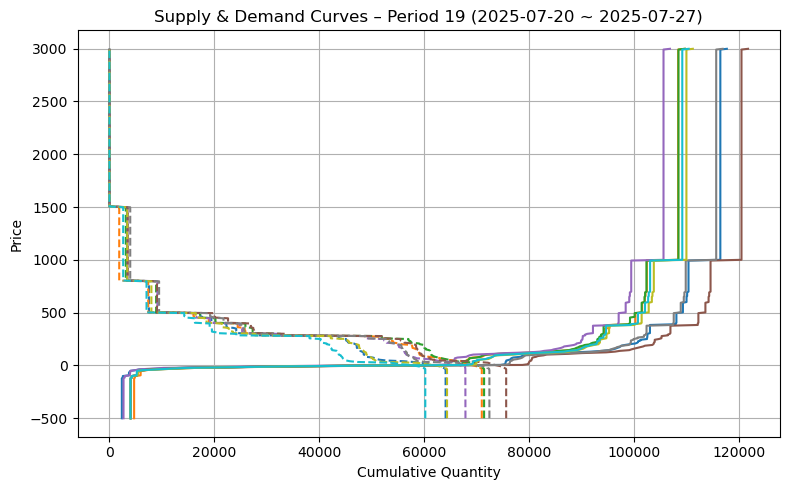

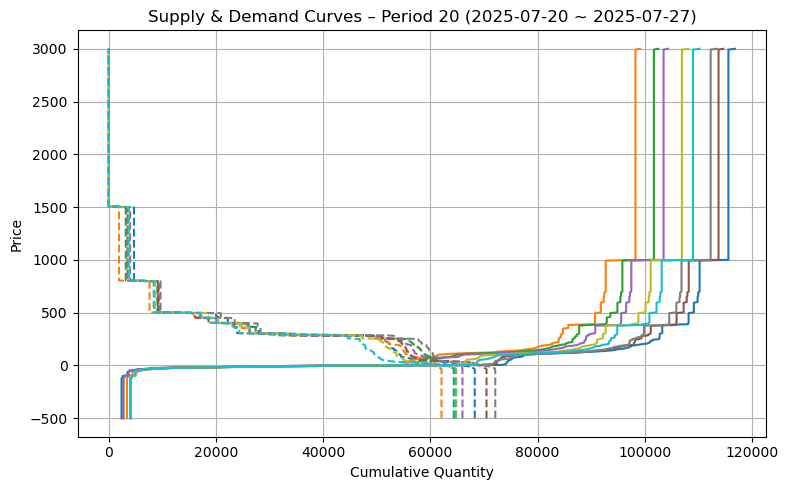

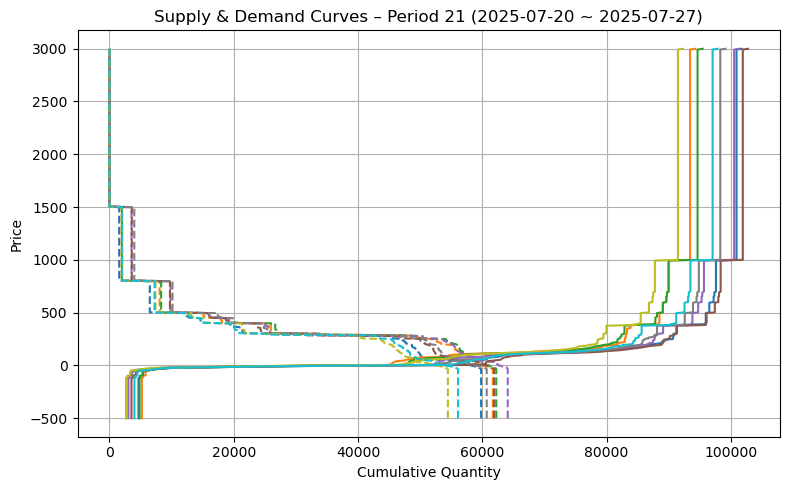

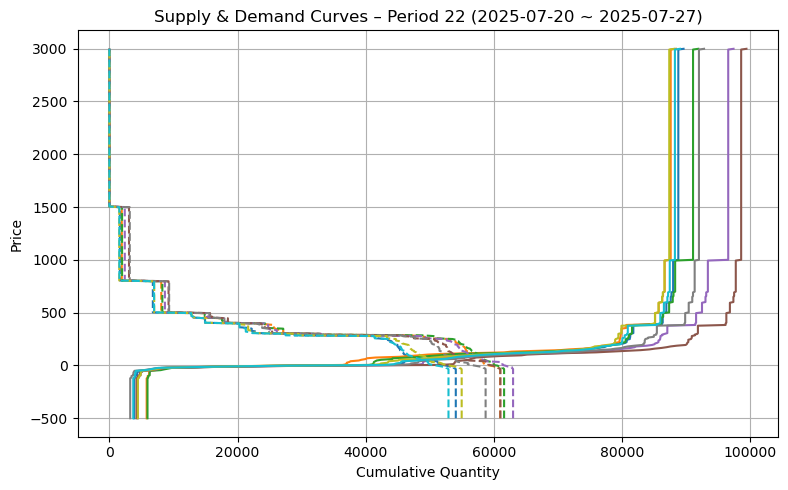

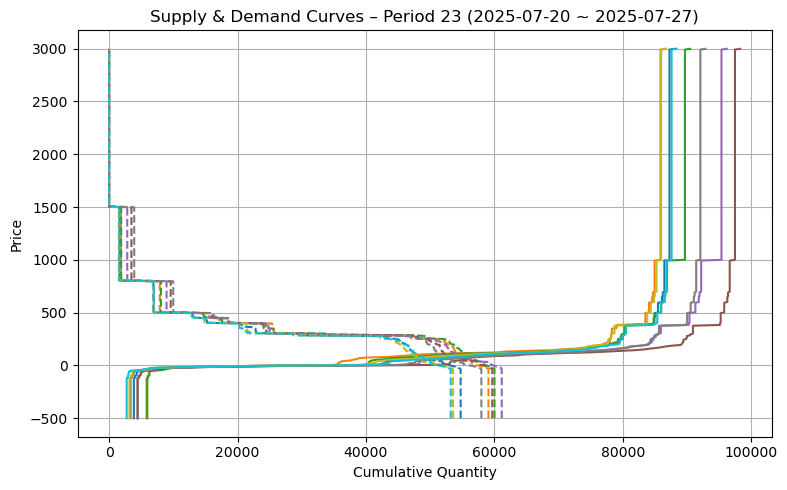

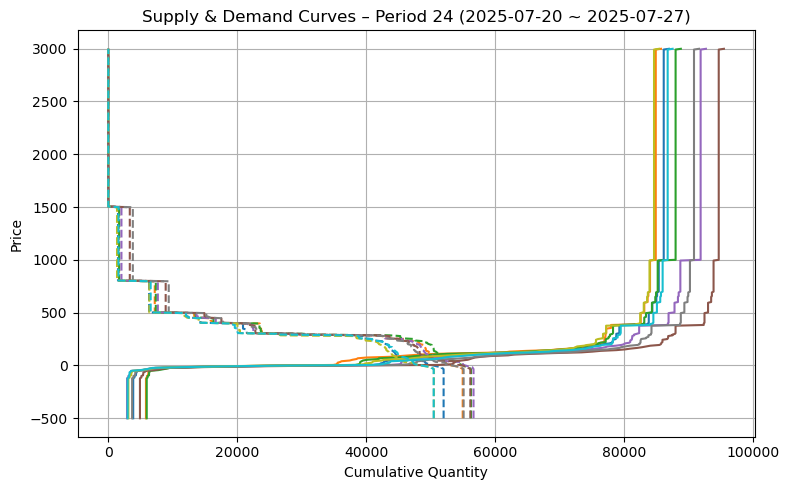

In [149]:

def load_curves_from_path(file_path, period):
    """시나리오 파일 경로 + 시간(period)로 공급/수요 곡선 반환"""
    df = pd.read_csv(file_path, sep=',', encoding='utf-8-sig')

    mask   = df['Time Period'] == period
    supply = df[mask & (df['GC'] == 'V')]
    demand = df[mask & (df['GC'] == 'C')]
    if supply.empty or demand.empty:
        return None

    # 공급 곡선 집계
    s_agg = (supply.groupby('Price')['Amount'].sum()
                   .reset_index().sort_values('Price'))
    s_agg['CumulQty'] = s_agg['Amount'].cumsum()

    # 수요 곡선 집계
    d_agg = (demand.groupby('Price')['Amount'].sum()
                   .reset_index().sort_values('Price'))
    d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

    # Price grid 기준 보간
    pmin = min(s_agg['Price'].min(), d_agg['Price'].min())
    pmax = max(s_agg['Price'].max(), d_agg['Price'].max())
    price_grid  = np.linspace(pmin, pmax, 500)

    s_func = interp1d(s_agg['Price'], s_agg['CumulQty'],
                      kind='previous', bounds_error=False,
                      fill_value=(0, s_agg['CumulQty'].iloc[-1]))
    d_func = interp1d(d_agg['Price'], d_agg['CumulQty'],
                      kind='previous', bounds_error=False,
                      fill_value=(d_agg['CumulQty'].iloc[0], 0))

    supply_vals = s_func(price_grid)
    demand_vals = d_func(price_grid)
    return price_grid, supply_vals, demand_vals

# --------------------------
# 날짜별 파일 목록 (7/20 ~ 7/27)
# --------------------------
days = range(20, 28)   # 2025-07-20 ~ 2025-07-27
colors = plt.cm.tab10(np.linspace(0,1,len(days)))  # 날짜별 색상 매핑

# --------------------------
# 각 Period(1~24) 마다 플롯
# --------------------------
for period in range(1,25):
    plt.figure(figsize=(8,5))
    any_plotted = False

    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        fn       = f"filteredcurve_{date_str}.csv"

        out = load_curves_from_path(fn, period)
        if out is None:
            continue
        price_grid, supply_vals, demand_vals = out

        plt.plot(supply_vals, price_grid, color=color, lw=1.5, label=f"{date_str} Supply")
        plt.plot(demand_vals, price_grid, color=color, lw=1.5, linestyle="--", label=f"{date_str} Demand")
        any_plotted = True

    if not any_plotted:
        print(f"{period}시: 데이터 없음")
        plt.close()
        continue

    plt.xlabel("Cumulative Quantity")
    plt.ylabel("Price")
    plt.title(f"Supply & Demand Curves – Period {period} (2025-07-20 ~ 2025-07-27)")
    plt.grid(True)
    # plt.legend(fontsize=8, loc="best", ncol=2)
    plt.tight_layout()
    plt.show()


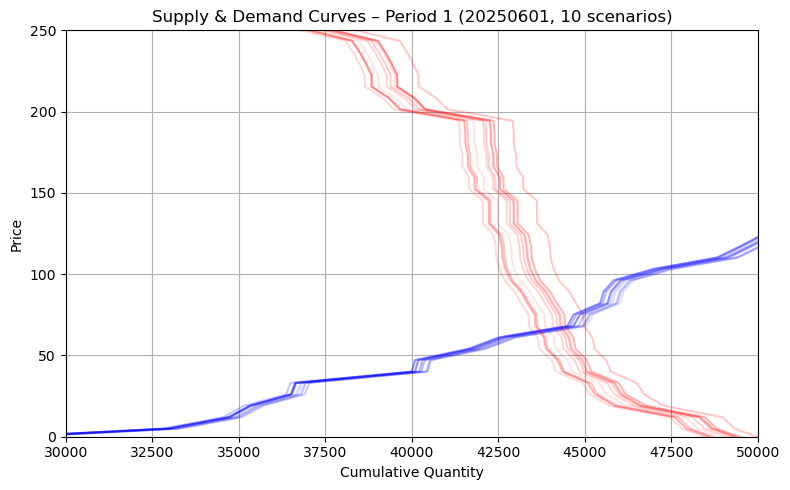

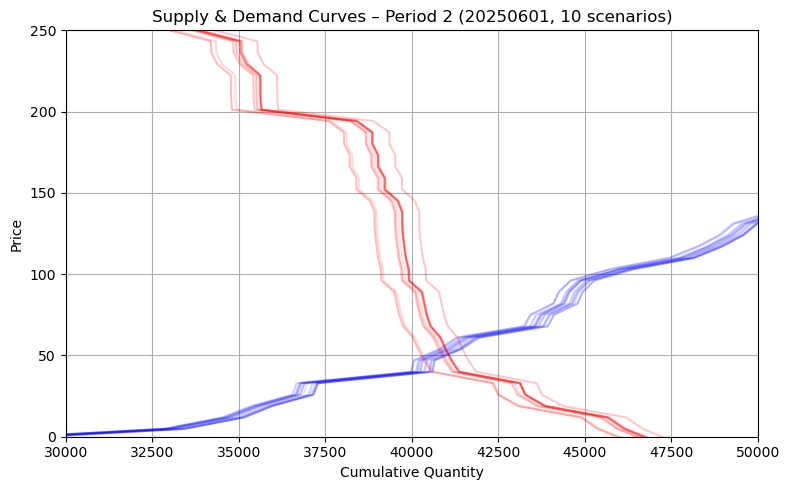

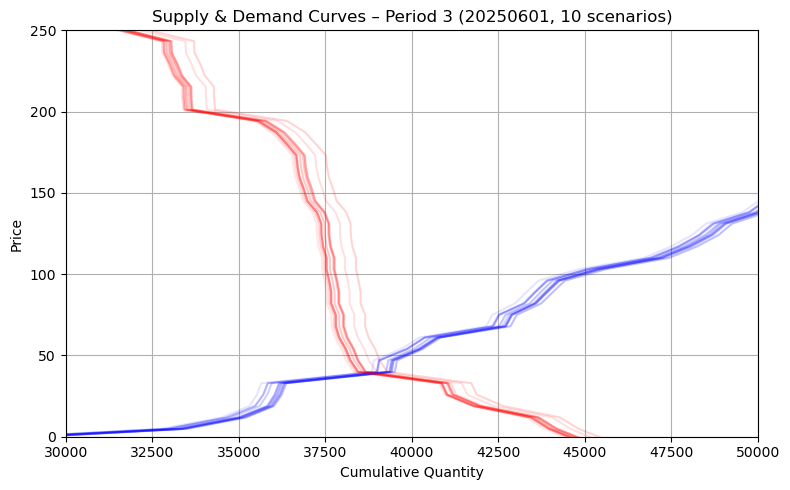

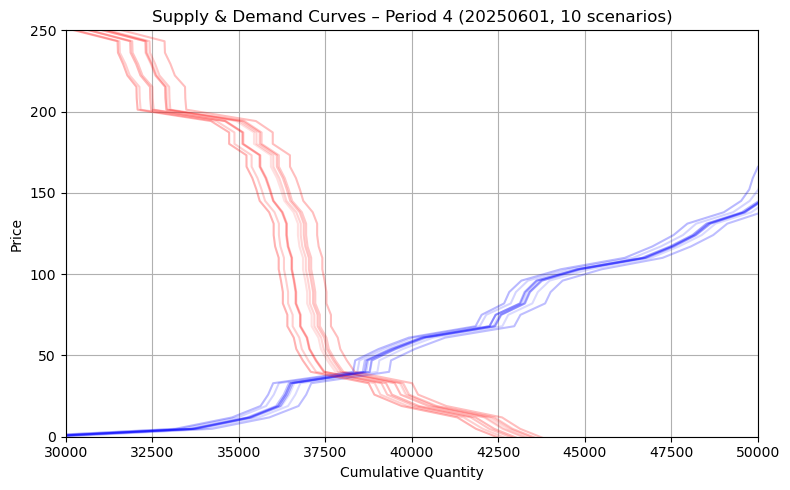

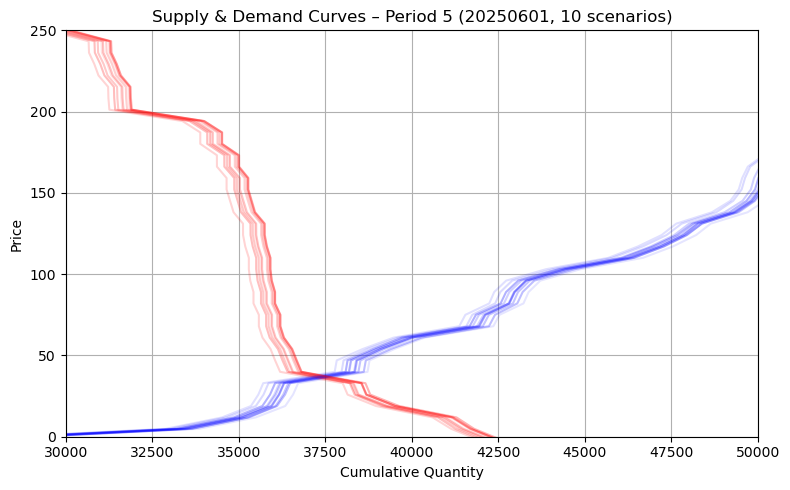

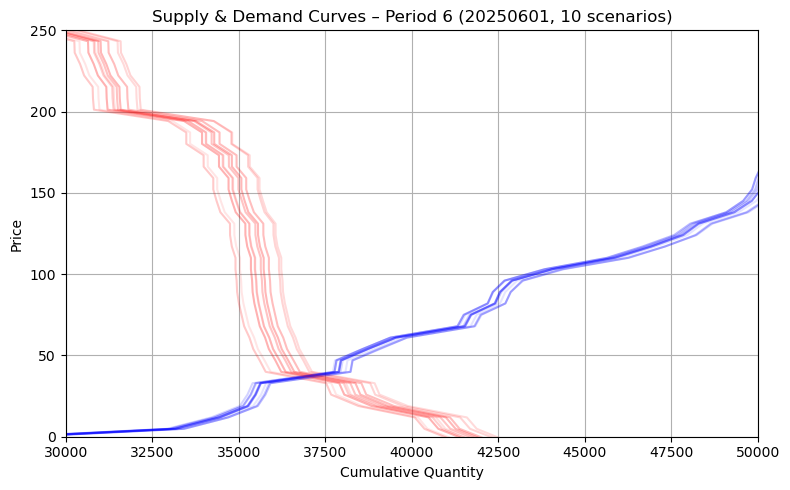

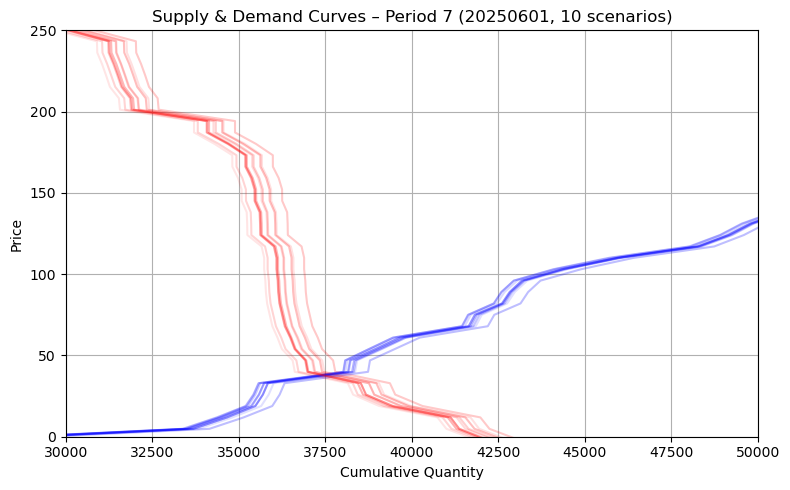

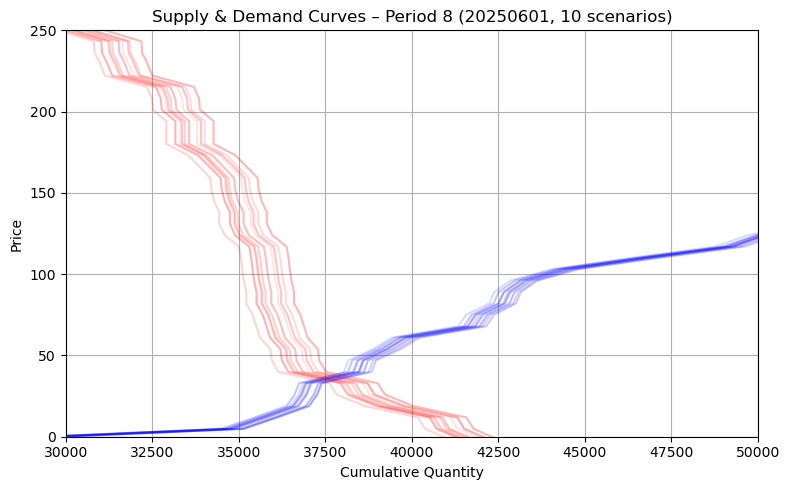

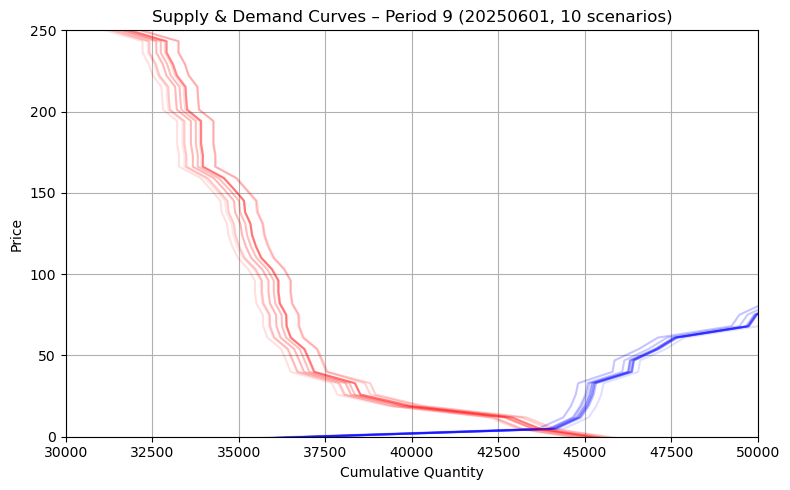

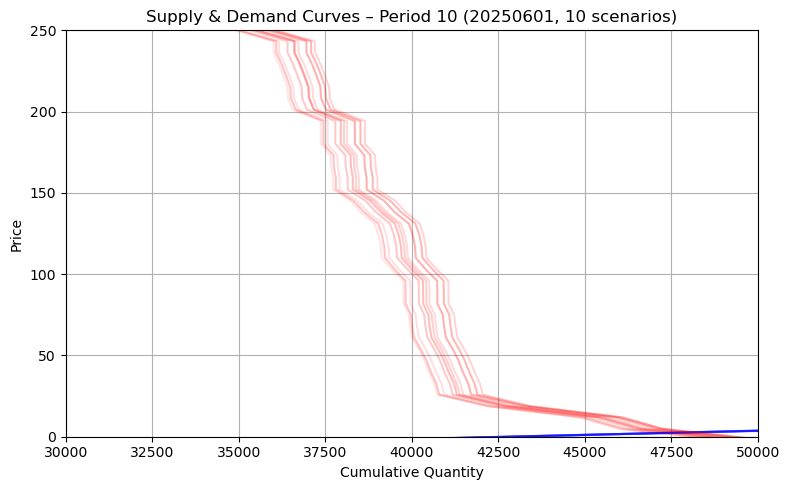

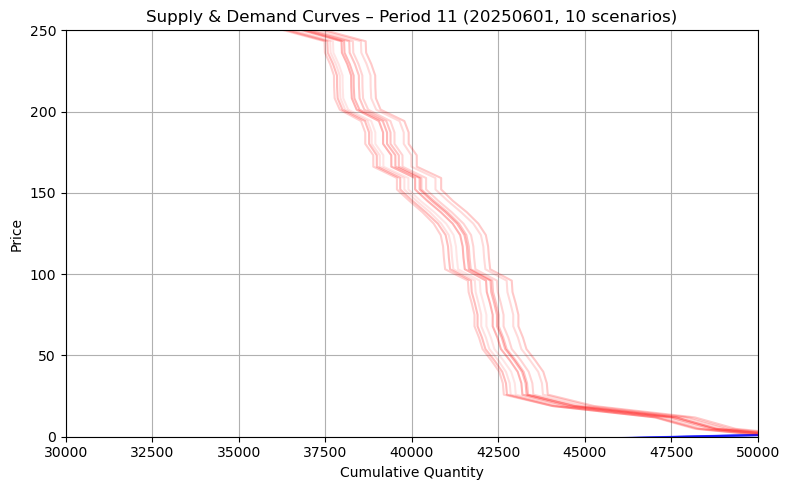

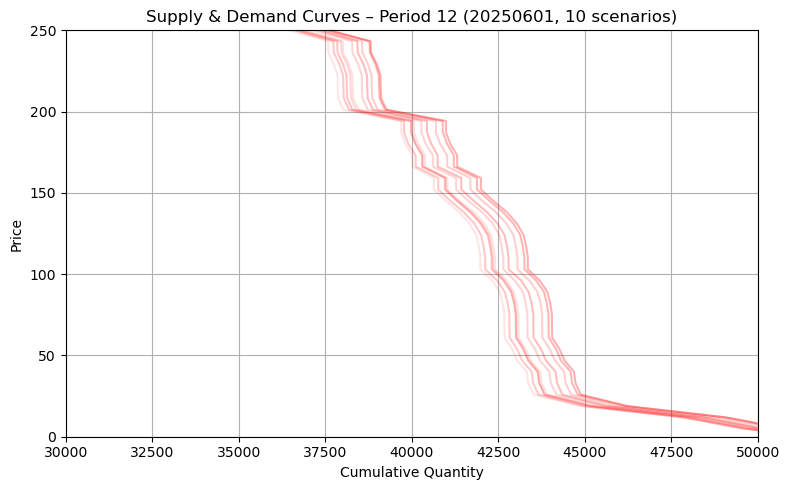

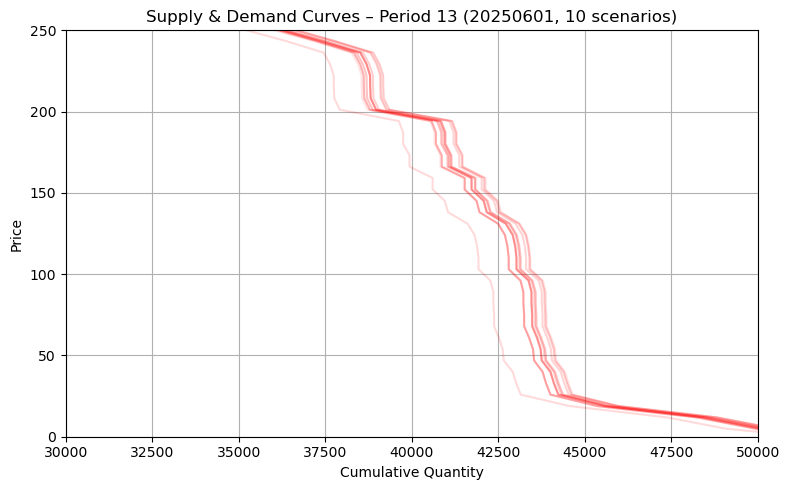

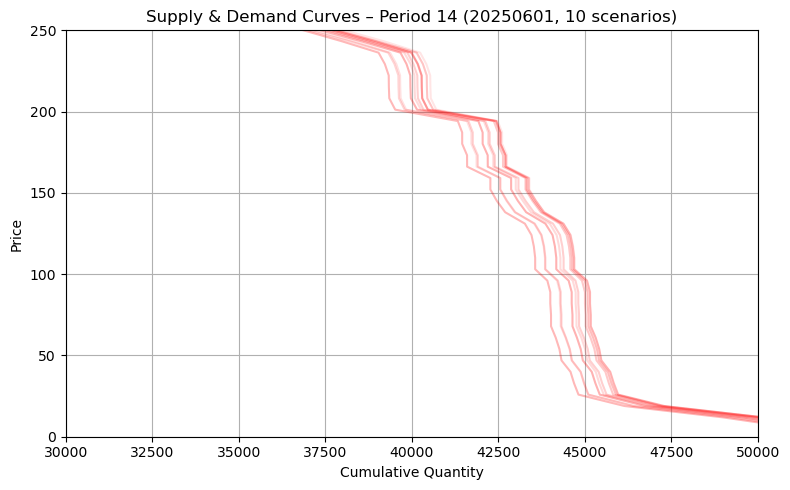

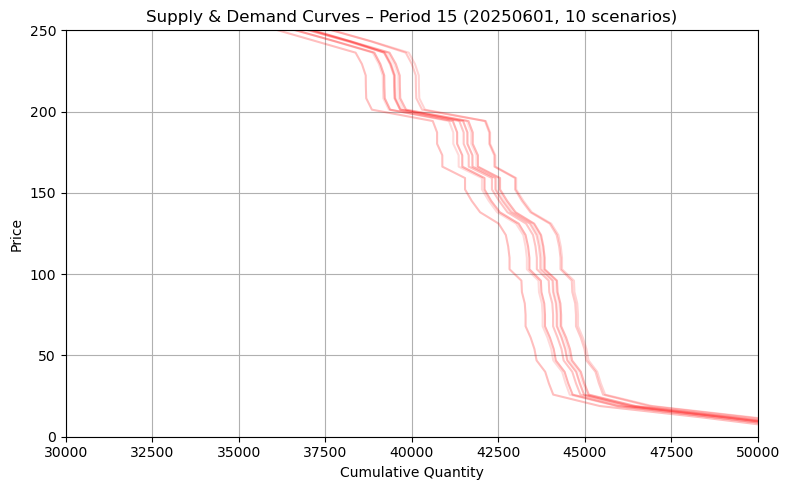

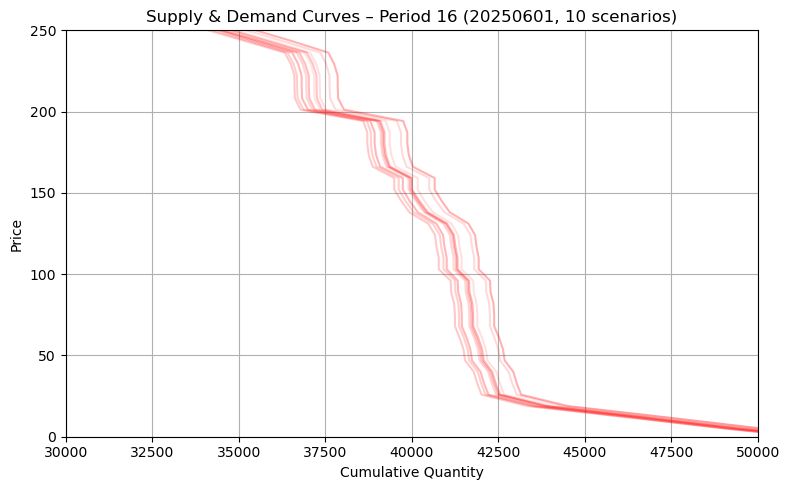

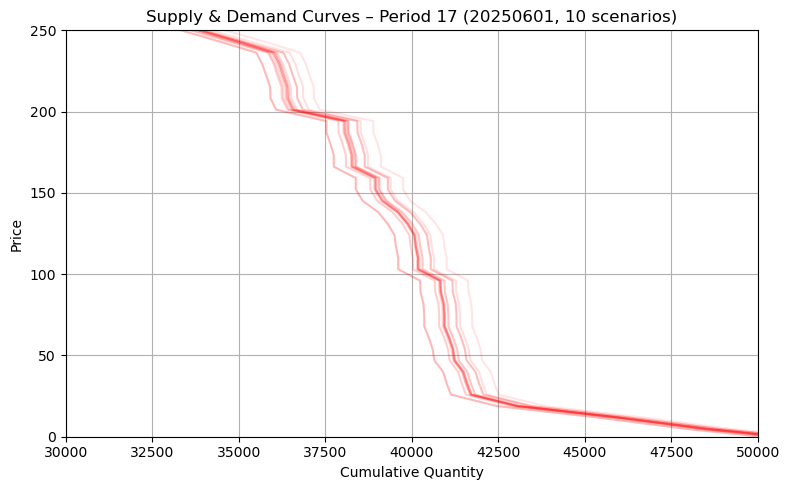

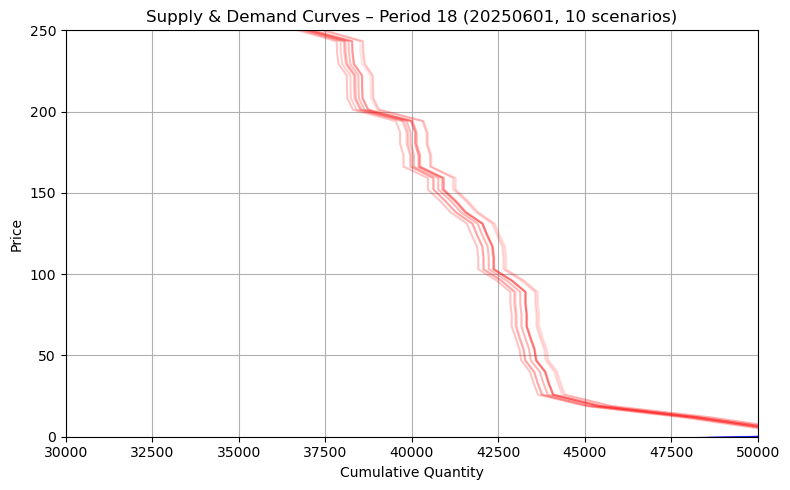

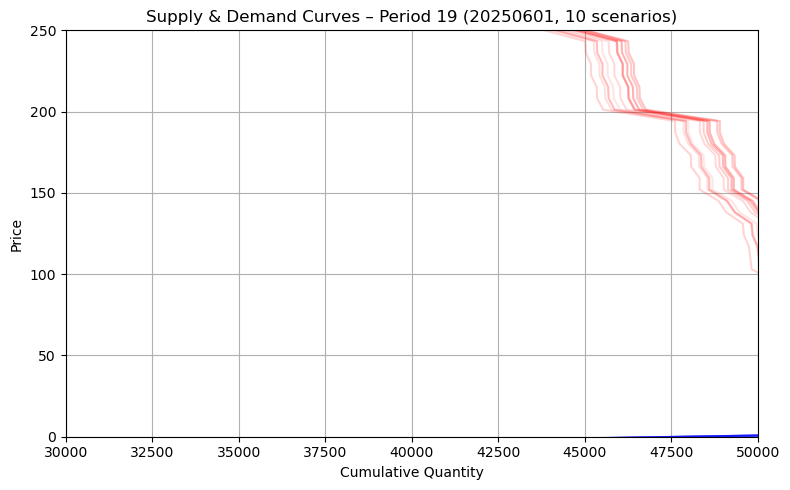

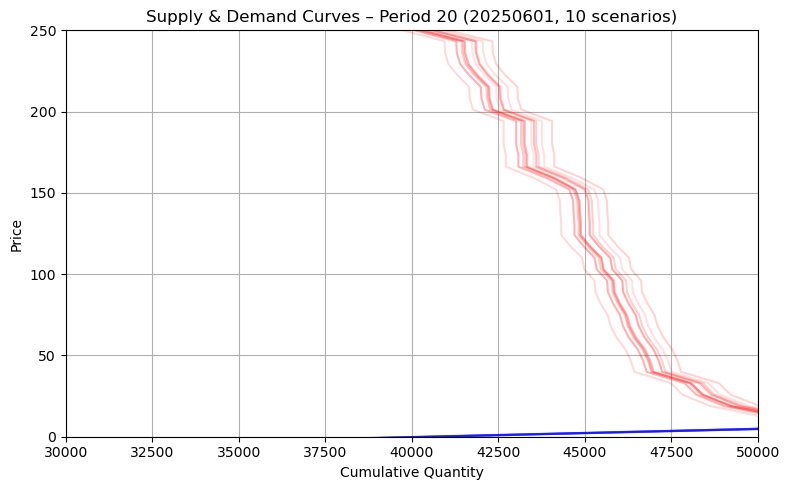

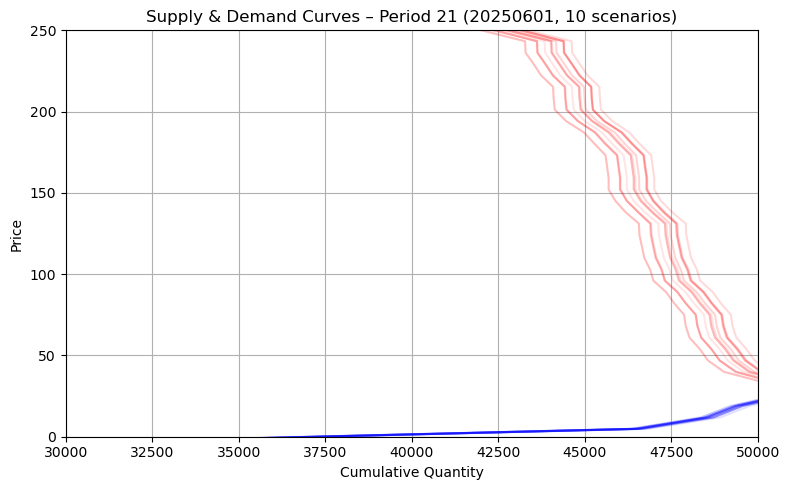

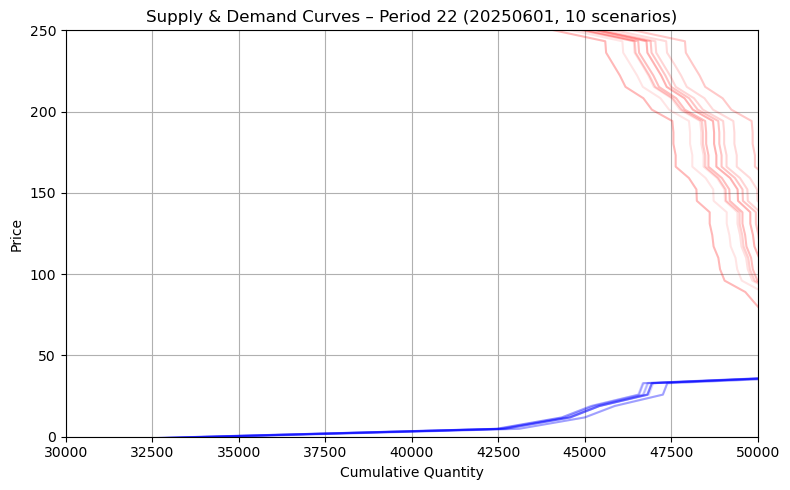

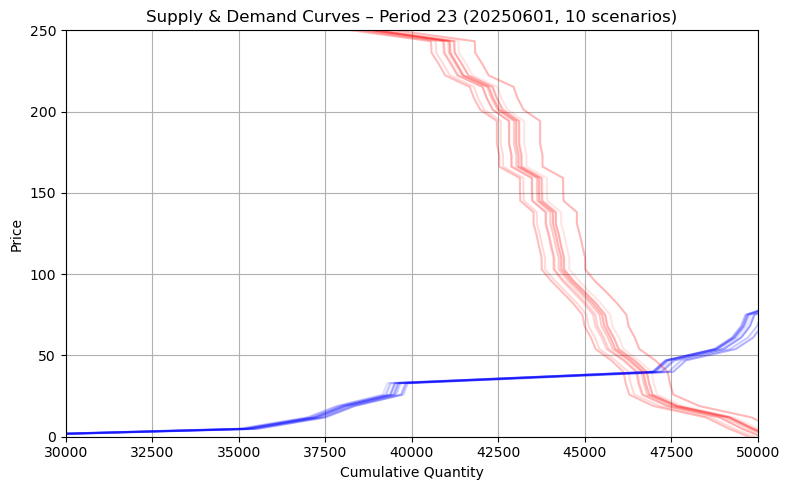

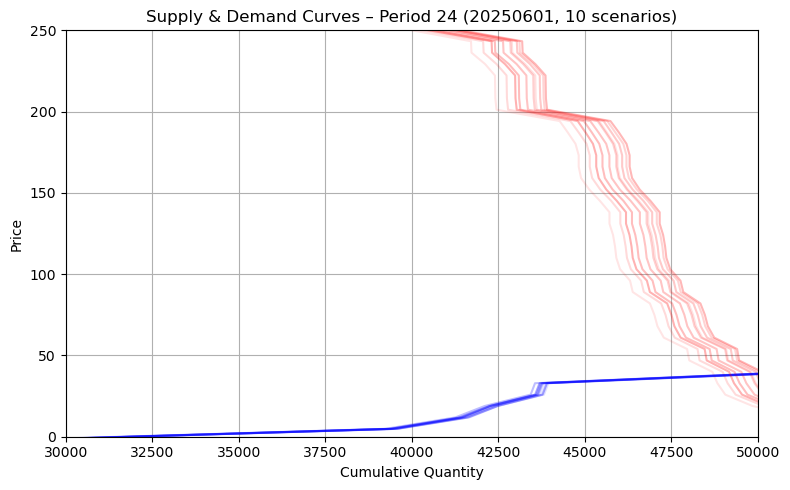

In [147]:
def load_curves_from_path(file_path, period):
    """시나리오 파일 경로 + 시간(period)로 공급/수요 곡선 반환"""
    df = pd.read_csv(file_path, sep=',', encoding='utf-8-sig')

    mask   = df['Time Period'] == period   # 이미 'Time Period' 로 맞춰주셨음
    supply = df[mask & (df['GC'] == 'V')]
    demand = df[mask & (df['GC'] == 'C')]
    if supply.empty or demand.empty:
        return None

    # 공급 곡선 집계
    s_agg = (supply.groupby('Price')['Amount'].sum()
                   .reset_index().sort_values('Price'))
    s_agg['CumulQty'] = s_agg['Amount'].cumsum()

    # 수요 곡선 집계
    d_agg = (demand.groupby('Price')['Amount'].sum()
                   .reset_index().sort_values('Price'))
    d_agg['CumulQty'] = d_agg['Amount'][::-1].cumsum()[::-1]

    # Price grid 기준 보간
    pmin = min(s_agg['Price'].min(), d_agg['Price'].min())
    pmax = max(s_agg['Price'].max(), d_agg['Price'].max())
    price_grid  = np.linspace(pmin, pmax, 500)

    s_func = interp1d(s_agg['Price'], s_agg['CumulQty'],
                      kind='previous', bounds_error=False,
                      fill_value=(0, s_agg['CumulQty'].iloc[-1]))
    d_func = interp1d(d_agg['Price'], d_agg['CumulQty'],
                      kind='previous', bounds_error=False,
                      fill_value=(d_agg['CumulQty'].iloc[0], 0))

    supply_vals = s_func(price_grid)
    demand_vals = d_func(price_grid)
    return price_grid, supply_vals, demand_vals

# --------------------------
# 시나리오 파일 불러오기
# --------------------------
date_str = "20250601"
scenario_dir = f"scenarios_{date_str}_2"
scenario_files = sorted(glob.glob(os.path.join(scenario_dir, "*.csv")))

# # --------------------------
# # 각 시간대마다 10개 시나리오 곡선 플롯
# # --------------------------
# for period in range(1, 25):  # 1~24
#     plt.figure(figsize=(8,5))
#     any_plotted = False

#     for fp in scenario_files:
#         out = load_curves_from_path(fp, period)
#         if out is None:
#             continue
#         price_grid, supply_vals, demand_vals = out

#         # 플롯 (투명도 α로 겹치기)
#         plt.plot(supply_vals, price_grid, color="blue", alpha=0.3, lw=1)
#         plt.plot(demand_vals, price_grid, color="red",  alpha=0.3, lw=1)
#         any_plotted = True

#     if not any_plotted:
#         print(f"{date_str} Period {period}: 데이터 없음")
#         plt.close()
#         continue

#     plt.xlabel("Cumulative Quantity")
#     plt.ylabel("Price")
#     plt.title(f"Supply & Demand Curves – Period {period} ({date_str}, 10 scenarios)")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()
# 색상 팔레트 (시나리오 개수에 맞춰 자동 생성)
# cmap = plt.get_cmap("tab10")   # tab10, tab20, viridis 등 선택 가능
# colors = [cmap(i % 10) for i in range(len(scenario_files))]

# # --------------------------
# # 각 시간대마다 시나리오별 다른 색으로 곡선 플롯
# # --------------------------
# for period in range(1, 25):  # 1~24
#     plt.figure(figsize=(8,5))
#     any_plotted = False

#     for idx, fp in enumerate(scenario_files):
#         out = load_curves_from_path(fp, period)
#         if out is None:
#             continue
#         price_grid, supply_vals, demand_vals = out

#         color = colors[idx]  # 시나리오별 고유 색상
#         plt.plot(supply_vals, price_grid, color=color, alpha=0.7, lw=1.5, label=f"Scenario {idx+1} Supply")
#         plt.plot(demand_vals, price_grid, color=color, alpha=0.7, lw=1.5, linestyle="--", label=f"Scenario {idx+1} Demand")
#         any_plotted = True

#     if not any_plotted:
#         print(f"{date_str} Period {period}: 데이터 없음")
#         plt.close()
#         continue
#     plt.xlim(0,60000)  # x축 0부터 시작
#     plt.ylim(-500,1500)  # x축 0부터 시작

#     plt.xlabel("Cumulative Quantity")
#     plt.ylabel("Price")
#     plt.title(f"Supply & Demand Curves – Period {period} ({date_str})")
#     plt.grid(True)
#     # plt.legend(fontsize=8, loc="best", ncol=2)
#     plt.tight_layout()
#     plt.show()
# --------------------------
# 각 시간대마다 시나리오별 다른 투명도로 곡선 플롯
# --------------------------
for period in range(1, 25):  # 1~24
    plt.figure(figsize=(8,5))
    any_plotted = False

    n_scen = len(scenario_files)
    # 0.3 ~ 1.0 사이 투명도 분배
    alphas = np.linspace(0.1, 0.3, n_scen)

    for idx, fp in enumerate(scenario_files):
        out = load_curves_from_path(fp, period)
        if out is None:
            continue
        price_grid, supply_vals, demand_vals = out

        alpha = alphas[idx]
        plt.plot(supply_vals, price_grid, color="blue", alpha=alpha, lw=1.5)
        plt.plot(demand_vals, price_grid, color="red",  alpha=alpha, lw=1.5)
        any_plotted = True

    if not any_plotted:
        print(f"{date_str} Period {period}: 데이터 없음")
        plt.close()
        continue
    plt.xlim(30000,50000)  # x축 0부터 시작
    plt.ylim(0,250)  # x축 0부터 시작
    plt.xlabel("Cumulative Quantity")
    plt.ylabel("Price")
    plt.title(f"Supply & Demand Curves – Period {period} ({date_str}, {n_scen} scenarios)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### RDC 시나리오

In [88]:
# --- RDC 계산 함수 ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc

# --- 공통 설정 ---
date_str      = "20250601"
scenario_dir  = f"scenarios_{date_str}"
scenario_files = sorted([f for f in os.listdir(scenario_dir) if f.endswith(".csv")])

wf_offer_grid = np.arange(0, 2000, 10)
B             = 500   # stepwise block 수
colors        = plt.cm.tab10(np.linspace(0,1,len(scenario_files)))

# stepwise 파라미터 저장용 dict
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

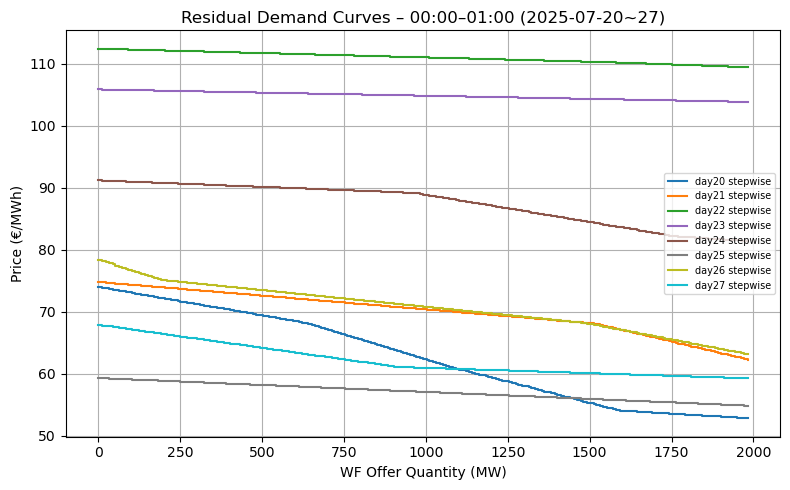

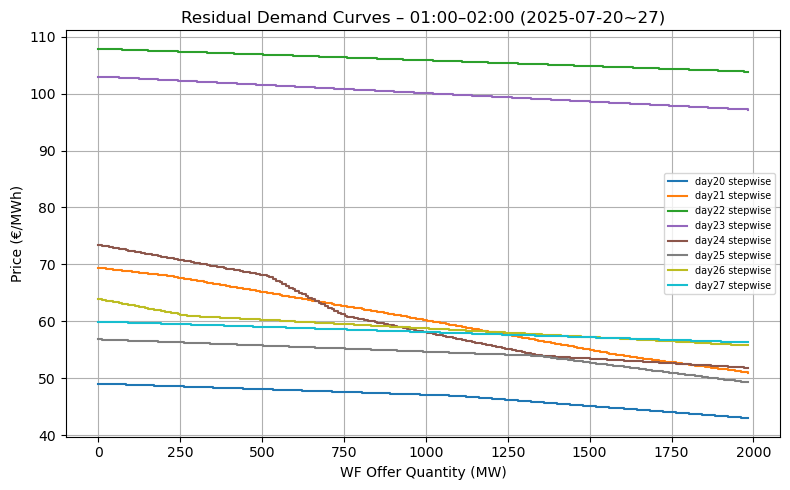

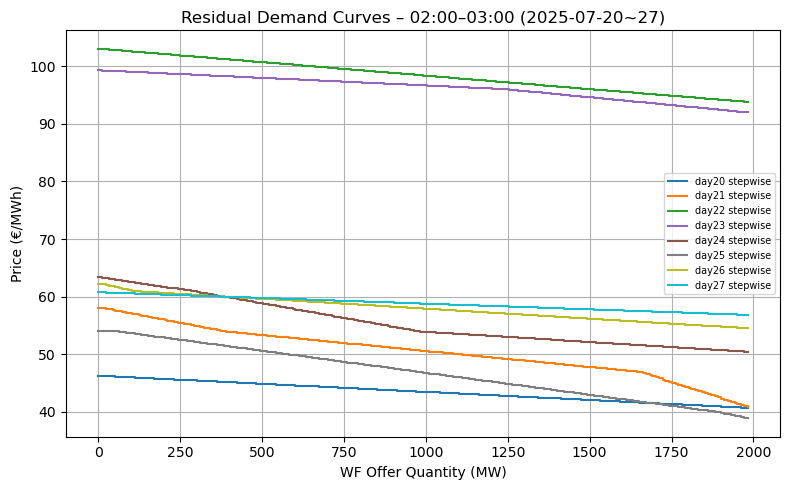

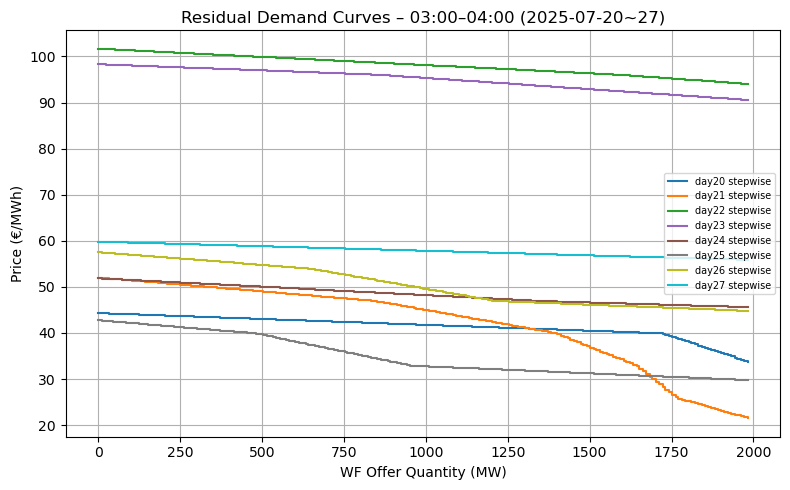

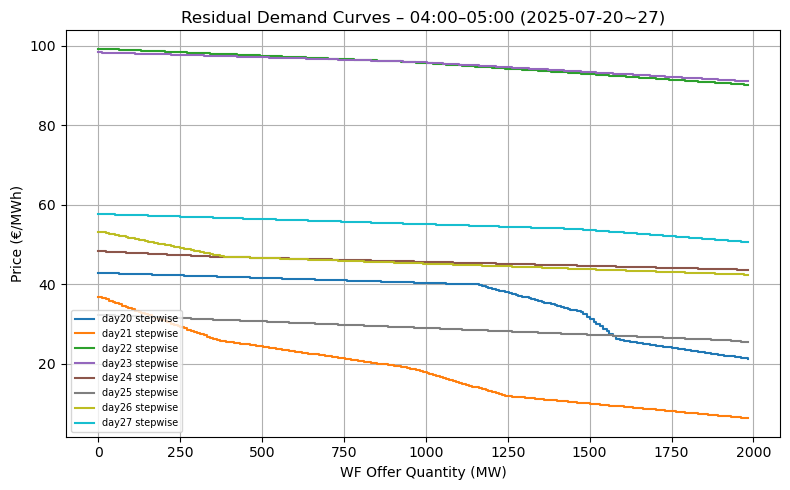

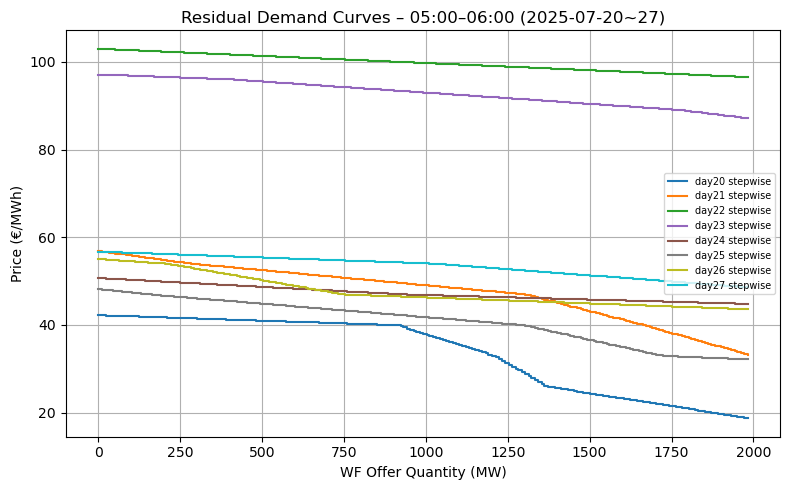

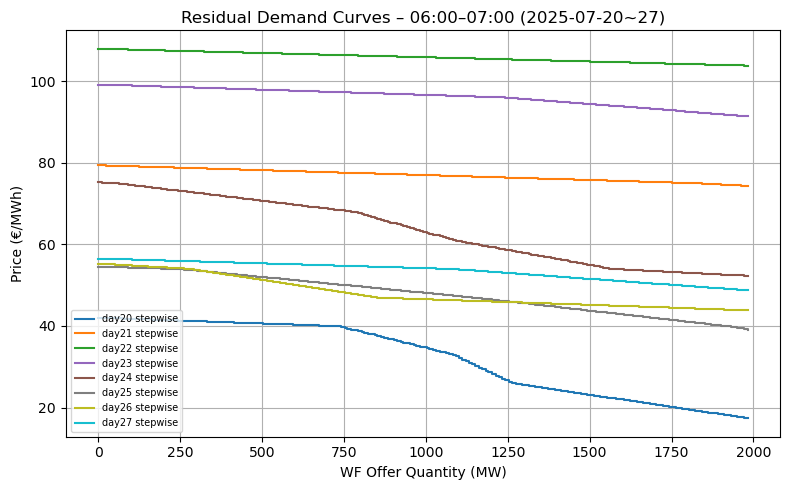

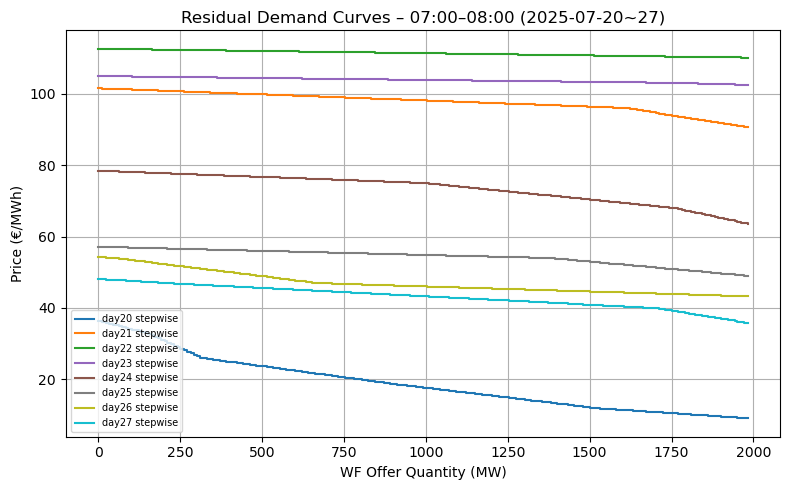

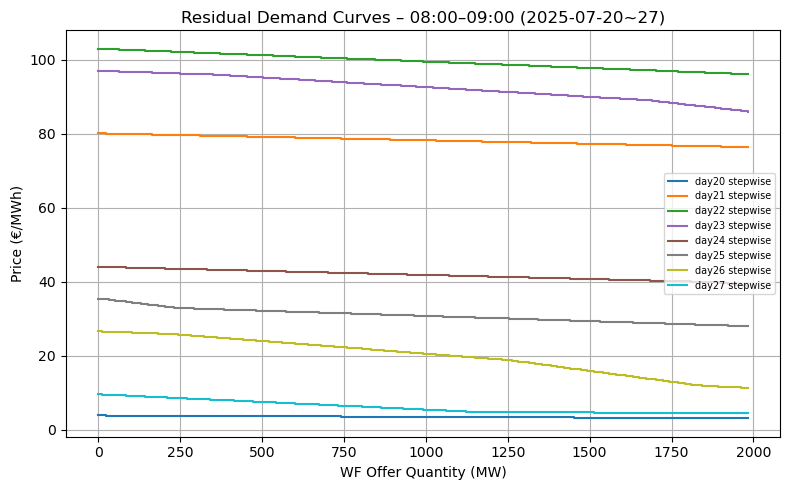

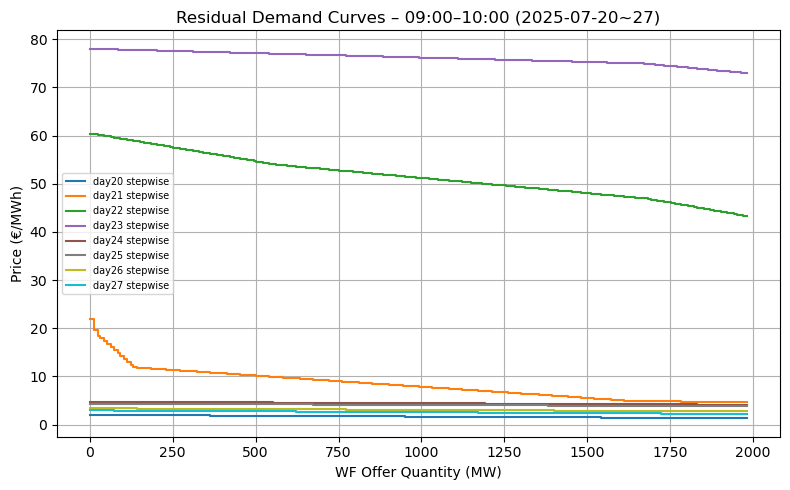

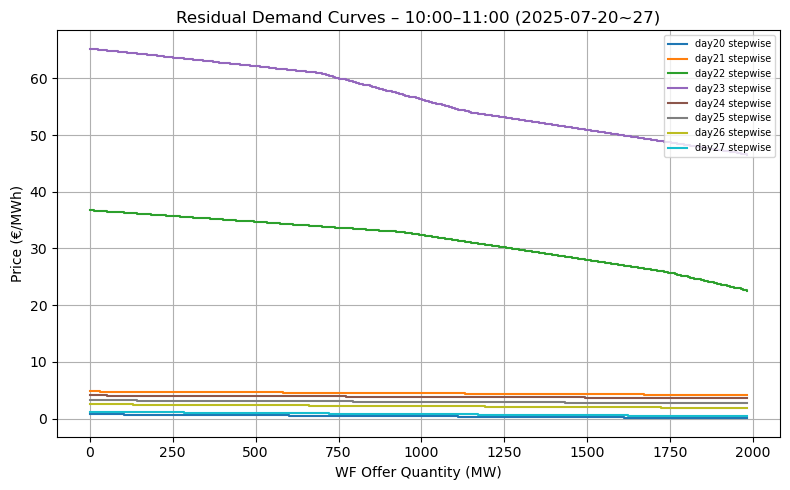

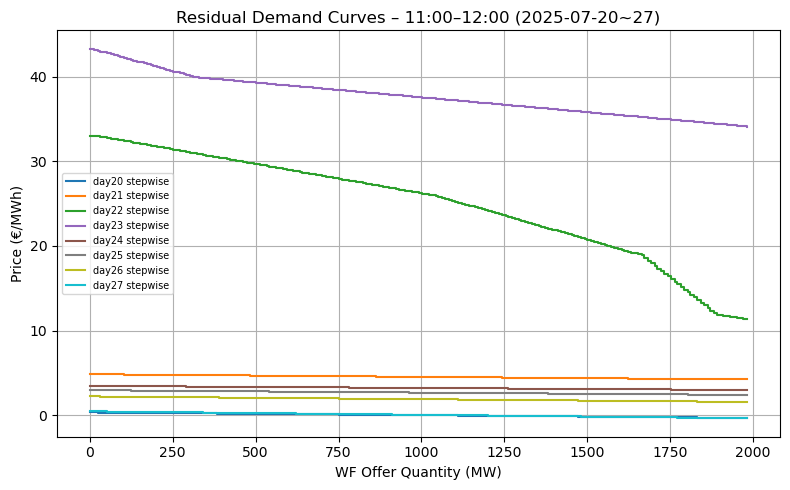

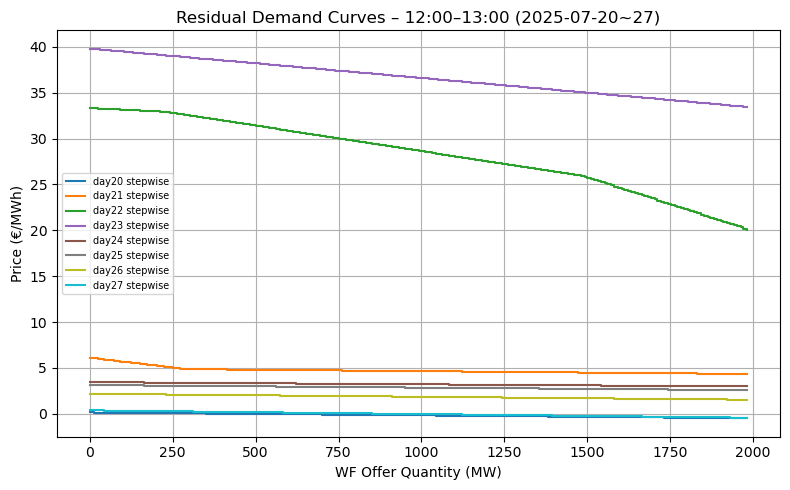

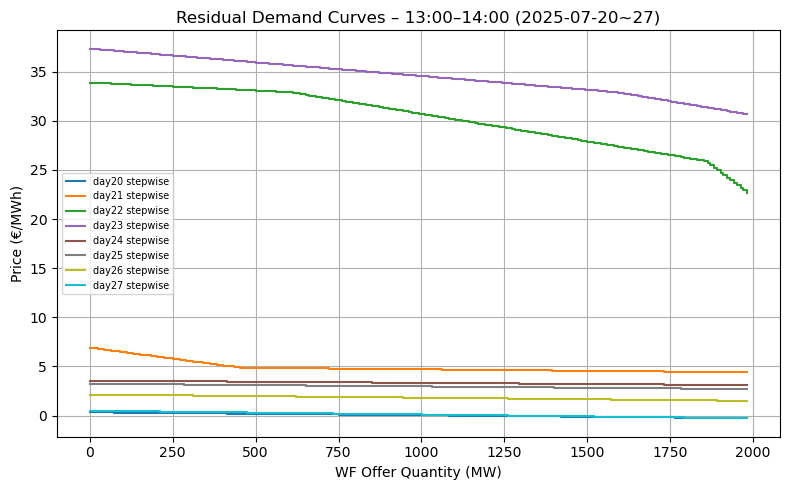

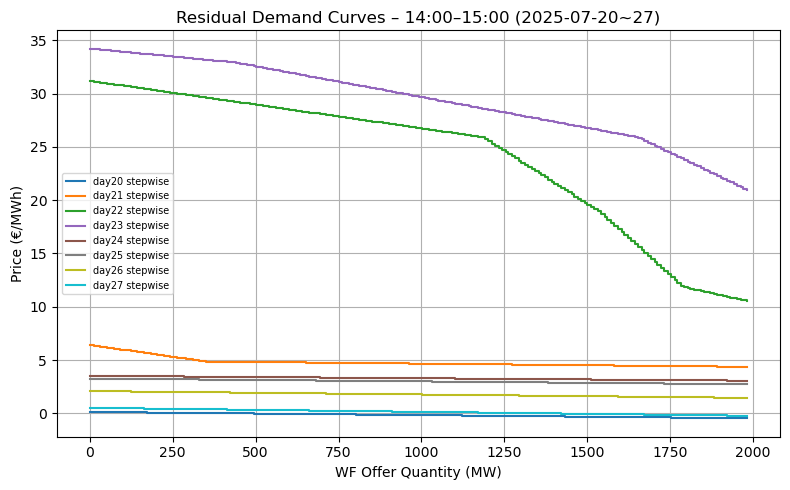

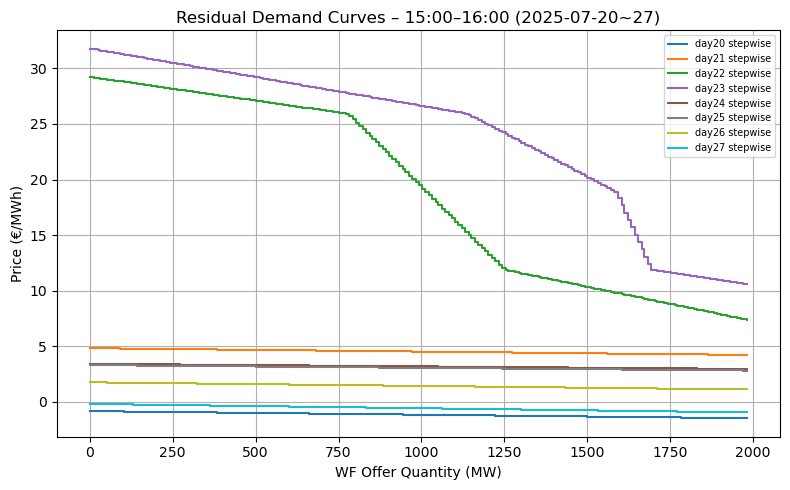

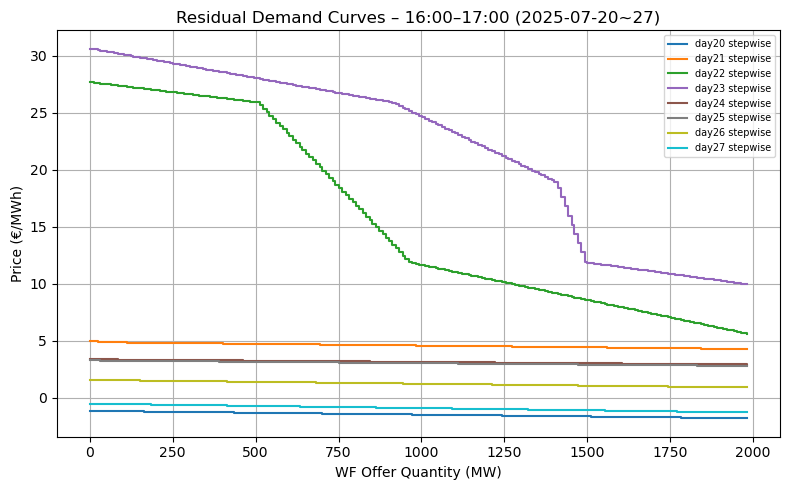

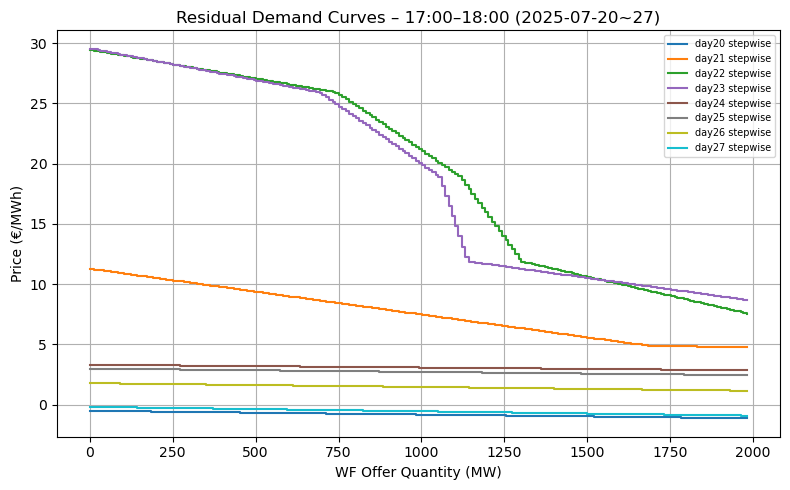

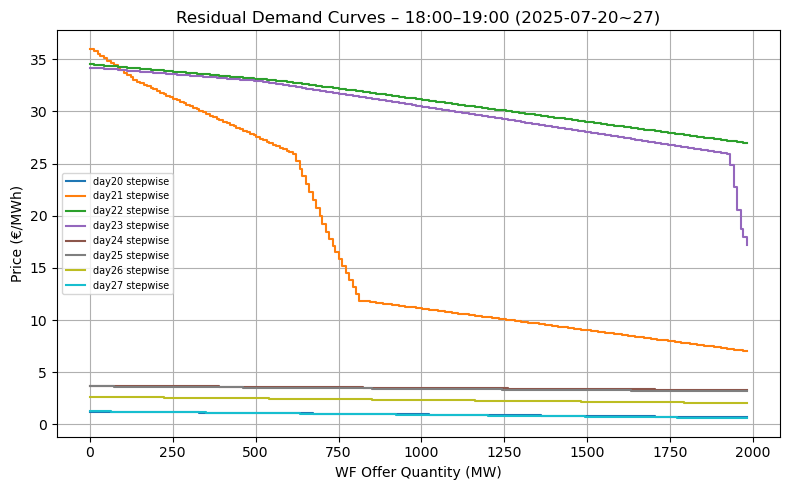

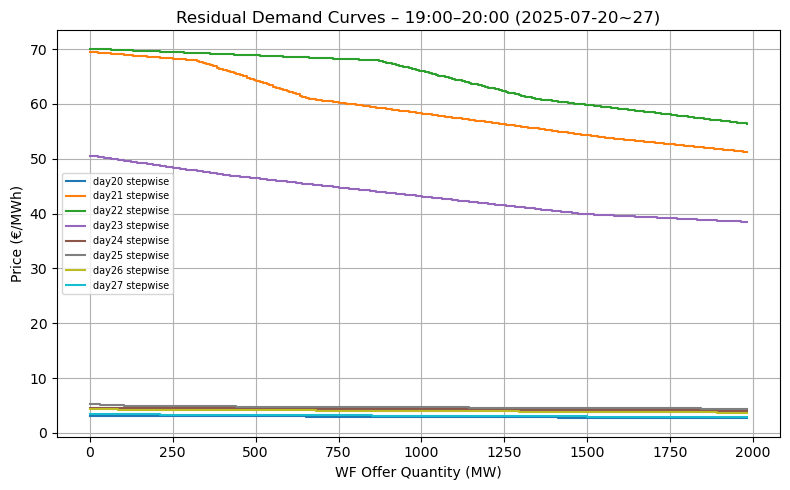

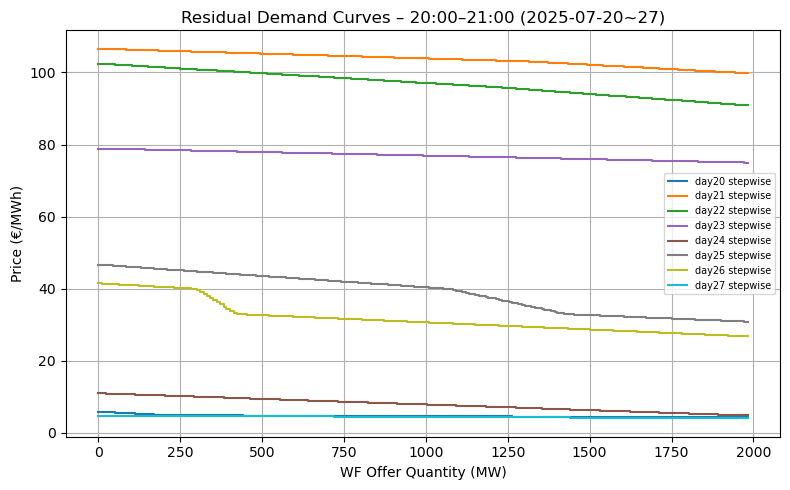

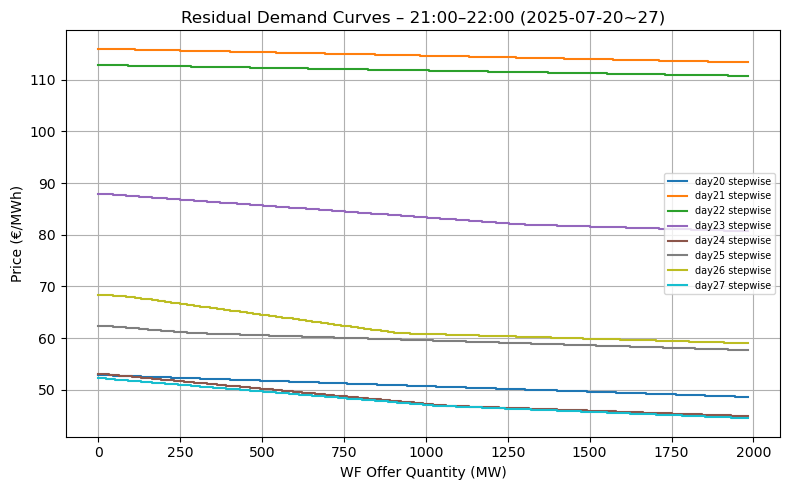

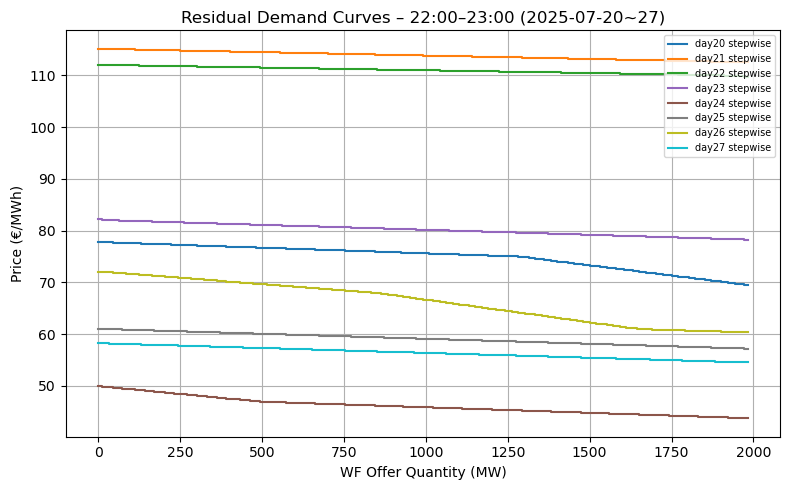

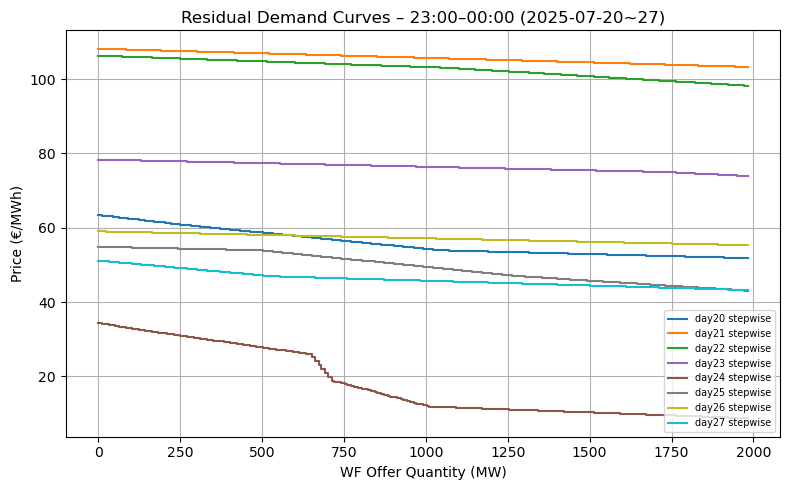

In [150]:
# --- RDC 계산 함수 ---
def compute_rdc_by_sign_change(price_grid, demand_vals, supply_vals, wf_offers):
    rdc = []
    for q in wf_offers:
        resid = demand_vals - supply_vals - q
        idx   = np.where(np.diff(np.sign(resid)) != 0)[0]
        for i in idx:
            p0,p1 = price_grid[i], price_grid[i+1]
            r0,r1 = resid[i], resid[i+1]
            if r1!=r0:
                p_star = p0 - r0*(p1-p0)/(r1-r0)
                rdc.append((q,p_star))
    return rdc


# --- 공통 설정 ---
days          = range(20,28)   # 2025-07-20 ~ 2025-07-27
wf_offer_grid = np.arange(0, 2000, 10)
B             = 500   # stepwise block 수
colors        = plt.cm.tab10(np.linspace(0,1,len(days)))

# stepwise 파라미터 저장용 dict
qini            = {}
qmax            = {}
lambda_da_block = {}
orig_cp         = {}

# --- 시간대별 Figure 하나씩 ---
for period in range(1,25):

    plt.figure(figsize=(8,5))

    for day, color in zip(days, colors):
        date_str = f"202507{day:02d}"
        scen_name = f"day{day}"  # 파일명 대신 날짜 표시용
        fn        = f"filteredcurve_{date_str}.csv"

        if not os.path.exists(fn):
            print(f"파일 없음: {fn}")
            continue

        df  = pd.read_csv(fn, encoding='utf-8-sig')

        sub = df[df['Time Period']==period]
        sup = sub[sub['GC']=='V']
        dem = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 공급/수요 집계
        s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 보간
        s_f = interp1d(s_agg['Price'], s_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(0, s_agg['Cumul'].iat[-1]))
        d_f = interp1d(d_agg['Price'], d_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(d_agg['Cumul'].iat[0], 0))

        pg = np.linspace(min(s_agg['Price'].min(), d_agg['Price'].min()),
                         max(s_agg['Price'].max(), d_agg['Price'].max()), 500)
        sv = s_f(pg); dv = d_f(pg)

        # RDC 계산
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)

        # stepwise 블록 경계 만들기
        q_breaks = np.linspace(min(qv), max(qv), B+1)

        for b in range(B):
            q_low, q_high = q_breaks[b], q_breaks[b+1]
            mask = (np.array(qv) >= q_low) & (np.array(qv) < q_high)
            if not mask.any():
                continue
            # 블록 내 대표값
            qini[(scen_name, period, b)] = q_low
            qmax[(scen_name, period, b)] = q_high - q_low
            lambda_da_block[(scen_name, period, b)] = np.mean(np.array(pv)[mask])

        # --- Stepwise 근사 곡선 플롯 ---
        q_step = [q_breaks[0]]
        p_step = [lambda_da_block[(scen_name, period, 0)]]

        for b in range(B):
            if (scen_name, period, b) not in lambda_da_block:
                continue
            q_high = q_breaks[b+1]
            lam    = lambda_da_block[(scen_name, period, b)]
            q_step.extend([q_high])
            p_step.extend([lam])
        
        plt.step(q_step, p_step, where="post", lw=1.5,
                 color=color, label=f"{scen_name} stepwise")

    # 시간대별 제목
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    plt.title(f"Residual Demand Curves – {hh1}–{hh2} (2025-07-20~27)")

    plt.xlabel("WF Offer Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.grid(True)
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


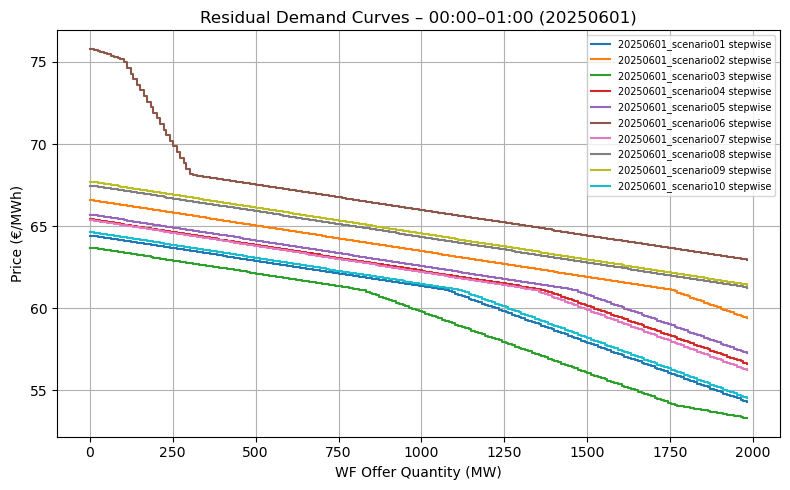

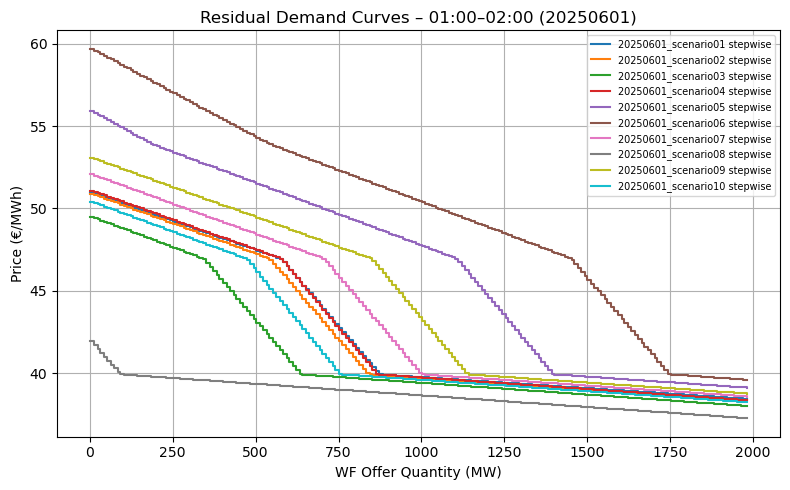

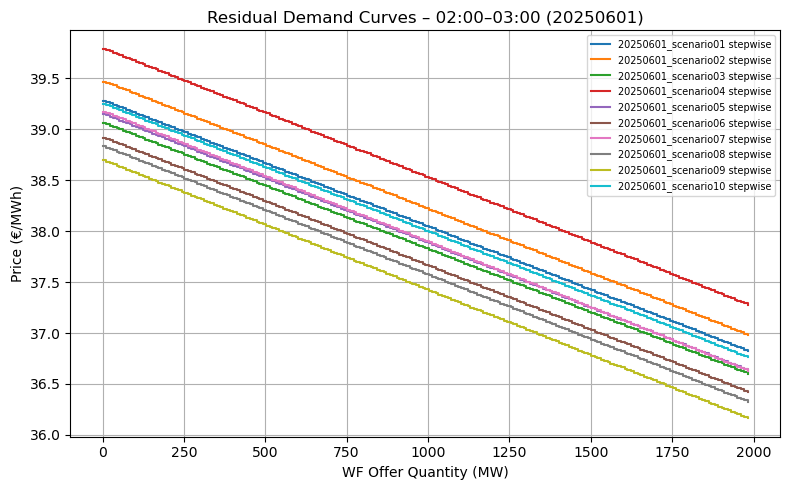

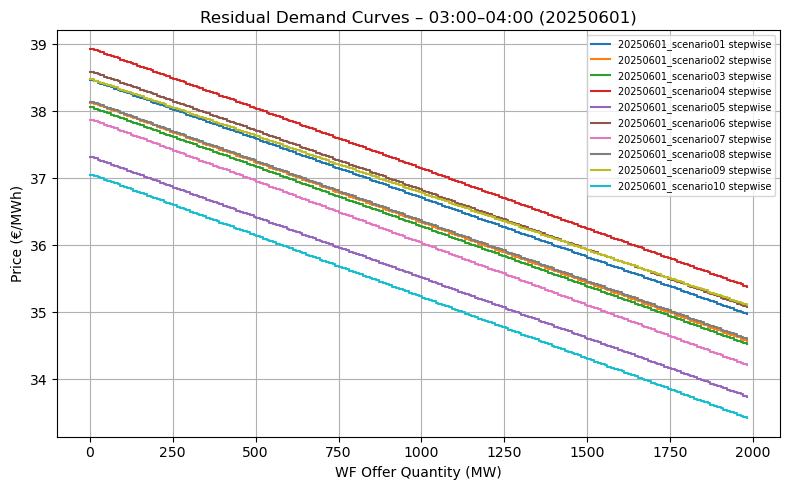

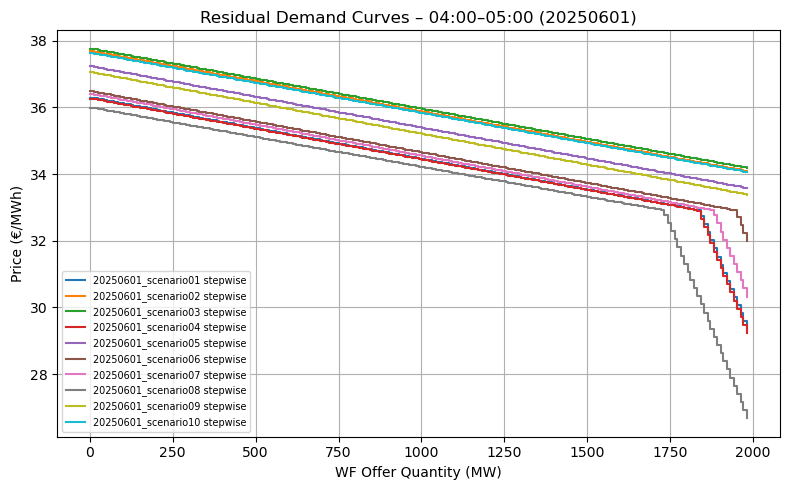

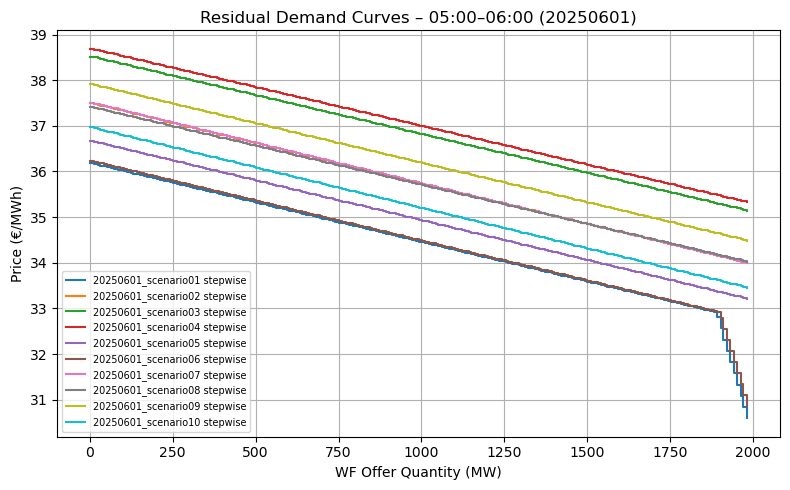

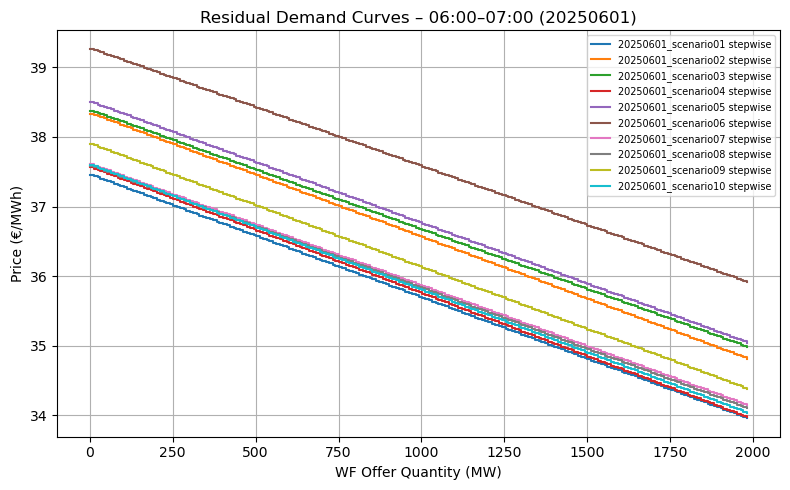

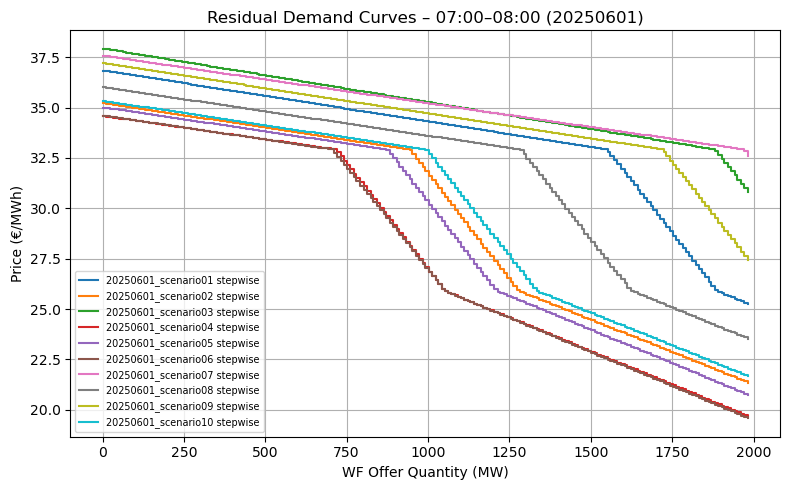

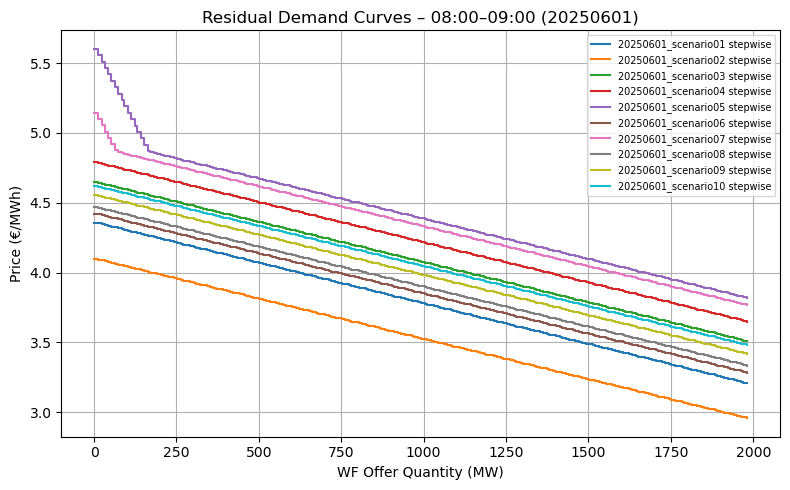

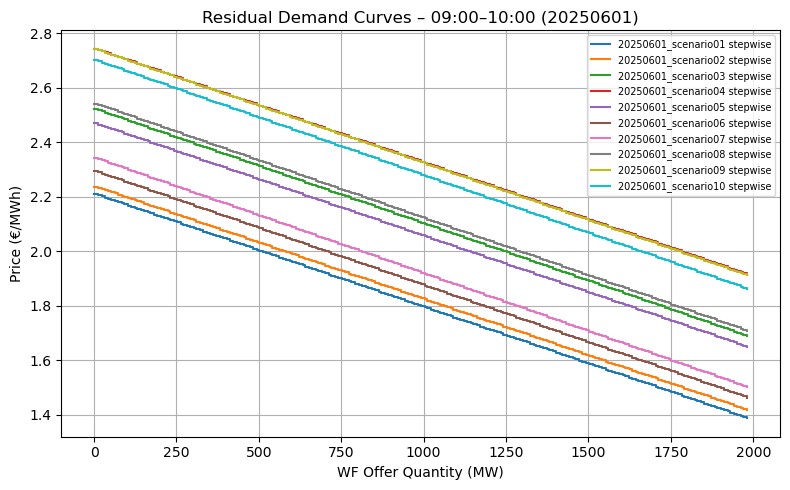

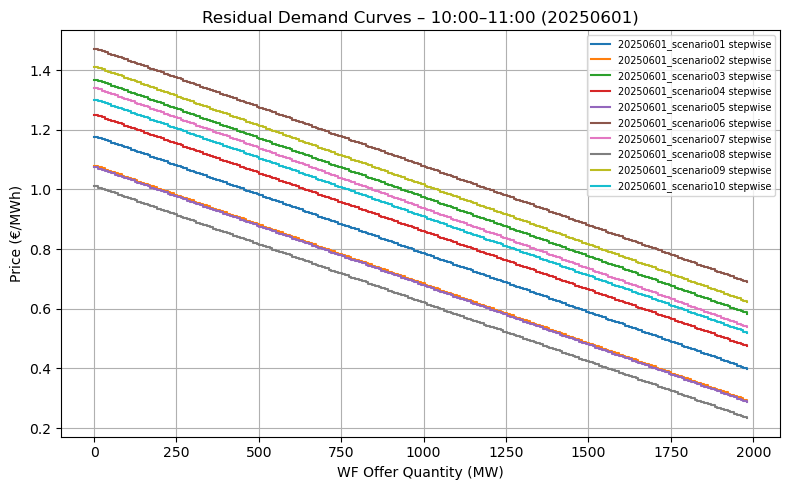

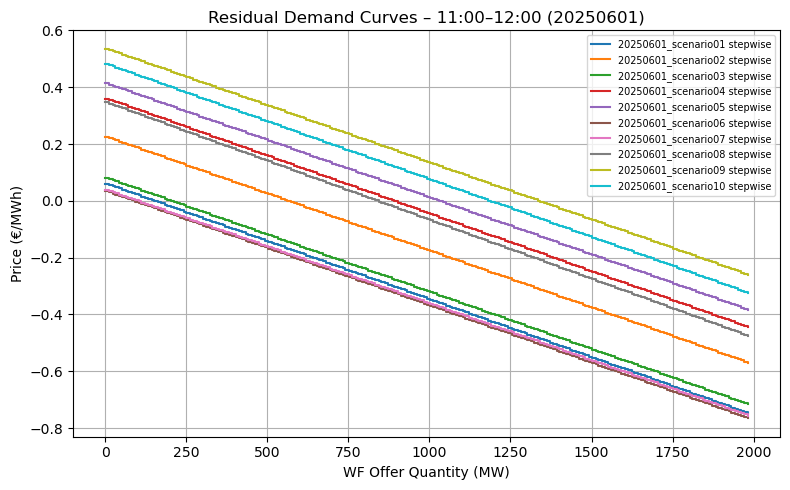

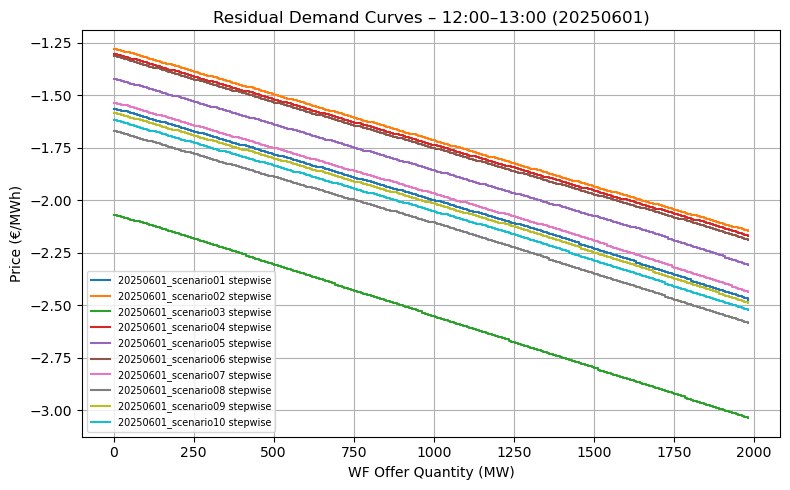

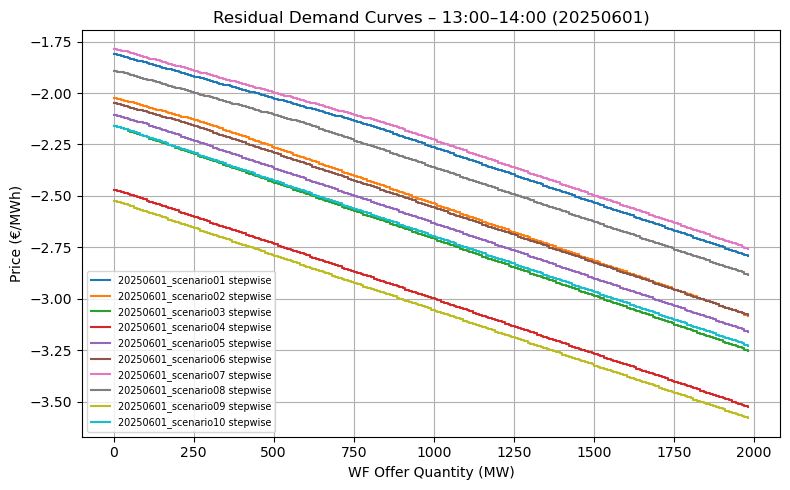

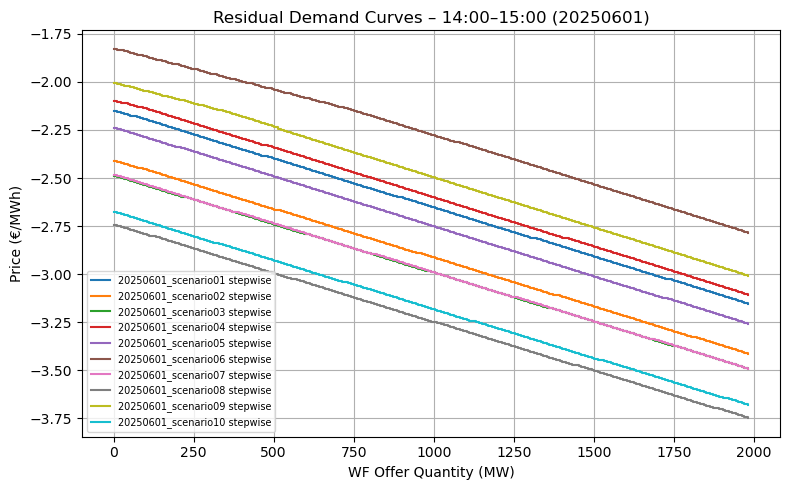

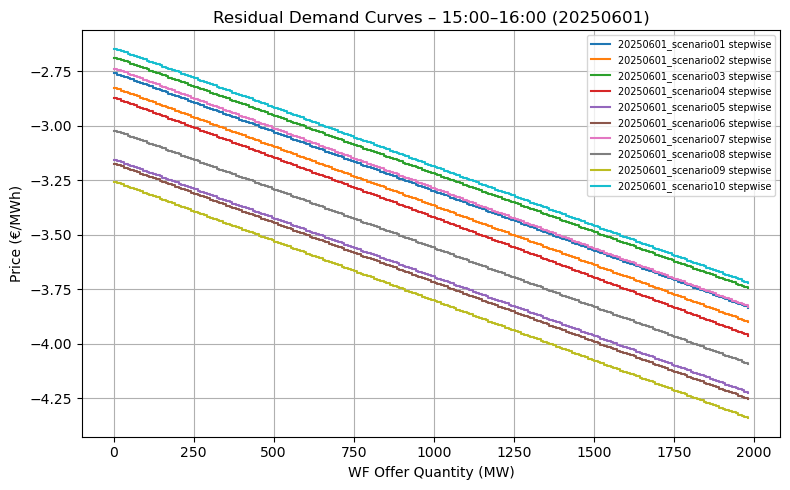

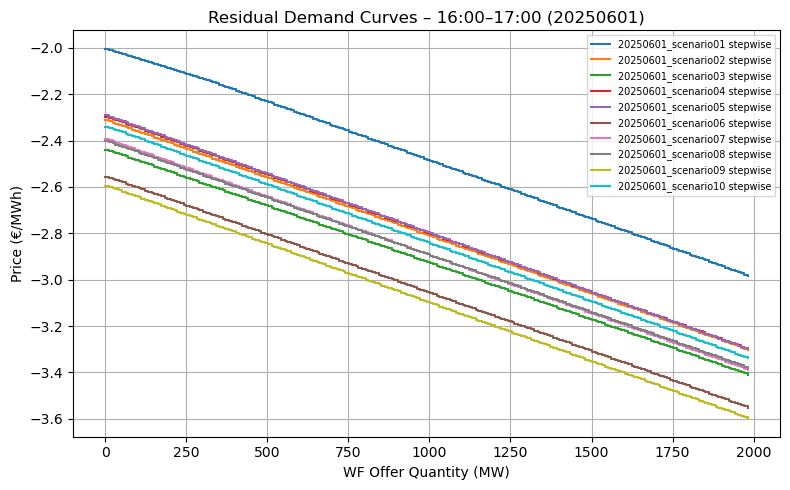

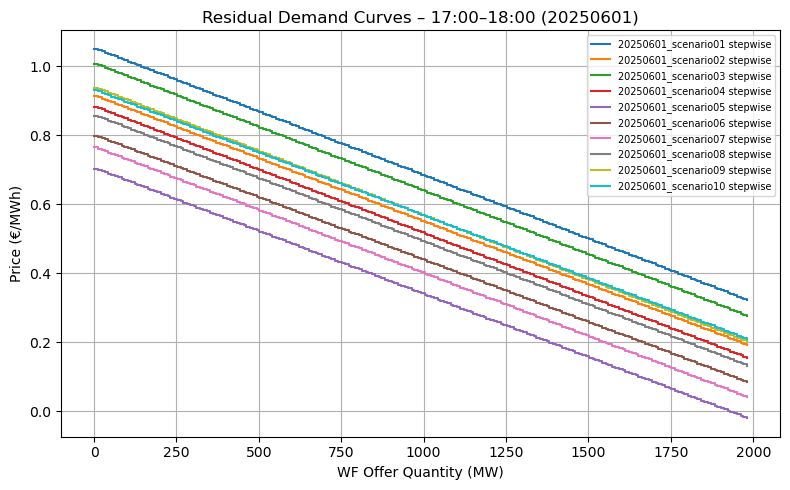

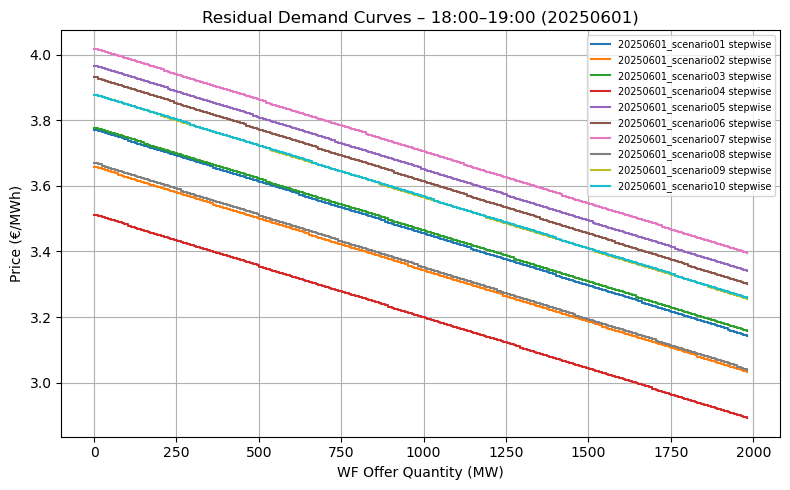

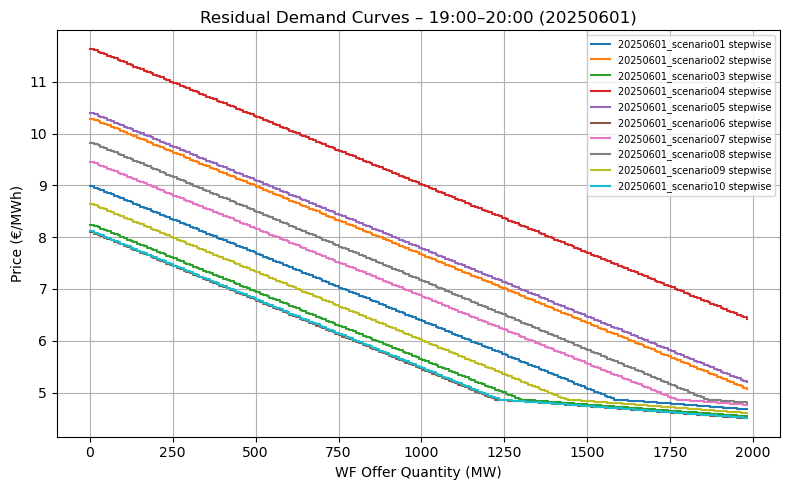

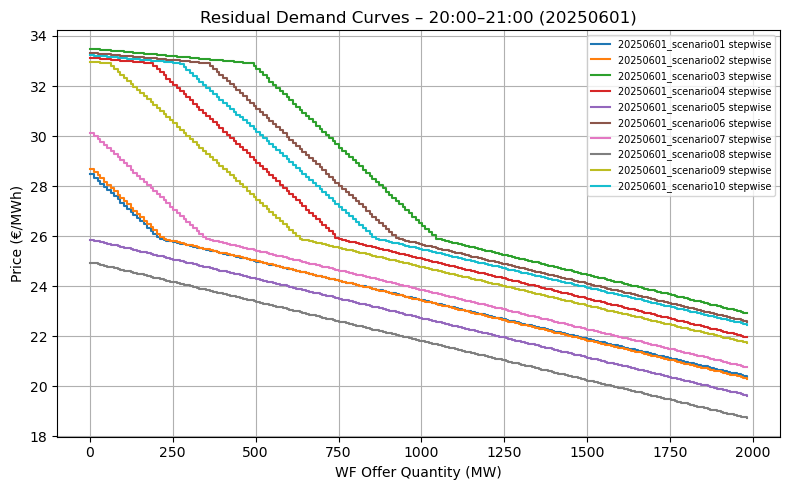

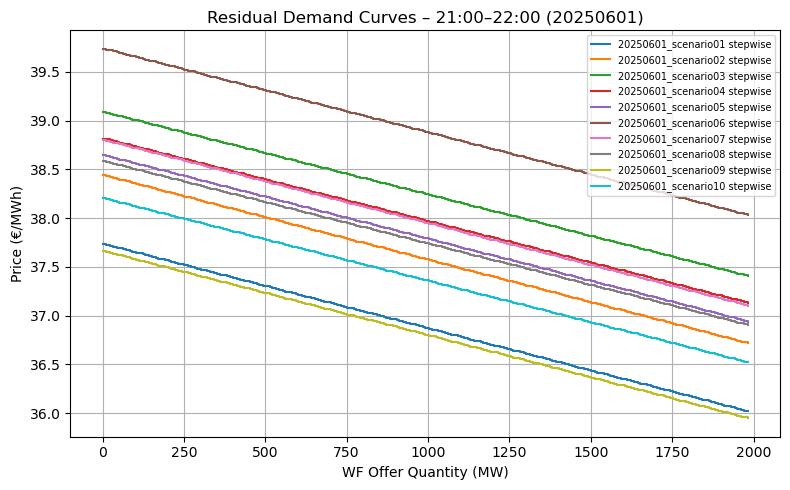

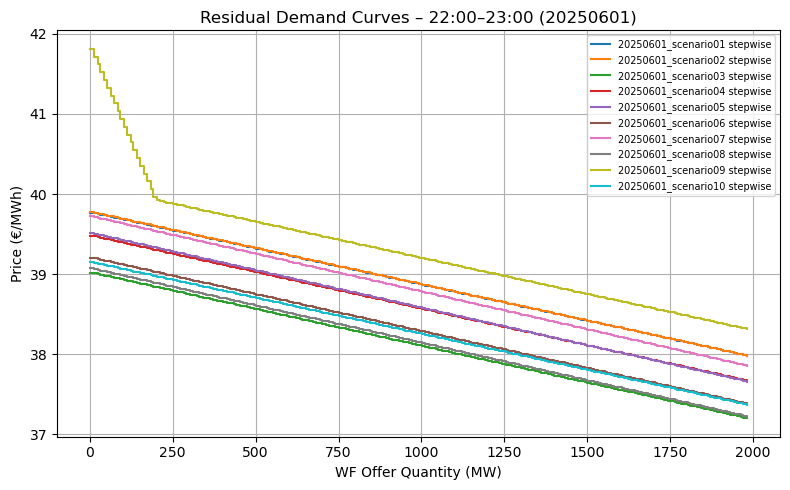

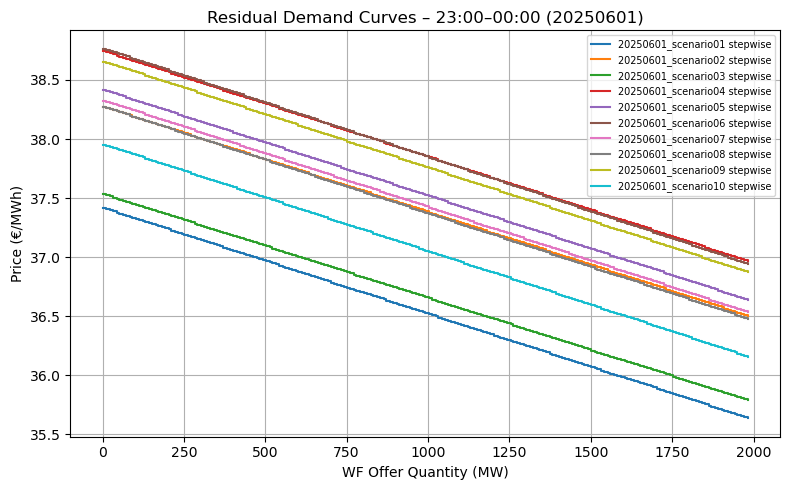

In [89]:
colors        = plt.cm.tab10(np.linspace(0,1,len(scenario_files)))

# --- 시간대별 Figure 하나씩 ---
for period in range(1,25):

    plt.figure(figsize=(8,5))

    for file, color in zip(scenario_files, colors):
        scen_name = os.path.splitext(file)[0]
        fn        = os.path.join(scenario_dir, file)
        df        = pd.read_csv(fn, encoding='utf-8-sig')

        sub = df[df['Time Period']==period]
        sup = sub[sub['GC']=='V']
        dem = sub[sub['GC']=='C']
        if sup.empty or dem.empty:
            continue

        # 공급/수요 집계
        s_agg = sup.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        s_agg['Cumul'] = s_agg['Amount'].cumsum()

        d_agg = dem.groupby('Price')['Amount'].sum().reset_index().sort_values('Price')
        d_agg['Cumul'] = d_agg['Amount'][::-1].cumsum()[::-1]

        # 보간
        s_f = interp1d(s_agg['Price'], s_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(0, s_agg['Cumul'].iat[-1]))
        d_f = interp1d(d_agg['Price'], d_agg['Cumul'],
                       kind='previous', bounds_error=False,
                       fill_value=(d_agg['Cumul'].iat[0], 0))

        pg = np.linspace(min(s_agg['Price'].min(), d_agg['Price'].min()),
                         max(s_agg['Price'].max(), d_agg['Price'].max()), 500)
        sv = s_f(pg); dv = d_f(pg)

        # RDC 계산
        rdc_pts = compute_rdc_by_sign_change(pg, dv, sv, wf_offer_grid)
        if not rdc_pts:
            continue
        qv, pv = zip(*rdc_pts)

        # stepwise 블록 경계 만들기
        q_breaks = np.linspace(min(qv), max(qv), B+1)

        for b in range(B):
            q_low, q_high = q_breaks[b], q_breaks[b+1]
            mask = (np.array(qv) >= q_low) & (np.array(qv) < q_high)
            if not mask.any():
                continue
            # 블록 내 대표값 (qini, qmax, lam_da)
            qini[(scen_name, period, b)] = q_low
            qmax[(scen_name, period, b)] = q_high - q_low
            lambda_da_block[(scen_name, period, b)] = np.mean(np.array(pv)[mask])


        # --- Plot ---
        # plt.plot(qv, pv, '-', color=color, linewidth=0.8, alpha=0.8, label=scen_name)
                # --- Plot 원래 RDC ---
        # plt.plot(qv, pv, '-', color=color, linewidth=0.8, alpha=0.8, label=f"{scen_name} RDC")

        # --- Plot Stepwise 근사 ---
        q_step = [q_breaks[0]]
        p_step = [lambda_da_block[(scen_name, period, 0)]]

        for b in range(B):
            q_low  = q_breaks[b]
            q_high = q_breaks[b+1]

            if (scen_name, period, b) not in lambda_da_block:
                continue

            lam = lambda_da_block[(scen_name, period, b)]
            # 수평선
            q_step.extend([q_high])
            p_step.extend([lam])
        
        # 계단형태로 그리기 (주황색)
        plt.step(q_step, p_step, where="post", lw=1.5, label=f"{scen_name} stepwise")

    # # 시간대별 제목
    hh1 = f"{period-1:02d}:00"; hh2 = f"{period%24:02d}:00"
    plt.title(f"Residual Demand Curves – {hh1}–{hh2} ({date_str})")

    plt.xlabel("WF Offer Quantity (MW)")
    plt.ylabel("Price (€/MWh)")
    plt.grid(True)
    plt.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

In [ ]:
# df = pd.DataFrame([
#     {
#         "scenario": scen,
#         "t": t,
#         "b": b,
#         "qini": qini[(scen,t,b)],
#         "qmax": qmax[(scen,t,b)],
#         "lam_da": lambda_da_block[(scen,t,b)]
#     }
#     for (scen,t,b) in qini.keys()
# ])

# df = df.sort_values(["scenario","t","b"]).reset_index(drop=True)

# # 저장
# df.to_csv("rdc_scenarios.csv", index=False, encoding="utf-8-sig")
# df.to_excel("rdc_scenarios.xlsx", index=False)

# print("✅ rdc_scenarios.csv / rdc_scenarios.xlsx 저장 완료!")

              scenario  t   b   qini  qmax     lam_da
0  20250601_scenario01  1   0   0.00  3.98  64.413927
1  20250601_scenario01  1   2   7.96  3.98  64.383133
2  20250601_scenario01  1   5  19.90  3.98  64.352339
3  20250601_scenario01  1   7  27.86  3.98  64.321544
4  20250601_scenario01  1  10  39.80  3.98  64.290750


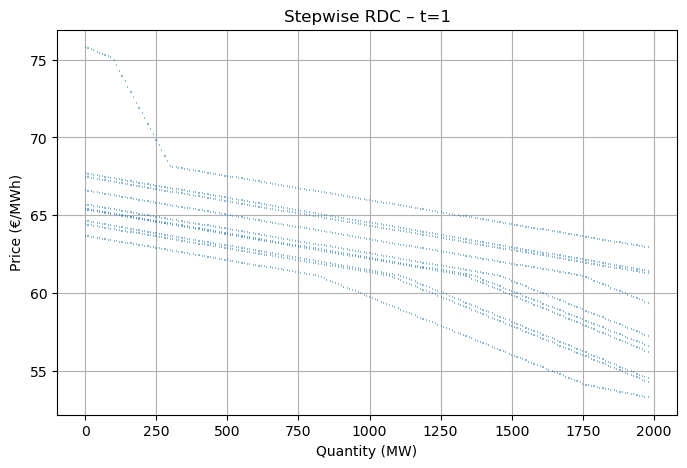

In [90]:
# 1) 저장된 CSV 불러오기
df = pd.read_csv("rdc_scenarios.csv", encoding="utf-8-sig")

print(df.head())   # 데이터 확인 (앞 5줄)

# 2) 특정 시간(t)에서 모든 시나리오 곡선 그리기
t_to_plot = 1   # 예: 2시(hour 2)

plt.figure(figsize=(8,5))

for scen in df["scenario"].unique():
    sub = df[(df["scenario"]==scen) & (df["t"]==t_to_plot)]
    if sub.empty:
        continue
    
    # qini ~ qini+qmax 까지 구간별 step plot
    q_starts = sub["qini"].values
    q_ends   = sub["qini"].values + sub["qmax"].values
    prices   = sub["lam_da"].values
    
    for qs, qe, p in zip(q_starts, q_ends, prices):
        plt.hlines(y=p, xmin=qs, xmax=qe, color="C0", alpha=0.5)
    
plt.xlabel("Quantity (MW)")
plt.ylabel("Price (€/MWh)")
plt.title(f"Stepwise RDC – t={t_to_plot}")
plt.grid(True)
plt.show()

### 발전량, RT 가격 시나리오 생성

In [8]:
S = list(range(10))                                     # 풍력 설비 0번만
I = list(range(1))                                     # 풍력 설비 0번만
T = list(range(1, 25))                                # 시간 1~24
J = [1,2,3,4]

In [134]:
# 15분 분할
#7월 20일 기준
rt_price_15min = [
    75.78, 75.54, 72.72, 42.23, 75.30, 75.30, 61.91, 35.25, 75.30, 48.33,
    39.81, 23.08, 65.80, 49.92, 33.81, 18.07, 45.68, 35.81, 26.04, 30.98,
    32.11, 36.47, 34.14, 29.49, 27.58, 34.34, 21.44, 33.44, 26.00,  3.30,
    -1.99, -8.99, 28.79,  0.49, -5.51, -6.31,  3.52,  0.65, -1.01, -5.90,
    -0.97, -3.00, -3.00,  0.00,  0.01,  4.31,  0.00,  0.00,  0.99,  0.99,
     0.14,  0.00,  0.65,  0.65,  0.65,  0.00,  0.99,  0.00,  0.00,  0.00,
    -0.65, -0.65, -0.50, -0.65,  0.00,  0.00,  0.00, -0.01, -0.61,  0.00,
     0.00,  0.00,  0.00,  0.00,  0.00,  0.00, -9.70, -0.97, 20.33, 79.89,
    -8.99,  8.81, 49.88, 83.87, 36.84, 66.60, 72.19, 75.54, 82.80, 82.80,
    85.21, 82.01, 86.16, 78.72, 72.27, 53.31
]
rt_price_15min = 0.4 * np.array(rt_price_15min)  # 15분 단위 RT 가격
# 1) 15분 가격을 (24시간 × 4구간) 배열로 재형성
rt15_arr = np.array(rt_price_15min).reshape(24, 4)

# (t,j) → price 사전 생성
#  t=1..24,  j=1..4
lambda_rt = {
    (t, j): float(rt15_arr[t-1, j-1])
    for t in T for j in J
}
sigma_eta = 0.1  # 실시간 가격 변동성 (5%)
# λ_rt_act[(t,j,s)] : 시나리오 s의 시간 t, 구간 j 실시간 가격
lambda_rt_act = {
    (t, j, s): rt15_arr[t-1, j-1] * (1 + sigma_eta * np.random.randn())
    for t in T for j in J for s in S
}

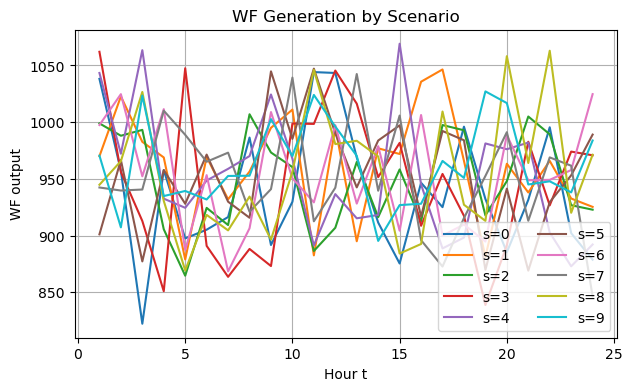

[CHECK] RT act min/max: -4.23 / 40.09,  negatives: 180개
[CHECK] WF  min/max/mean: 822.4 / 1069.2 / 952.4


In [135]:
sigma_frac = 0.05   # 5% 변동성
mu_frac    = 0.95   # 평균 95% 정격출력
Cw = 1000

np.random.seed(0)
pwf = {
    (i,t,s): max(0, np.random.normal(Cw*mu_frac, Cw*sigma_frac))
    for i in I for t in T for s in S
}

i0 = I[0]
fig4 = plt.figure(figsize=(7,4))
for s in S:
    wf_t = [pwf[(i0,t,s)] for t in T]
    plt.plot(T, wf_t, label=f"s={s}")
plt.title('WF Generation by Scenario')
plt.xlabel('Hour t')
plt.ylabel('WF output')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

# --- 5) 빠른 통계/이상치 점검 ---
rt_all = np.array([lambda_rt_act[(t,j,s)] for t in T for j in J for s in S])
wf_all = np.array([pwf[(i0,t,s)] for t in T for s in S])

neg_rt = np.sum(rt_all < 0)
print(f"[CHECK] RT act min/max: {rt_all.min():.2f} / {rt_all.max():.2f},  negatives: {neg_rt}개")
print(f"[CHECK] WF  min/max/mean: {wf_all.min():.1f} / {wf_all.max():.1f} / {wf_all.mean():.1f}")


### 시나리오 튜플 생성

In [136]:
# 1) CSV 불러오기
df = pd.read_csv("rdc_scenarios.csv", encoding="utf-8-sig")

# 2) 날짜 / 시나리오 / 시간 정의
date_range = df["scenario"].unique().tolist()
S = list(range(len(date_range)))     # 시나리오 index: 0,1,...
T = list(range(1, 25))               # 시간
I = [0]
J = [1,2,3,4]
Δt = 0.25
rho = {s: 1/len(S) for s in S}

# 시나리오 ID 문자열 → 숫자 매핑
s_map = {date: idx for idx, date in enumerate(date_range)}

# 3) 시나리오 맵 생성 (최종)
qini_scen_final      = {}
qmax_scen_final      = {}
lambda_da_scen_final = {}
valid_blocks         = {t: [] for t in T}

for (s,t), sub in df.groupby(["scenario","t"]):
    sub_sorted = sub.sort_values("qini").reset_index(drop=True)
    for b, r in sub_sorted.iterrows():
        s_idx = s_map[s]   # 문자열 시나리오 → 숫자 index
        qini_scen_final[(t,b,s_idx)]      = float(r["qini"])
        qmax_scen_final[(t,b,s_idx)]      = float(r["qmax"])
        lambda_da_scen_final[(t,b,s_idx)] = float(r["lam_da"])
        if r["qmax"] > 0:
            valid_blocks[t].append(b)

# 중복 제거
valid_blocks = {t: sorted(set(bs)) for t, bs in valid_blocks.items()}

print("예시 qini_scen_final keys:", list(qini_scen_final.keys())[:10])
print("예시 valid_blocks[1]:", valid_blocks[1])

예시 qini_scen_final keys: [(1, 0, 0), (1, 1, 0), (1, 2, 0), (1, 3, 0), (1, 4, 0), (1, 5, 0), (1, 6, 0), (1, 7, 0), (1, 8, 0), (1, 9, 0)]
예시 valid_blocks[1]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190

In [137]:
# ----------------------------
# 1) 1000개 조합의 w 인덱스 만들기
# ----------------------------
from itertools import product
triples = list(product(S, S, S))   # (rdc_s, gen_s, rt_s) 10*10*10 = 1000
W = list(range(len(triples)))      # w = 0..999
rho_w = [1/len(W)] * len(W)
# ----------------------------
# 2) (t,b,w) / (i,t,w) / (t,j,w) 빅 딕셔너리 생성
# ----------------------------
from collections import defaultdict

qini_big      = {}
qmax_big      = {}
lambda_da_big = {}
pwf_big       = {}
rt_big        = {}

# w별 유효 블록 (t,b) 집합도 함께 구축 (b가 없는 경우 KeyError 방지)
valid_blocks_by_w = defaultdict(list)   # key: (t,w) -> [b1,b2,...]

for w, (rdc_s, gen_s, rt_s) in enumerate(triples):
    # --- RDC: (t,b,rdc_s) -> (t,b,w)
    for (t,b,s) in qini_scen_final.keys():
        if s != rdc_s:
            continue
        qini_big[(t,b,w)]      = qini_scen_final[(t,b,s)]
        qmax_big[(t,b,w)]      = qmax_scen_final[(t,b,s)]
        lambda_da_big[(t,b,w)] = lambda_da_scen_final[(t,b,s)]
        # qmax>0인 블록만 유효 블록에 추가 (원래 valid_blocks[t]와 일치하게)
        if qmax_big[(t,b,w)] > 0:
            valid_blocks_by_w[(t,w)].append(b)

    # --- WF: (i,t,gen_s) -> (i,t,w)
    for (i,t,s) in pwf.keys():
        if s != gen_s:
            continue
        pwf_big[(i,t,w)] = pwf[(i,t,s)]

    # --- RT: (t,j,rt_s) -> (t,j,w)
    for (t,j,s) in lambda_rt_act.keys():
        if s != rt_s:
            continue
        rt_big[(t,j,w)] = lambda_rt_act[(t,j,s)]

# 중복 제거 및 정렬
for (t,w), bs in list(valid_blocks_by_w.items()):
    valid_blocks_by_w[(t,w)] = sorted(set(bs))

print("W 개수:", len(W))                      # 1000
print("예시 lambda_da_big key:", next(iter(lambda_da_big)))
print("예시 rt_big key:", next(iter(rt_big)))


W 개수: 1000
예시 lambda_da_big key: (1, 0, 0)
예시 rt_big key: (1, 1, 0)


## 최적화 모델: stochastic rdc

In [17]:
eta_c, eta_d    = 0.9, 0.9
E0, E_min, E_max = 1400, 500, 2250
pc_max, pd_max  = 500, 500
Δt = 0.25

In [138]:
model = gp.Model("WF_ESS_3D_RDC_RT_WF")

# ---------- 1단계(H&N) ----------
u = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                  vtype=GRB.BINARY, name="u")

# qvar, p_bid도 w에 종속(DA 기대값을 w로 평균)
qvar  = model.addVars([(t,b) for t in T for b in valid_blocks[t]],
                      lb=0.0, name="qvar")
p_bid = model.addVars(T, lb=0.0, name="p_bid")

# ESS on/off (H&N)
u_c = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d = model.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

# ---------- 2단계(Recourse; w별) ----------
p_c = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pc_max, name="p_c")
p_d = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, ub=pd_max, name="p_d")
E_q = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=E_min, ub=E_max, name="E_q")
p_b = model.addVars([(t,j,w) for t in T for j in J for w in W],
                    lb=0.0, name="p_b")

# LDR 계수(공통)
p_hat_c = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d     = model.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# ---------- 목적함수 ----------
# DA 수익
DA_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u[t,b] * qini_big[(t,b,w)] + qvar[t,b])
        for b in valid_blocks_by_w.get((t,w), [])
        if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)

# RT 수익
RT_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b[t,j,w] - p_bid[t]/4.0)
        for j in J if (t,j,w) in rt_big
    )
    for w in W for t in T
)

model.setObjective(DA_rev + RT_rev, GRB.MAXIMIZE)

In [139]:
# ---------- 제약식 (통일 버전) ----------
# 모든 (t,j,w)에 대해 균형
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_b[(t,j,w)] ==
                (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)   # 15분 평균 풍력
                + p_d[(t,j,w)] - p_c[(t,j,w)]                    # ESS 순발전
                - p_bid[t]/4.0,                                  # DA 약속의 1/4
                name=f"rt_balance_{t}_{j}_w{w}"
            )
# (6c) 매 시각 블록 하나 선택 (1단계 공통)
for t in T:
    model.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1,
                    name=f"one_block_{t}")

# (6d) qvar ≤ qmax * u  (모든 w에서 성립 → qmax_big[(t,b,w)] 사용, qvar은 w-비의존)
for w in W:
    for t in T:
        for b in valid_blocks[t]:
            model.addConstr(
                qvar[t,b] <= qmax_big[(t,b,w)] * u[t,b],
                name=f"qvar_max_{t}_{b}_w{w}"
            )

# (6e) p_bid 정의 (1단계 공통결정, 기대값 기반)
#  E[qini] = Σ_w rho_w[w] * qini_big[(t,b,w)]
mu_qini = {(t,b): sum(rho_w[w]*qini_big[(t,b,w)] for w in W)
           for t in T for b in valid_blocks[t]}

for t in T:
    model.addConstr(
        p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qvar[t,b]
                                for b in valid_blocks[t]),
        name=f"p_bid_def_{t}"
    )

# (6h, 6i) LDR (2단계, w-의존)  —— delta_rt 대신 실시간가격 rt_big 사용
#     p_c = u_c * (p̂_c + D_c * λ_rt),   p_d = u_d * (p̂_d + D_d * λ_rt)
for w in W:
    for t in T:
        for j in J:
            model.addConstr(
                p_c[(t,j,w)] == u_c[(t,j)] * (p_hat_c[(t,j)] + D_c[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pc_{t}_{j}_w{w}"
            )
            model.addConstr(
                p_d[(t,j,w)] == u_d[(t,j)] * (p_hat_d[(t,j)] + D_d[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pd_{t}_{j}_w{w}"
            )

# (6k) 동시 충방전 금지 + Big-M
for t in T:
    for j in J:
        model.addConstr(u_c[(t,j)] + u_d[(t,j)] <= 1, name=f"no_simul_{t}_{j}")
        for w in W:
            model.addConstr(p_c[(t,j,w)] <= pc_max * u_c[(t,j)],
                            name=f"pc_bigm_{t}_{j}_w{w}")
            model.addConstr(p_d[(t,j,w)] <= pd_max * u_d[(t,j)],
                            name=f"pd_bigm_{t}_{j}_w{w}")

# (6j) SOC 전이 (2단계, w-의존)
for w in W:
    for t in T:
        for j in J:
            prev = (E0 if (t == 1 and j == 1)
                    else (E_q[(t-1,4,w)] if j == 1 else E_q[(t,j-1,w)]))
            model.addConstr(
                E_q[(t,j,w)] == prev + Δt*(eta_c*p_c[(t,j,w)] - p_d[(t,j,w)]/eta_d),
                name=f"SOC_{t}_{j}_w{w}"
            )

# (6g) DA vs RT 약속량 경계 (1단계 p_bid[t] vs 2단계 실현치)
#  풍력(gen) 시나리오 인덱스는 triplet_of[w][1] 이나,
#  이미 pwf_big[(i,t,w)] 로 매핑되어 있으니 그걸 그대로 사용
for w in W:
    for t in T:
        # 상한: 풍력 발전 + 방전
        rhs = 1000 + gp.quicksum(p_d[(t,j,w)] for j in J)
        # 하한: -충전
        model.addConstr(-gp.quicksum(p_c[(t,j,w)] for j in J) <= p_bid[t],
                        name=f"bid_low_{t}_w{w}")
        # 상한
        model.addConstr(p_bid[t] <= rhs, name=f"bid_up_sync_{t}_w{w}")

# 옵션 파라미터
model.Params.MIPGap = 0.02
model.Params.TimeLimit = 3600
model.Params.Heuristics = 0.1
# model.feasRelaxS(0, True, False, True)
model.optimize()


Set parameter MIPGap to value 0.02
Set parameter TimeLimit to value 3600
Set parameter Heuristics to value 0.1
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 5208144 rows, 394152 columns and 10957520 nonzeros
Model fingerprint: 0x5fd1c06e
Model has 192000 quadratic constraints
Variable types: 389184 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [3e-03, 4e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [3e-06, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 24000 rows and 96036 columns (presolve time = 5s) ...
Presolve removed 4795224 rows and 96036 columns
Presolve time: 7.78s
Presolved: 605616 rows, 299160 columns, 1740812 nonzeros
Presolved model

In [20]:
Z_RP = model.ObjVal

In [96]:
Z_RP2 = model.ObjVal

In [140]:
# 선택된 블록
chosen_b = {t: max(valid_blocks[t], key=lambda b: u[t,b].X) for t in T}

# DA 입찰
p_bid_sol = {t: p_bid[t].X for t in T}

# ESS 제어 (시나리오 평균/첫 시나리오 예시)
p_c_mean = {(t,j): sum(rho_w[w]*p_c[t,j,w].X for w in W) for t in T for j in J}
p_d_mean = {(t,j): sum(rho_w[w]*p_d[t,j,w].X for w in W) for t in T for j in J}
E_mean   = {(t,j): sum(rho_w[w]*E_q[t,j,w].X for w in W) for t in T for j in J}


In [145]:
import csv
with open("solution_da_rt0919.csv","w",newline="",encoding="utf-8-sig") as f:
    wtr = csv.writer(f)
    wtr.writerow(["t","chosen_b","p_bid","p_c_mean","p_d_mean","E_mean"])
    for t in T:
        for j in J:
            wtr.writerow([t, chosen_b[t], p_bid_sol[t], p_c_mean[t,j], p_d_mean[t,j], E_mean[t,j]])
print("saved: solution_09160556.csv")


saved: solution_09160556.csv


In [93]:
# Original CP는 "qvar=0"일 때 선택된 블록 b의 clearing price로 정의
orig_cp = []
for t, b in zip(df_q["t"], df_q["chosen_b"]):
    # qvar=0 기준, 해당 블록의 가격 불러오기
    if (t, b, 0) in lambda_da_big:
        orig_cp.append(lambda_da_big[(t,b,0)])
    else:
        orig_cp.append(None)  # 데이터 없으면 빈 값

df_q["orig_cp"] = orig_cp

In [103]:
print("예시 키:", list(lambda_da_big.keys())[:10])
print("예시 valid_blocks[1]:", valid_blocks[1][:10])
print("S 크기:", len(S))


예시 키: [(1, 0, 0), (1, 1, 0), (1, 2, 0), (1, 3, 0), (1, 4, 0), (1, 5, 0), (1, 6, 0), (1, 7, 0), (1, 8, 0), (1, 9, 0)]
예시 valid_blocks[1]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
S 크기: 10


In [104]:
df_q = df.groupby("t").first().reset_index()

q_ini = []
q_var = []
for t, b, bid in zip(df_q["t"], df_q["chosen_b"], df_q["p_bid"]):
    vals = [qini_big.get((t,b,s), 0) for s in S]
    qini_mean = np.mean(vals) if vals else 0
    q_ini.append(qini_mean)
    q_var.append(bid - qini_mean)

df_q["q_ini"] = q_ini
df_q["q_var"] = q_var


In [105]:
orig_cp = []
new_cp  = []
for t, b, bid in zip(df_q["t"], df_q["chosen_b"], df_q["p_bid"]):
    lam_vals = [lambda_da_big[(t,b,s)] for s in S if (t,b,s) in lambda_da_big]
    orig_cp.append(np.mean(lam_vals) if lam_vals else np.nan)

    lam_candidates = []
    for s in S:
        diffs = [(abs(qini_big[(t,b2,s)] - bid), lambda_da_big[(t,b2,s)]) 
                 for b2 in valid_blocks[t] if (t,b2,s) in qini_big]
        if diffs:
            lam_candidates.append(min(diffs, key=lambda x: x[0])[1])
    new_cp.append(np.mean(lam_candidates) if lam_candidates else np.nan)

df_q["orig_cp"] = orig_cp
df_q["new_cp"]  = new_cp


In [151]:
# --- Original clearing price 계산 (WF=0) ---
resid0 = dv - sv   # demand - supply
idx0   = np.where(np.diff(np.sign(resid0)) != 0)[0]

if len(idx0) > 0:
    i = idx0[0]
    p0, p1 = pg[i], pg[i+1]
    r0, r1 = resid0[i], resid0[i+1]
    if r1 != r0:
        cp0 = p0 - r0 * (p1 - p0) / (r1 - r0)
        orig_cp[(scen_name, period)] = cp0

In [152]:
df = pd.DataFrame([
    {
        "scenario": scen,
        "t": t,
        "b": b,
        "qini": qini[(scen,t,b)],
        "qmax": qmax[(scen,t,b)],
        "lam_da": lambda_da_block[(scen,t,b)],
        "orig_cp": orig_cp.get((scen,t), None)   # 추가
    }
    for (scen,t,b) in qini.keys()
])


In [101]:
orig_cp = []
new_cp  = []

for t, b in zip(df_q["t"], df_q["chosen_b"]):
    # 모든 시나리오 평균
    lam_vals = [lambda_da_big[(t,b,s)] for s in S if (t,b,s) in lambda_da_big]
    orig_cp.append(np.mean(lam_vals) if lam_vals else 0)

for t, bid in zip(df_q["t"], df_q["p_bid"]):
    lam_candidates = []
    for s in S:
        diffs = [(abs(qini_big[(t,b,s)] - bid), lambda_da_big[(t,b,s)]) 
                 for b in valid_blocks[t] if (t,b,s) in qini_big]
        if diffs:
            lam_candidates.append(min(diffs, key=lambda x: x[0])[1])
    new_cp.append(np.mean(lam_candidates) if lam_candidates else 0)

df_q["orig_cp"] = orig_cp
df_q["new_cp"]  = new_cp


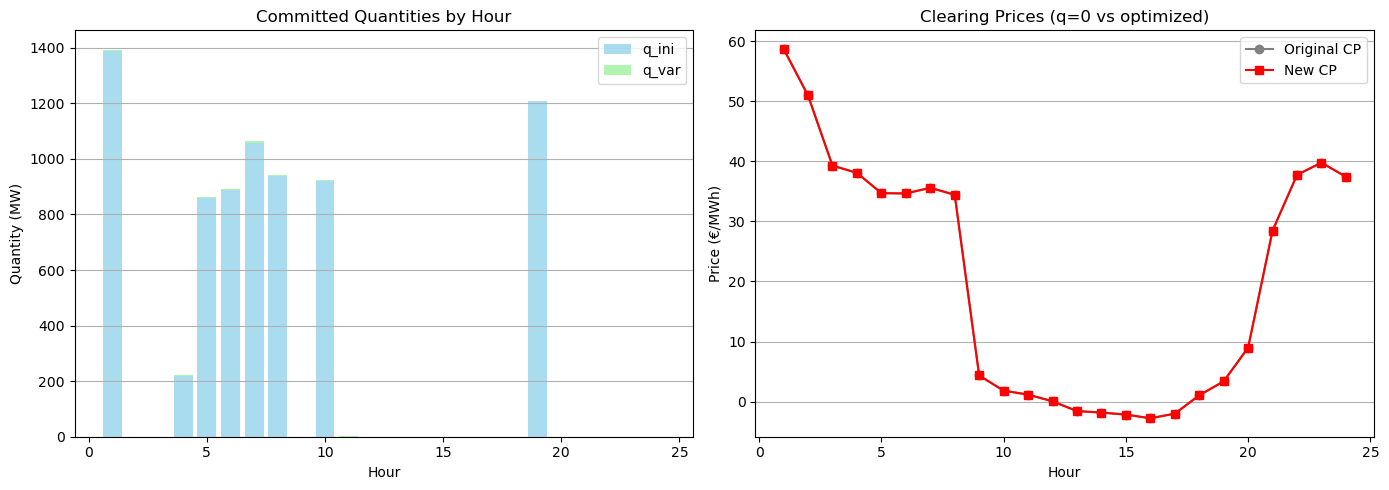

In [146]:
# 결과 불러오기
df = pd.read_csv("solution_da_rt0919.csv")
# Original CP는 "qvar=0"일 때 선택된 블록 b의 clearing price로 정의
orig_cp = []
for t, b in zip(df_q["t"], df_q["chosen_b"]):
    # qvar=0 기준, 해당 블록의 가격 불러오기
    if (t, b, 0) in lambda_da_big:
        orig_cp.append(lambda_da_big[(t,b,0)])
    else:
        orig_cp.append(None)  # 데이터 없으면 빈 값

df_q["orig_cp"] = orig_cp
# ---------------------------
# 1) Committed Quantities (q_ini vs q_var)
# ---------------------------

# chosen block에 따른 q_ini, q_var 계산
q_ini = []
q_var = []
for idx, row in df.iterrows():
    t = row["t"]
    b = row["chosen_b"]
    qini_val = qini_big.get((t, b, 0), 0)   # 시나리오별 qini에서 첫 번째 시나리오 참고
    qvar_val = row["p_bid"] - qini_val      # 실제 입찰량 - qini
    q_ini.append(qini_val)
    q_var.append(qvar_val)

df_q = df.groupby("t").first().reset_index()
df_q["q_ini"] = q_ini[::len(J)]   # j=1만 대표로
df_q["q_var"] = q_var[::len(J)]

# ---------------------------
# 2) Clearing Price 비교 (원래 vs 최적화 후)
# ---------------------------

orig_cp = [lambda_da_big.get((t, b, 0), 0) for t, b in zip(df_q["t"], df_q["chosen_b"])]
new_cp  = []
for t, bid in zip(df_q["t"], df_q["p_bid"]):
    # bid에 가장 가까운 clearing price 찾기 (예시: 0번 시나리오 기준)
    diffs = [(abs(qini_big[(t, b, 0)] - bid), lambda_da_big[(t, b, 0)]) 
             for b in valid_blocks[t] if (t, b, 0) in qini_big]
    if diffs:
        new_cp.append(min(diffs, key=lambda x: x[0])[1])
    else:
        new_cp.append(0)

df_q["orig_cp"] = orig_cp
df_q["new_cp"]  = new_cp

# ---------------------------
# 플롯
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# (1) Committed Quantities
axes[0].bar(df_q["t"], df_q["q_ini"], label="q_ini", alpha=0.7, color="skyblue")
axes[0].bar(df_q["t"], df_q["q_var"], bottom=df_q["q_ini"], label="q_var", alpha=0.7, color="lightgreen")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Quantity (MW)")
axes[0].set_title("Committed Quantities by Hour")
axes[0].legend()
axes[0].grid(True, axis="y")

# (2) Clearing Prices
axes[1].plot(df_q["t"], df_q["orig_cp"], "o-", color="gray", label="Original CP")
axes[1].plot(df_q["t"], df_q["new_cp"], "s-", color="red", label="New CP")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Price (€/MWh)")
axes[1].set_title("Clearing Prices (q=0 vs optimized)")
axes[1].legend()
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()


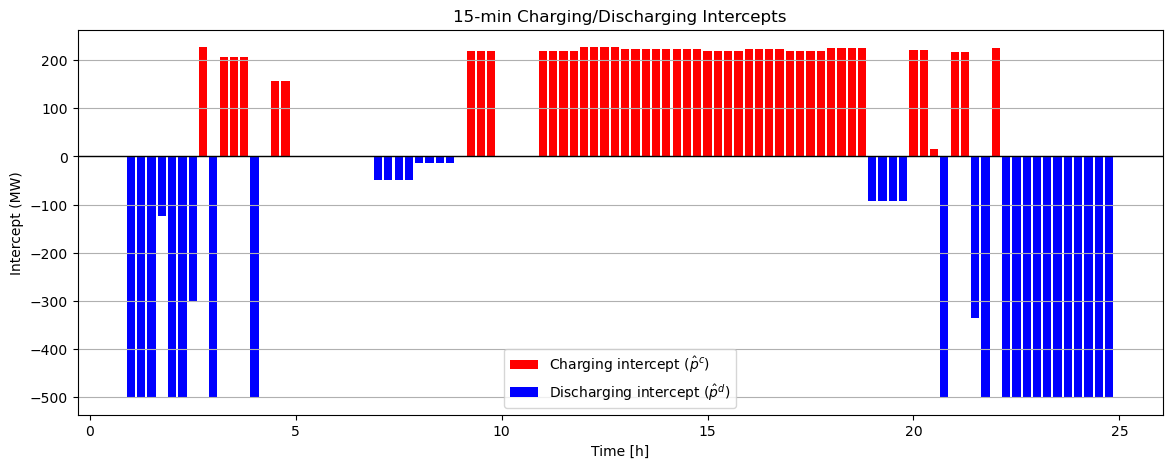

In [143]:
# flatten: (t,j) → 시간축 (1,1)=0.25h, (1,2)=0.5h ... (24,4)=24h
time_axis = [t + (j-1)/4 for t in T for j in J]

# intercept 값 펼치기
p_hat_c_vals = [p_c_mean[(t,j)] for t in T for j in J]
p_hat_d_vals = [p_d_mean[(t,j)] for t in T for j in J]

plt.figure(figsize=(14,5))

plt.bar(time_axis, p_hat_c_vals, width=0.2, color="red", label="Charging intercept ($\hat{p}^c$)")
plt.bar(time_axis, [-v for v in p_hat_d_vals], width=0.2, color="blue", label="Discharging intercept ($\hat{p}^d$)")

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Time [h]")
plt.ylabel("Intercept (MW)")
plt.title("15-min Charging/Discharging Intercepts")
plt.legend()
plt.grid(True, axis="y")
plt.show()


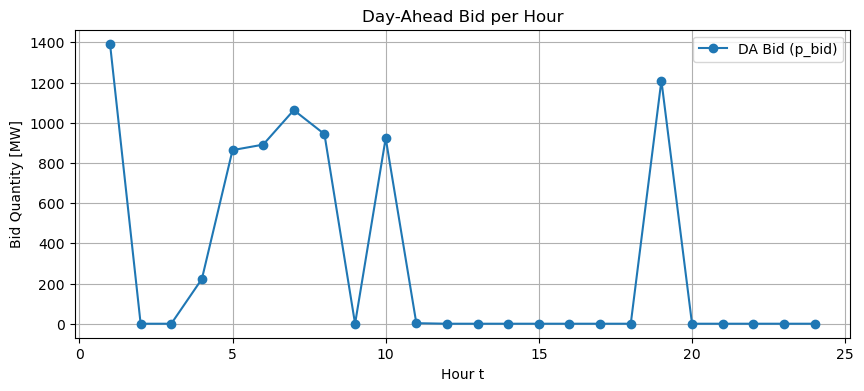

In [142]:
plt.figure(figsize=(10,4))
plt.plot(list(T), [p_bid_sol[t] for t in T], marker="o", label="DA Bid (p_bid)")
plt.xlabel("Hour t")
plt.ylabel("Bid Quantity [MW]")
plt.title("Day-Ahead Bid per Hour")
plt.grid(True)
plt.legend()
plt.show()

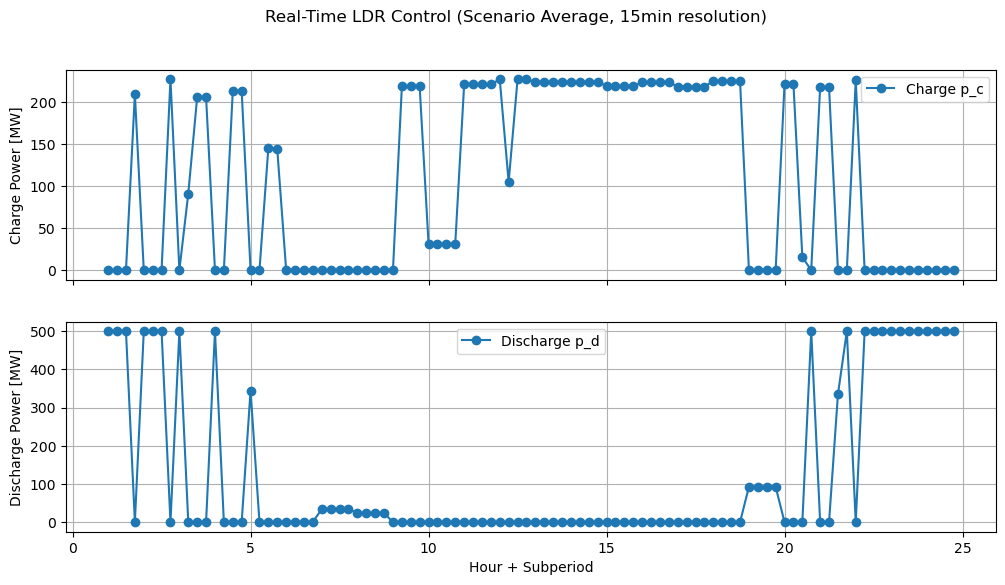

In [80]:
fig, ax = plt.subplots(2, 1, figsize=(12,6), sharex=True)

# 연속 시간축 (Hour + 0.25*(j-1))
time_axis = [t + (j-1)/4 for t in T for j in J]

# 충전
p_c_series = [p_c_mean[t,j] for t in T for j in J]
ax[0].plot(time_axis, p_c_series, marker="o", label="Charge p_c")
ax[0].set_ylabel("Charge Power [MW]")
ax[0].legend()
ax[0].grid(True)

# 방전
p_d_series = [p_d_mean[t,j] for t in T for j in J]
ax[1].plot(time_axis, p_d_series, marker="o", label="Discharge p_d")
ax[1].set_xlabel("Hour + Subperiod")
ax[1].set_ylabel("Discharge Power [MW]")
ax[1].legend()
ax[1].grid(True)

plt.suptitle("Real-Time LDR Control (Scenario Average, 15min resolution)")
plt.show()


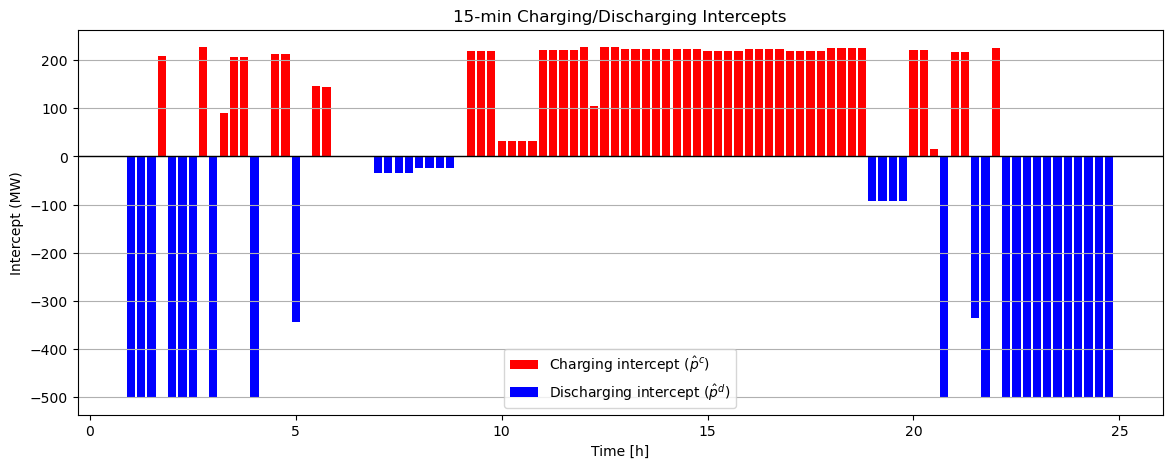

In [83]:
# flatten: (t,j) → 시간축 (1,1)=0.25h, (1,2)=0.5h ... (24,4)=24h
time_axis = [t + (j-1)/4 for t in T for j in J]

# intercept 값 펼치기
p_hat_c_vals = [p_c_mean[(t,j)] for t in T for j in J]
p_hat_d_vals = [p_d_mean[(t,j)] for t in T for j in J]

plt.figure(figsize=(14,5))

plt.bar(time_axis, p_hat_c_vals, width=0.2, color="red", label="Charging intercept ($\hat{p}^c$)")
plt.bar(time_axis, [-v for v in p_hat_d_vals], width=0.2, color="blue", label="Discharging intercept ($\hat{p}^d$)")

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Time [h]")
plt.ylabel("Intercept (MW)")
plt.title("15-min Charging/Discharging Intercepts")
plt.legend()
plt.grid(True, axis="y")
plt.show()


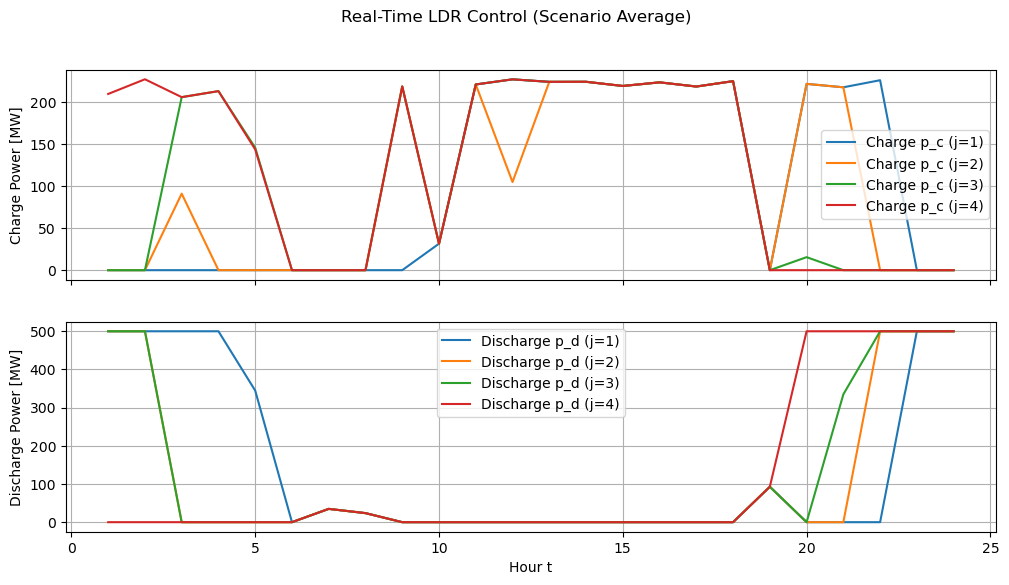

In [24]:
fig, ax = plt.subplots(2,1, figsize=(12,6), sharex=True)

# 충전
for j in J:
    ax[0].plot(list(T), [p_c_mean[t,j] for t in T], label=f"Charge p_c (j={j})")
ax[0].set_ylabel("Charge Power [MW]")
ax[0].legend()
ax[0].grid(True)

# 방전
for j in J:
    ax[1].plot(list(T), [p_d_mean[t,j] for t in T], label=f"Discharge p_d (j={j})")
ax[1].set_xlabel("Hour t")
ax[1].set_ylabel("Discharge Power [MW]")
ax[1].legend()
ax[1].grid(True)

plt.suptitle("Real-Time LDR Control (Scenario Average)")
plt.show()


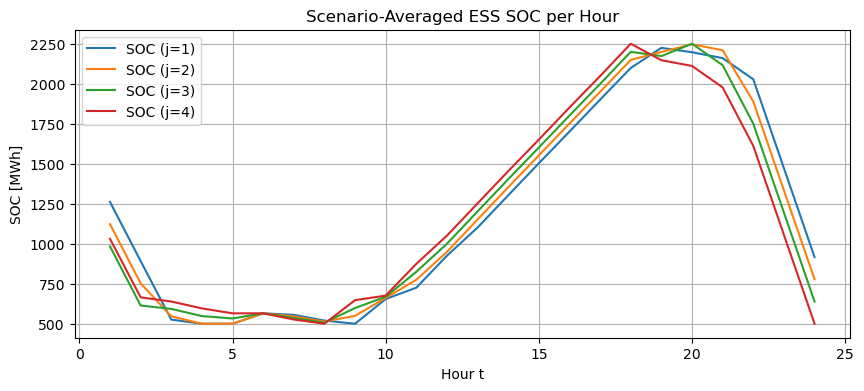

In [25]:
plt.figure(figsize=(10,4))
for j in J:
    plt.plot(list(T), [E_mean[t,j] for t in T], label=f"SOC (j={j})")
plt.xlabel("Hour t")
plt.ylabel("SOC [MWh]")
plt.title("Scenario-Averaged ESS SOC per Hour")
plt.legend()
plt.grid(True)
plt.show()


### 최적화 모델: deterministic SCENARIOS 2

In [122]:
# RDC 시나리오 집합 S(=10개)와 가중치 rho_rdc[s] (균등이면 1/|S|)
# triples[w] = (rdc_s, gen_s, rt_s)
S_rdc = list(range(len(date_range)))   # 10
rho_rdc = {s: 1/len(S_rdc) for s in S_rdc}

# RDC만 평균 (gen/rt는 평균하지 않음)
mu_lambda_RDC = {(t,b): sum(rho_rdc[s]*lambda_da_scen_final[(t,b,s)] for s in S_rdc)
                 for t in T for b in valid_blocks[t]}
mu_qini_RDC   = {(t,b): sum(rho_rdc[s]*qini_scen_final[(t,b,s)]       for s in S_rdc)
                 for t in T for b in valid_blocks[t]}
mu_qmax_RDC   = {(t,b): sum(rho_rdc[s]*qmax_scen_final[(t,b,s)]       for s in S_rdc)
                 for t in T for b in valid_blocks[t]}


In [123]:
EV = gp.Model("EV_RDC_only")

# 1단계 변수 (RP와 동일)
u_e   = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")
qv_e  = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0, name="qvar")
p_bid_e = EV.addVars(T, lb=0.0, name="p_bid")
u_c_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
u_d_e = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")
p_hat_c_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d_e = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d_e     = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# 2단계 변수 (w 의존) — 풍력/RT는 그대로 시나리오
p_c_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
p_d_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
E_e   = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E")
p_b_e = EV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

# 목적함수
# DA: RDC 기대치만 사용 → w에 독립 (rho_w 합이 1이면 sum_w 없어도 동일)
DA_ev = gp.quicksum(mu_lambda_RDC[(t,b)] * (u_e[t,b]*mu_qini_RDC[(t,b)] + qv_e[t,b])
                    for t in T for b in valid_blocks[t])

# RT: 기존처럼 시나리오 기대값
RT_ev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b_e[t,j,w] - p_bid_e[t]/4.0)
        for j in J
    )
    for w in W for t in T
)

EV.setObjective(DA_ev + RT_ev, GRB.MAXIMIZE)

# 제약
for t in T:
    EV.addConstr(gp.quicksum(u_e[t,b] for b in valid_blocks[t]) == 1, name=f"one_block_{t}")
    EV.addConstr(p_bid_e[t] == gp.quicksum(u_e[t,b]*mu_qini_RDC[(t,b)] + qv_e[t,b]
                                           for b in valid_blocks[t]),
                 name=f"p_bid_def_{t}")
    for b in valid_blocks[t]:
        EV.addConstr(qv_e[t,b] <= mu_qmax_RDC[(t,b)] * u_e[t,b], name=f"qvar_max_{t}_{b}")

# LDR & 균형 & SOC & 경계 — 기존 RP와 동일하지만 pwf_big/rt_big은 그대로 w-의존 사용
for w in W:
  for t in T:
    for j in J:
      EV.addConstr(p_c_e[t,j,w] == u_c_e[t,j]*(p_hat_c_e[t,j] + D_c_e[t,j]*rt_big[(t,j,w)]))
      EV.addConstr(p_d_e[t,j,w] == u_d_e[t,j]*(p_hat_d_e[t,j] + D_d_e[t,j]*rt_big[(t,j,w)]))
      EV.addConstr(p_b_e[t,j,w] ==
                   (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d_e[t,j,w] - p_c_e[t,j,w]
                   - p_bid_e[t]/4.0)
      prev = (E0 if (t==1 and j==1) else (E_e[(t-1,4,w)] if j==1 else E_e[(t,j-1,w)]))
      EV.addConstr(E_e[t,j,w] == prev + Δt*(eta_c*p_c_e[t,j,w] - p_d_e[t,j,w]/eta_d))
  # bid 경계 (상한 1000은 당신 설정 유지)
  for t in T:
      EV.addConstr(-gp.quicksum(p_c_e[t,j,w] for j in J) <= p_bid_e[t])
      EV.addConstr(p_bid_e[t] <= 1000 + gp.quicksum(p_d_e[t,j,w] for j in J))

EV.optimize()
Z_EEV_policy = EV.ObjVal    # 먼저 정책값 저장 (이 값은 EV-정책 하에서의 '설계' 목적)


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 244824 rows, 394152 columns and 1030880 nonzeros
Model fingerprint: 0x3f80ce9e
Model has 192000 quadratic constraints
Variable types: 389184 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  QMatrix range    [4e-03, 5e+01]
  QLMatrix range   [1e+00, 1e+00]
  Objective range  [4e-06, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 30246 rows and 292700 columns
Presolve time: 0.80s
Presolved: 216870 rows, 102496 columns, 805630 nonzeros
Presolved model has 696 SOS constraint(s)
Variable types: 97204 continuous, 5292 integer (5292 binary)
Found heuristic solution: objective 224349.43420
Found heuristic solution: objective 497193.01403


In [124]:
EEV = gp.Model("EEV_RDC_eval")

# 2단계만 변수
p_c2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max)
p_d2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max)
E2   = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max)
p_b2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0)

# EV의 1단계 해 고정값 사용
DA_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u_e[t,b].X * qini_big[(t,b,w)] + qv_e[t,b].X)
        for b in valid_blocks[t] if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)
RT_eval = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b2[t,j,w] - p_bid_e[t].X/4.0)
        for j in J
    )
    for w in W for t in T
)
EEV.setObjective(DA_eval + RT_eval, GRB.MAXIMIZE)

# LDR/균형/SOC/경계 — EV의 u_c,u_d,p_hat,D,p_bid 를 **값**으로 사용
for w in W:
  for t in T:
    for j in J:
      EEV.addConstr(p_c2[t,j,w] == u_c_e[t,j].X*(p_hat_c_e[t,j].X + D_c_e[t,j].X*rt_big[(t,j,w)]))
      EEV.addConstr(p_d2[t,j,w] == u_d_e[t,j].X*(p_hat_d_e[t,j].X + D_d_e[t,j].X*rt_big[(t,j,w)]))
      EEV.addConstr(p_b2[t,j,w] ==
                    (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0) + p_d2[t,j,w] - p_c2[t,j,w]
                    - p_bid_e[t].X/4.0)
      prev = (E0 if (t==1 and j==1) else (E2[(t-1,4,w)] if j==1 else E2[(t,j-1,w)]))
      EEV.addConstr(E2[t,j,w] == prev + Δt*(eta_c*p_c2[t,j,w] - p_d2[t,j,w]/eta_d))
  for t in T:
      EEV.addConstr(-gp.quicksum(p_c2[t,j,w] for j in J) <= p_bid_e[t].X)
      EEV.addConstr(p_bid_e[t].X <= 1000 + gp.quicksum(p_d2[t,j,w] for j in J))

EEV.optimize()
Z_EEV = EEV.ObjVal


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 432000 rows, 384000 columns and 1055000 nonzeros
Model fingerprint: 0xf8207db7
Coefficient statistics:
  Matrix range     [2e-01, 1e+00]
  Objective range  [4e-06, 5e-02]
  Bounds range     [5e+02, 2e+03]
  RHS range        [7e-01, 1e+03]
Presolve removed 432000 rows and 384000 columns
Presolve time: 0.17s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    7.0943569e+05   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.31 seconds (0.32 work units)
Optimal objective  7.094356882e+05


In [125]:
VSS_RDC = Z_RP - Z_EEV
print(f"Z_RP    = {Z_RP:,.2f}")
print(f"Z_EEV   = {Z_EEV:,.2f}")
print(f"VSS(RDC)= {VSS_RDC:,.2f}")


Z_RP    = 709,332.47
Z_EEV   = 709,435.69
VSS(RDC)= -103.21


In [131]:
print("sum rho_w =", sum(rho_w[w] for w in W))   # -> 1.0 근처여야
print("RT uses /4.0? DA/RT consistent?")


sum rho_w = 1.0000000000000007
RT uses /4.0? DA/RT consistent?


### 최적화 모델: deterministic SCENARIOS1

In [126]:
# 기대 파라미터
mu_lambda_da = {(t,b): sum(rho_w[w]*lambda_da_big[(t,b,w)] for w in W)
                for t in T for b in valid_blocks[t]}
mu_qini      = {(t,b): sum(rho_w[w]*qini_big[(t,b,w)]      for w in W)
                for t in T for b in valid_blocks[t]}
mu_qmax      = {(t,b): sum(rho_w[w]*qmax_big[(t,b,w)]      for w in W)
                for t in T for b in valid_blocks[t]}
mu_rt        = {(t,j): sum(rho_w[w]*rt_big[(t,j,w)]        for w in W)
                for t in T for j in J}
mu_pwf       = {(i,t): sum(rho_w[w]*pwf_big[(i,t,w)]       for w in W)
                for i in I for t in T}
# 제약식(구조는 RP와 동일하되, 파라미터를 기대값으로)
# 평균(기대) 풍력: 시나리오 평균을 미리 계산
mu_wf = {t: sum(rho_w[w] * sum(pwf_big[(i,t,w)] for i in I) for w in W) for t in T}

In [127]:
EV = gp.Model("EV")

# 1단계 변수 (RP와 동일 구조, 단 w 없음)
u_ev      = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u_ev")
qvar_ev   = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0, name="qvar_ev")
p_bid_ev  = EV.addVars(T, lb=0.0, name="p_bid_ev")
u_c_ev    = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c_ev")
u_d_ev    = EV.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d_ev")
p_hat_c_ev= EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c_ev")
p_hat_d_ev= EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d_ev")
D_c_ev    = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c_ev")
D_d_ev    = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d_ev")

# 2단계(결정론) 변수
p_c_ev = EV.addVars([(t,j) for t in T for j in J], lb=0.0, ub=pc_max, name="p_c_ev")
p_d_ev = EV.addVars([(t,j) for t in T for j in J], lb=0.0, ub=pd_max, name="p_d_ev")
E_ev   = EV.addVars([(t,j) for t in T for j in J], lb=E_min, ub=E_max, name="E_ev")
p_b_ev = EV.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_b_ev")

# 목적함수: 기대 파라미터 사용(한 번만)
DA_ev = gp.quicksum(mu_lambda_da[(t,b)] * (u_ev[t,b]*mu_qini[(t,b)] + qvar_ev[t,b])
                    for t in T for b in valid_blocks[t])
RT_ev = gp.quicksum(mu_rt[(t,j)] * (p_b_ev[t,j] - p_bid_ev[t]/4.0)
                    for t in T for j in J)
EV.setObjective(DA_ev + RT_ev, GRB.MAXIMIZE)

# 제약식(구조는 RP와 동일하되, 파라미터를 기대값으로)
# 평균(기대) 풍력: 시나리오 평균을 미리 계산
mu_wf = {t: sum(rho_w[w] * sum(pwf_big[(i,t,w)] for i in I) for w in W) for t in T}

# RT balance (for all t,j)
for t in T:
    for j in J:
        EV.addConstr(
            p_b_ev[t,j] == (mu_wf[t]/4.0) + p_d_ev[t,j] - p_c_ev[t,j] - p_bid_ev[t]/4.0,
            name=f"rt_balance_ev_{t}_{j}"
        )

for t in T:
    EV.addConstr(gp.quicksum(u_ev[t,b] for b in valid_blocks[t]) == 1, name=f"one_block_ev_{t}")
    EV.addConstr(p_bid_ev[t] == gp.quicksum(u_ev[t,b]*mu_qini[(t,b)] + qvar_ev[t,b] for b in valid_blocks[t]),
                 name=f"p_bid_ev_{t}")

    for b in valid_blocks[t]:
        EV.addConstr(qvar_ev[t,b] <= mu_qmax[(t,b)] * u_ev[t,b], name=f"qvar_max_ev_{t}_{b}")

for t in T:
    for j in J:
        EV.addConstr(u_c_ev[t,j] + u_d_ev[t,j] <= 1, name=f"no_simul_ev_{t}_{j}")
        EV.addConstr(p_c_ev[t,j] <= pc_max*u_c_ev[t,j], name=f"pc_bigm_ev_{t}_{j}")
        EV.addConstr(p_d_ev[t,j] <= pd_max*u_d_ev[t,j], name=f"pd_bigm_ev_{t}_{j}")

# SOC
for t in T:
    for j in J:
        prev = (E0 if (t==1 and j==1) else (E_ev[(t-1,4)] if j==1 else E_ev[(t,j-1)]))
        EV.addConstr(E_ev[t,j] == prev + Δt*(eta_c*p_c_ev[t,j] - p_d_ev[t,j]/eta_d),
                     name=f"SOC_ev_{t}_{j}")

# DA vs RT 경계 (평균 풍력 사용)
for t in T:
    rhs = 1100 + gp.quicksum(p_d_ev[t,j] for j in J)
    EV.addConstr(-gp.quicksum(p_c_ev[t,j] for j in J) <= p_bid_ev[t],  name=f"bid_low_ev_{t}")
    EV.addConstr(p_bid_ev[t] <= rhs,                                    name=f"bid_up_ev_{t}")

EV.setParam("MIPGap", 0.02)
EV.optimize()
Z_EV = EV.ObjVal

Set parameter MIPGap to value 0.02
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 5352 rows, 10536 columns and 25463 nonzeros
Model fingerprint: 0xd2149d1d
Variable types: 5568 continuous, 4968 integer (4968 binary)
Coefficient statistics:
  Matrix range     [2e-01, 2e+03]
  Objective range  [1e-03, 1e+05]
  Bounds range     [1e+00, 2e+03]
  RHS range        [1e+00, 1e+03]
Presolve removed 3374 rows and 4292 columns
Presolve time: 0.03s
Presolved: 1978 rows, 6244 columns, 15178 nonzeros
Variable types: 1832 continuous, 4412 integer (4398 binary)
Found heuristic solution: objective 169477.04455
Found heuristic solution: objective 316434.74980
Found heuristic solution: objective 330002.46868

Root relaxation: objective 7.145624e+05, 943 iterations, 0.01 seconds (0.02 work

In [128]:
u_star      = {(t,b): u_ev[t,b].X for t in T for b in valid_blocks[t]}
qvar_star   = {(t,b): qvar_ev[t,b].X for t in T for b in valid_blocks[t]}
p_bid_star  = {t: p_bid_ev[t].X for t in T}
u_c_star    = {(t,j): u_c_ev[t,j].X for t in T for j in J}
u_d_star    = {(t,j): u_d_ev[t,j].X for t in T for j in J}
p_hat_c_star= {(t,j): p_hat_c_ev[t,j].X for t in T for j in J}
p_hat_d_star= {(t,j): p_hat_d_ev[t,j].X for t in T for j in J}
D_c_star    = {(t,j): D_c_ev[t,j].X for t in T for j in J}
D_d_star    = {(t,j): D_d_ev[t,j].X for t in T for j in J}

In [130]:
EEV = gp.Model("EEV")

# 2단계 변수
p_c2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pc_max, name="p_c")
p_d2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, ub=pd_max, name="p_d")
E2   = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=E_min, ub=E_max, name="E")
p_b2 = EEV.addVars([(t,j,w) for t in T for j in J for w in W], lb=0.0, name="p_b")

# 목적함수 (DA 항은 상수지만 그대로 두어도 무방)
DA_term = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * (u_star[(t,b)]*qini_big[(t,b,w)] + qvar_star[(t,b)])
        for b in valid_blocks[t] if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)
RT_term = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b2[t,j,w] - p_bid_star[t]/4.0)
        for t in T for j in J
    )
    for w in W
)

EEV.setObjective(DA_term + RT_term, GRB.MAXIMIZE)

# # LDR (EV 해 고정)
# for w in W:
#     for t in T:
#         for j in J:
#             EEV.addConstr(
#                 p_c2[t,j,w] == u_c_star[(t,j)] * (p_hat_c_star[(t,j)] + D_c_star[(t,j)] * rt_big[(t,j,w)]),
#                 name=f"LDR_pc_eval_{t}_{j}_w{w}"
#             )
#             EEV.addConstr(
#                 p_d2[t,j,w] == u_d_star[(t,j)] * (p_hat_d_star[(t,j)] + D_d_star[(t,j)] * rt_big[(t,j,w)]),
#                 name=f"LDR_pd_eval_{t}_{j}_w{w}"
#             )
# LDR (EV 해 고정)
for w in W:
    for t in T:
        for j in J:
            EEV.addConstr(
                p_c2[t,j,w] == u_c_star[(t,j)] * (p_hat_c_star[(t,j)] + D_c_star[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pc_eval_{t}_{j}_w{w}"
            )
            EEV.addConstr(
                p_d2[t,j,w] <= u_d_star[(t,j)] * (p_hat_d_star[(t,j)] + D_d_star[(t,j)] * rt_big[(t,j,w)]),
                name=f"LDR_pd_eval_{t}_{j}_w{w}"
            )

# (추가!) RT 전력균형
for w in W:
    for t in T:
        for j in J:
            EEV.addConstr(
                p_b2[t,j,w] ==
                    (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)
                    + p_d2[t,j,w] - p_c2[t,j,w]
                    - p_bid_star[t]/4.0,
                name=f"rt_balance_eval_{t}_{j}_w{w}"
            )

# SOC
for w in W:
    for t in T:
        for j in J:
            prev = (E0 if (t==1 and j==1) else (E2[(t-1,4,w)] if j==1 else E2[(t,j-1,w)]))
            EEV.addConstr(E2[t,j,w] == prev + Δt*(eta_c*p_c2[t,j,w] - p_d2[t,j,w]/eta_d),
                          name=f"SOC_eval_{t}_{j}_w{w}")

# DA vs RT 경계 (p_bid는 EV 해 고정값 사용)
for w in W:
    for t in T:
        rhs = 1100 + gp.quicksum(p_d2[(t,j,w)] for j in J)
        EEV.addConstr(-gp.quicksum(p_c2[(t,j,w)] for j in J) <= p_bid_star[t], name=f"bid_low_eval_{t}_w{w}")
        EEV.addConstr(p_bid_star[t] <= rhs,                           name=f"bid_up_eval_{t}_w{w}")

EEV.Params.MIPGap = 0.02
# EEV.Params.InfUnbdInfo = 1
# EEV.Params.DualReductions = 0
EEV.optimize()
# if EEV.Status == GRB.INFEASIBLE:
#     EEV.computeIIS()
#     EEV.write("EEV_iis.ilp")

Set parameter MIPGap to value 0.02
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 432000 rows, 384000 columns and 1055000 nonzeros
Model fingerprint: 0x7c958d57
Coefficient statistics:
  Matrix range     [2e-01, 1e+00]
  Objective range  [4e-06, 5e-02]
  Bounds range     [5e+02, 2e+03]
  RHS range        [3e-01, 1e+03]
Presolve removed 321000 rows and 279000 columns
Presolve time: 0.08s

Solved in 0 iterations and 0.08 seconds (0.07 work units)
Infeasible or unbounded model


In [52]:
Z_EEV = EEV.ObjVal

In [53]:
VSS = Z_RP - Z_EEV
print(f"Z_RP  = {Z_RP:,.2f}")
print(f"Z_EEV = {Z_EEV:,.2f}")
print(f"VSS   = {VSS:,.2f}")

Z_RP  = 709,332.47
Z_EEV = 445,574.57
VSS   = 263,757.91


In [39]:
mins = []
maxs = []
for t in T:
    for j in J:
        for w in W:
            rc = p_hat_c_star[(t,j)] + D_c_star[(t,j)]*rt_big[(t,j,w)]
            rd = p_hat_d_star[(t,j)] + D_d_star[(t,j)]*rt_big[(t,j,w)]
            mins.append(min(rc, rd))
            maxs.append(max(rc, rd))
print("LDR RHS min:", min(mins), "max:", max(maxs))


LDR RHS min: 0.0 max: 0.0


### 최적화모델: deterministic rdc

In [54]:
# RDC 기대 파라미터
mu_qini    = {(t,b): sum(rho_w[w]*qini_big[(t,b,w)]      for w in W if (t,b,w) in qini_big)      for t in T for b in valid_blocks[t]}
mu_qmax    = {(t,b): sum(rho_w[w]*qmax_big[(t,b,w)]      for w in W if (t,b,w) in qmax_big)      for t in T for b in valid_blocks[t]}
mu_lambda  = {(t,b): sum(rho_w[w]*lambda_da_big[(t,b,w)] for w in W if (t,b,w) in lambda_da_big) for t in T for b in valid_blocks[t]}


In [61]:
# --------------------------
# RP_noRDC: RDC 평균(기대)으로 고정, WF/RT만 시나리오
# --------------------------
RP_noRDC = gp.Model("WF_ESS_3D_noRDC")

# ---------- 1단계(H&N) ----------
u_nR = RP_noRDC.addVars([(t,b) for t in T for b in valid_blocks[t]],
                        vtype=GRB.BINARY, name="u")
qvar_nR = RP_noRDC.addVars([(t,b) for t in T for b in valid_blocks[t]],
                           lb=0.0, name="qvar")
p_bid_nR = RP_noRDC.addVars(T, lb=0.0, name="p_bid")

u_c_nR = RP_noRDC.addVars([(t,j) for t in T for j in J],
                          vtype=GRB.BINARY, name="u_c")
u_d_nR = RP_noRDC.addVars([(t,j) for t in T for j in J],
                          vtype=GRB.BINARY, name="u_d")

# ---------- 2단계(Recourse; w별) ----------
p_c_nR = RP_noRDC.addVars([(t,j,w) for t in T for j in J for w in W],
                          lb=0.0, ub=pc_max, name="p_c")
p_d_nR = RP_noRDC.addVars([(t,j,w) for t in T for j in J for w in W],
                          lb=0.0, ub=pd_max, name="p_d")
E_q_nR = RP_noRDC.addVars([(t,j,w) for t in T for j in J for w in W],
                          lb=E_min, ub=E_max, name="E_q")
p_b_nR = RP_noRDC.addVars([(t,j,w) for t in T for j in J for w in W],
                          lb=0.0, name="p_b")

p_hat_c_nR = RP_noRDC.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_c")
p_hat_d_nR = RP_noRDC.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_hat_d")
D_c_nR     = RP_noRDC.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_c")
D_d_nR     = RP_noRDC.addVars([(t,j) for t in T for j in J], lb=0.0, name="D_d")

# ---------- 목적함수 ----------
# DA 수익: RDC 평균 값 사용
DA_rev_nR = gp.quicksum(
    mu_lambda[(t,b)] * (u_nR[t,b]*mu_qini[(t,b)] + qvar_nR[t,b])
    for t in T for b in valid_blocks[t]
)

# RT 수익: WF/RT 시나리오 그대로
RT_rev_nR = gp.quicksum(
    rho_w[w] * gp.quicksum(
        rt_big[(t,j,w)] * (p_b_nR[t,j,w] - p_bid_nR[t]/4.0)
        for j in J if (t,j,w) in rt_big
    )
    for w in W for t in T
)

RP_noRDC.setObjective(DA_rev_nR + RT_rev_nR, GRB.MAXIMIZE)

# ---------- 제약식 ----------
# 블록 선택
for t in T:
    RP_noRDC.addConstr(gp.quicksum(u_nR[t,b] for b in valid_blocks[t]) == 1,
                       name=f"one_block_{t}")

# qvar ≤ qmax * u (qmax도 평균값 사용)
for t in T:
    for b in valid_blocks[t]:
        RP_noRDC.addConstr(
            qvar_nR[t,b] <= mu_qmax[(t,b)] * u_nR[t,b],
            name=f"qvar_max_{t}_{b}"
        )

# p_bid 정의
for t in T:
    RP_noRDC.addConstr(
        p_bid_nR[t] == gp.quicksum(u_nR[t,b]*mu_qini[(t,b)] + qvar_nR[t,b]
                                   for b in valid_blocks[t]),
        name=f"p_bid_def_{t}"
    )

# LDR (WF/RT 시나리오 그대로)
for w in W:
    for t in T:
        for j in J:
            RP_noRDC.addConstr(
                p_c_nR[t,j,w] == u_c_nR[t,j] * (p_hat_c_nR[t,j] + D_c_nR[t,j]*rt_big[(t,j,w)]),
                name=f"LDR_pc_{t}_{j}_w{w}"
            )
            RP_noRDC.addConstr(
                p_d_nR[t,j,w] == u_d_nR[t,j] * (p_hat_d_nR[t,j] + D_d_nR[t,j]*rt_big[(t,j,w)]),
                name=f"LDR_pd_{t}_{j}_w{w}"
            )

# 동시 충방전 금지 + Big-M
for t in T:
    for j in J:
        RP_noRDC.addConstr(u_c_nR[t,j] + u_d_nR[t,j] <= 1, name=f"no_simul_{t}_{j}")
        for w in W:
            RP_noRDC.addConstr(p_c_nR[t,j,w] <= pc_max*u_c_nR[t,j], name=f"pc_bigm_{t}_{j}_w{w}")
            RP_noRDC.addConstr(p_d_nR[t,j,w] <= pd_max*u_d_nR[t,j], name=f"pd_bigm_{t}_{j}_w{w}")

# SOC 전이
for w in W:
    for t in T:
        for j in J:
            prev = (E0 if (t==1 and j==1) else (E_q_nR[(t-1,4,w)] if j==1 else E_q_nR[(t,j-1,w)]))
            RP_noRDC.addConstr(
                E_q_nR[t,j,w] == prev + Δt*(eta_c*p_c_nR[t,j,w] - p_d_nR[t,j,w]/eta_d),
                name=f"SOC_{t}_{j}_w{w}"
            )

# DA vs RT 경계 (WF/RT 시나리오 값 사용)
for w in W:
    for t in T:
        rhs = 1100 + gp.quicksum(p_d_nR[t,j,w] for j in J)
        RP_noRDC.addConstr(-gp.quicksum(p_c_nR[t,j,w] for j in J) <= p_bid_nR[t], name=f"bid_low_{t}_w{w}")
        RP_noRDC.addConstr(p_bid_nR[t] <= rhs, name=f"bid_up_{t}_w{w}")

# ---------- 옵션 ----------
RP_noRDC.Params.MIPGap = 0.02
RP_noRDC.Params.TimeLimit = 3600
RP_noRDC.Params.Heuristics = 0.1
model.computeIIS()
model.write("RP_noRDC.ilp")
RP_noRDC.optimize()

# Z_RP_noRDC = RP_noRDC.ObjVal
# print("Z_RP_noRDC =", Z_RP_noRDC)


Set parameter MIPGap to value 0.02
Set parameter TimeLimit to value 3600
Set parameter Heuristics to value 0.1
Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

IIS computation: initial model status unknown, solving to determine model status
Presolve removed 24000 rows and 96036 columns (presolve time = 5s) ...
Presolve removed 4795224 rows and 96036 columns
Presolve time: 7.85s
Presolved: 605616 rows, 299160 columns, 1740812 nonzeros
Presolved model has 696 SOS constraint(s)
Variable types: 293844 continuous, 5316 integer (5316 binary)
Found heuristic solution: objective -0.0000000

Explored 1 nodes (0 simplex iterations) in 12.04 seconds (13.61 work units)
Thread count was 32 (of 32 available processors)

Solution count 1: -0 
No other solutions better than -0

Optimal solution found (toleran

GurobiError: Cannot compute IIS on a feasible model

In [62]:
def solve_one_scenario(w):
    m = gp.Model(f"WS_w{w}")
    # 1단계(시나리오별 비예견성 해제 → w별로 따로 둠)
    u_w     = m.addVars([(t,b) for t in T for b in valid_blocks_by_w[(t,w)]], vtype=GRB.BINARY, name="u")
    qvar_w  = m.addVars([(t,b) for t in T for b in valid_blocks_by_w[(t,w)]], lb=0.0, name="qvar")
    p_bid_w = m.addVars(T, lb=0.0, name="p_bid")
    u_c_w   = m.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_c")
    u_d_w   = m.addVars([(t,j) for t in T for j in J], vtype=GRB.BINARY, name="u_d")

    # 2단계
    p_c_w = m.addVars([(t,j) for t in T for j in J], lb=0.0, ub=pc_max, name="p_c")
    p_d_w = m.addVars([(t,j) for t in T for j in J], lb=0.0, ub=pd_max, name="p_d")
    E_w   = m.addVars([(t,j) for t in T for j in J], lb=E_min,  ub=E_max, name="E")
    p_b_w = m.addVars([(t,j) for t in T for j in J], lb=0.0, name="p_b")

    # 목적함수 (해당 w 값만 사용)
    DA = gp.quicksum(
        lambda_da_big[(t,b,w)] * (u_w[t,b]*qini_big[(t,b,w)] + qvar_w[t,b])
        for t in T for b in valid_blocks_by_w[(t,w)]
    )
    RT = gp.quicksum(
        rt_big[(t,j,w)] * (p_b_w[t,j] - p_bid_w[t]/4.0)
        for t in T for j in J
    )
    m.setObjective(DA + RT, GRB.MAXIMIZE)

    # 제약
    for t in T:
        m.addConstr(gp.quicksum(u_w[t,b] for b in valid_blocks_by_w[(t,w)]) == 1)
        m.addConstr(p_bid_w[t] == gp.quicksum(u_w[t,b]*qini_big[(t,b,w)] + qvar_w[t,b]
                                              for b in valid_blocks_by_w[(t,w)]))
        for b in valid_blocks_by_w[(t,w)]:
            m.addConstr(qvar_w[t,b] <= qmax_big[(t,b,w)] * u_w[t,b])

    for t in T:
        for j in J:
            m.addConstr(u_c_w[t,j] + u_d_w[t,j] <= 1)
            m.addConstr(p_c_w[t,j] <= pc_max * u_c_w[t,j])
            m.addConstr(p_d_w[t,j] <= pd_max * u_d_w[t,j])

    for t in T:
        for j in J:
            prev = (E0 if (t==1 and j==1) else (E_w[(t-1,4)] if j==1 else E_w[(t,j-1)]))
            m.addConstr(E_w[t,j] == prev + Δt*(eta_c*p_c_w[t,j] - p_d_w[t,j]/eta_d))

    for t in T:
        rhs = gp.quicksum(pwf_big[(i,t,w)] for i in I) + gp.quicksum(p_d_w[t,j] for j in J)
        m.addConstr(-gp.quicksum(p_c_w[t,j] for j in J) <= p_bid_w[t])
        m.addConstr(p_bid_w[t] <= rhs)

    # RT 균형
    for t in T:
        for j in J:
            m.addConstr(
                p_b_w[t,j] == (gp.quicksum(pwf_big[(i,t,w)] for i in I)/4.0)
                              + p_d_w[t,j] - p_c_w[t,j] - p_bid_w[t]/4.0
            )

    m.Params.OutputFlag = 0
    m.optimize()
    return m.ObjVal

# Z_WS 계산
Z_WS = sum(rho_w[w] * solve_one_scenario(w) for w in W)

# 이미 가진 Z_RP, Z_EEV가 있다면:
VSS  = Z_RP - Z_EEV
EVPI = Z_WS - Z_RP

print(f"Z_RP  = {Z_RP:,.2f}")
print(f"Z_EEV = {Z_EEV:,.2f}")
print(f"Z_WS  = {Z_WS:,.2f}")
print(f"VSS   = {VSS:,.2f}")
print(f"EVPI  = {EVPI:,.2f}")


Z_RP  = 709,332.47
Z_EEV = 445,574.57
Z_WS  = 719,075.84
VSS   = 263,757.91
EVPI  = 9,743.37


In [107]:
model = gp.Model("RP_RDC")
u     = model.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")
qvar  = model.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0, name="qvar")
p_bid = model.addVars(T, lb=0.0, name="p_bid")

# Objective (expected DA revenue)
obj = gp.quicksum(
    rho[s] * gp.quicksum(
        lambda_da_scen_final[(t,b,s)] * ( u[t,b]*qini_scen_final[(t,b,s)] + qvar[t,b] )
        for b in valid_blocks[t]
    ) for s in S for t in T
)
model.setObjective(obj, GRB.MAXIMIZE)

# Constraints
for t in T:
    model.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1)
    model.addConstr(p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qvar[t,b] for b in valid_blocks[t]))
    for b in valid_blocks[t]:
        for s in S:  # robust across scenarios
            model.addConstr(qvar[t,b] <= qmax_scen_final[(t,b,s)] * u[t,b])

model.optimize()
Z_RP_RDC = model.ObjVal


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 47808 rows, 9576 columns and 109848 nonzeros
Model fingerprint: 0x234dec81
Variable types: 4800 continuous, 4776 integer (4776 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [2e-03, 1e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective -0.0000000
Presolve removed 47808 rows and 9576 columns
Presolve time: 0.02s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.03 seconds (0.06 work units)
Thread count was 1 (of 32 available processors)

Solution count 2: 867138 -0 

Optimal solution found (tolerance 1.00e-04)
Best objective 8.671377010710e+05, best bound 8.671377010710e+05, gap 0.0000%


In [119]:
model = gp.Model("EV_RDC")
u     = model.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY, name="u")
qvar  = model.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0, name="qvar")
p_bid = model.addVars(T, lb=0.0, name="p_bid")

# Objective (expected DA revenue)
obj = gp.quicksum(
    rho[s] * gp.quicksum(
        lambda_da_scen_final[(t,b,s)] * ( u[t,b]*qini_scen_final[(t,b,s)] + qvar[t,b] )
        for b in valid_blocks[t]
    ) for s in S for t in T
)
model.setObjective(obj, GRB.MAXIMIZE)

# Constraints
for t in T:
    model.addConstr(gp.quicksum(u[t,b] for b in valid_blocks[t]) == 1)

    # 기대값 기반 p_bid 정의
    model.addConstr(
        p_bid[t] == gp.quicksum(u[t,b]*mu_qini[(t,b)] + qvar[t,b] for b in valid_blocks[t])
    )

    # robust → expectation 으로 변경
    for b in valid_blocks[t]:
        model.addConstr(
            qvar[t,b] <= gp.quicksum(rho[s] * qmax_scen_final[(t,b,s)] for s in S) * u[t,b]
        )

model.optimize()
Z_EV_RDC = model.ObjVal


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 4824 rows, 9576 columns and 23880 nonzeros
Model fingerprint: 0x973841b7
Variable types: 4800 continuous, 4776 integer (4776 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [2e-03, 1e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective -0.0000000
Presolve removed 4824 rows and 9576 columns
Presolve time: 0.01s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.01 work units)
Thread count was 1 (of 32 available processors)

Solution count 2: 867138 -0 

Optimal solution found (tolerance 1.00e-04)
Best objective 8.671377010710e+05, best bound 8.671377010710e+05, gap 0.0000%


In [121]:
for t in T[:3]:   # 앞 몇 시간만 체크
    for b in valid_blocks[t][:3]:
        qmax_vals = [qmax_scen_final[(t,b,s)] for s in S]
        print(f"t={t}, b={b}, min={min(qmax_vals):.8f}, mean={np.mean(qmax_vals):.8f}")


t=1, b=0, min=3.98000000, mean=3.98000000
t=1, b=1, min=3.98000000, mean=3.98000000
t=1, b=2, min=3.98000000, mean=3.98000000
t=2, b=0, min=3.98000000, mean=3.98000000
t=2, b=1, min=3.98000000, mean=3.98000000
t=2, b=2, min=3.98000000, mean=3.98000000
t=3, b=0, min=3.98000000, mean=3.98000000
t=3, b=1, min=3.98000000, mean=3.98000000
t=3, b=2, min=3.98000000, mean=3.98000000


In [108]:
EV = gp.Model("EV_RDC")
u_e   = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY)
qv_e  = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0)
pb_e  = EV.addVars(T, lb=0.0)

EV.setObjective(gp.quicksum(
    gp.quicksum(mu_lambda[(t,b)]*(u_e[t,b]*mu_qini[(t,b)] + qv_e[t,b]) for b in valid_blocks[t])
    for t in T
), GRB.MAXIMIZE)

for t in T:
    EV.addConstr(gp.quicksum(u_e[t,b] for b in valid_blocks[t]) == 1)
    EV.addConstr(pb_e[t] == gp.quicksum(u_e[t,b]*mu_qini[(t,b)] + qv_e[t,b] for b in valid_blocks[t]))
    for b in valid_blocks[t]:
        EV.addConstr(qv_e[t,b] <= mu_qmax[(t,b)]*u_e[t,b])

EV.optimize()
Z_EEV_RDC = EV.ObjVal


Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 4824 rows, 9576 columns and 23880 nonzeros
Model fingerprint: 0x8bd6933d
Variable types: 4800 continuous, 4776 integer (4776 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [2e-03, 1e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective -0.0000000
Presolve removed 4824 rows and 9576 columns
Presolve time: 0.00s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.01 work units)
Thread count was 1 (of 32 available processors)

Solution count 2: 867138 -0 

Optimal solution found (tolerance 1.00e-04)
Best objective 8.671377010710e+05, best bound 8.671377010710e+05, gap 0.0000%


In [112]:
EV = gp.Model("EV_RDC")
u_e   = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY)
qv_e  = EV.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0)
pb_e  = EV.addVars(T, lb=0.0)

EV.setObjective(gp.quicksum(
    gp.quicksum(mu_lambda[(t,b)]*(u_e[t,b]*mu_qini[(t,b)] + qv_e[t,b]) for b in valid_blocks[t])
    for t in T
), GRB.MAXIMIZE)

for t in T:
    EV.addConstr(gp.quicksum(u_e[t,b] for b in valid_blocks[t]) == 1)
    EV.addConstr(pb_e[t] == gp.quicksum(u_e[t,b]*mu_qini[(t,b)] + qv_e[t,b] for b in valid_blocks[t]))
    for b in valid_blocks[t]:
        EV.addConstr(qv_e[t,b] <= mu_qmax[(t,b)]*u_e[t,b])

EV.optimize()
Z_EV_RDC = EV.ObjVal   # ← 이건 EV 목적값

Gurobi Optimizer version 11.0.1 build v11.0.1rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: 13th Gen Intel(R) Core(TM) i9-13900K, instruction set [SSE2|AVX|AVX2]
Thread count: 24 physical cores, 32 logical processors, using up to 32 threads

Optimize a model with 4824 rows, 9576 columns and 23880 nonzeros
Model fingerprint: 0x8bd6933d
Variable types: 4800 continuous, 4776 integer (4776 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+03]
  Objective range  [2e-03, 1e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+00]
Found heuristic solution: objective -0.0000000
Presolve removed 4824 rows and 9576 columns
Presolve time: 0.01s
Presolve: All rows and columns removed

Explored 0 nodes (0 simplex iterations) in 0.01 seconds (0.01 work units)
Thread count was 1 (of 32 available processors)

Solution count 2: 867138 -0 

Optimal solution found (tolerance 1.00e-04)
Best objective 8.671377010710e+05, best bound 8.671377010710e+05, gap 0.0000%


In [116]:
u_star  = { (t,b): u_e[t,b].X for t in T for b in valid_blocks[t] }
qv_star = { (t,b): qv_e[t,b].X for t in T for b in valid_blocks[t] }
pb_star = { t: pb_e[t].X for t in T }

In [117]:
Z_EEV_RDC = 0.0
for w in W:
    scen_obj = 0.0
    for t in T:
        for b in valid_blocks[t]:
            scen_obj += lambda_da_big[(t,b,w)] * (
                u_star[t,b] * qini_big[(t,b,w)] + qv_star[t,b]
            )
    Z_EEV_RDC += rho_w[w] * scen_obj


In [118]:
print(f"Z_EV(RDC)  = {Z_EV_RDC:,.2f}")   # deterministic 해
print(f"Z_EEV(RDC) = {Z_EEV_RDC:,.2f}")  # EV 해를 시나리오에 적용했을 때 기대값
print(f"VSS(RDC)   = {Z_RP_RDC - Z_EEV_RDC:,.2f}")


Z_EV(RDC)  = 867,137.70
Z_EEV(RDC) = 867,137.70
VSS(RDC)   = -0.00


In [153]:
def solve_WS_for_s(s):
    M = gp.Model(f"WS_s{s}")
    u_s  = M.addVars([(t,b) for t in T for b in valid_blocks[t]], vtype=GRB.BINARY)
    qv_s = M.addVars([(t,b) for t in T for b in valid_blocks[t]], lb=0.0)

    M.setObjective(gp.quicksum(
        gp.quicksum(lambda_da_scen_final[(t,b,s)]*(u_s[t,b]*qini_scen_final[(t,b,s)] + qv_s[t,b])
                    for b in valid_blocks[t])
        for t in T
    ), GRB.MAXIMIZE)

    for t in T:
        M.addConstr(gp.quicksum(u_s[t,b] for b in valid_blocks[t]) == 1)
        for b in valid_blocks[t]:
            M.addConstr(qv_s[t,b] <= qmax_scen_final[(t,b,s)]*u_s[t,b])

    M.Params.OutputFlag = 0
    M.optimize()
    return M.ObjVal

Z_WS_RDC = sum(rho[s]*solve_WS_for_s(s) for s in S)


In [115]:
VSS_RDC  = Z_RP_RDC  - Z_EEV_RDC
EVPI_RDC = Z_WS_RDC  - Z_RP_RDC
print(f"Z_RP(RDC)   = {Z_RP_RDC:,.2f}")
print(f"Z_EEV(RDC)  = {Z_EEV_RDC:,.2f}")
print(f"Z_WS(RDC)   = {Z_WS_RDC:,.2f}")
print(f"VSS(RDC)    = {VSS_RDC:,.2f}")
print(f"EVPI(RDC)   = {EVPI_RDC:,.2f}")


Z_RP(RDC)   = 867,137.70
Z_EEV(RDC)  = 867,137.70
Z_WS(RDC)   = 868,854.95
VSS(RDC)    = -0.00
EVPI(RDC)   = 1,717.25


In [111]:
# (기존) qvar[(t,b)]  --> (변경) 시나리오별 2단계 변수
qvar = model.addVars([(t,b,w) for t in T for b in valid_blocks[t] for w in W],
                     lb=0.0, name="qvar")


In [ ]:
DA_rev = gp.quicksum(
    rho_w[w] * gp.quicksum(
        lambda_da_big[(t,b,w)] * ( u[t,b] * qini_big[(t,b,w)] + qvar[(t,b,w)] )
        for b in valid_blocks[t] if (t,b,w) in lambda_da_big
    )
    for w in W for t in T
)
